In [1]:
# Data handling
import pandas as pd
import numpy as np
import json
import os
import glob
import time
from datetime import datetime
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression

# Visualization
import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use('default')

# Excel reading
import xlrd

# Scikit-learn tools
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler, StandardScaler
from sklearn.manifold import MDS
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.neural_network import MLPClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import LeaveOneOut, GridSearchCV,StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,balanced_accuracy_score,roc_curve, roc_auc_score,precision_score,recall_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.tree import DecisionTreeClassifier

# Others
from scipy.signal import find_peaks, detrend
from scipy import stats
from scipy.spatial.distance import euclidean
import itertools
from itertools import combinations
from pathlib import Path
from scipy.stats import linregress, iqr, skew, kurtosis
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings("ignore")


In [2]:
###SETTING UP THE ENVIRONMENT####
def set_up(path):
    # Set the main working directory
    main_path = path
    os.chdir(main_path)

    # Load metadata
    metadata = pd.read_excel('ONCO_Groupmembership.xlsx')

    # Define folder containing data files
    name_of_the_folder = "excel_files"
    filenames = os.listdir(name_of_the_folder)

    ####IN CASE I WANT TO INCLUDE A SPECIFIC SITE##############

    ##mainz

    #filenames = [f for f in filenames if f.startswith("ONCODE01")]

    ############################################################
    # Extract metadata columns
    Metadata_details = pd.DataFrame({
    'Prefix': metadata["SubjectID"],
    'Class': metadata["Group"],
    'Exclude': metadata["Exclude"]
    })

    # Filter out excluded samples
    Metadata_details = Metadata_details[Metadata_details["Exclude"] == "NO"].reset_index(drop=True)

    # Optional: print current working directory (can be removed if not needed)
    print("Current working directory:", os.getcwd())
    print("Metadata has been set")
    return filenames, Metadata_details, name_of_the_folder
    
def prepare_directory(path_name):
    Path(path_name).mkdir(parents=True, exist_ok=True)
    os.chdir(path_name)
    print(f"Current directory is: {os.getcwd()}")
####PREPROCESSING AND FEATURE EXTRACTION
##using bfil. First zeros are replaced with NaN and then the NaN to the next valid value
def missing_values_zeros(Combined):
    
    time_series_sensors = [col for col in Combined.columns if col not in ["Timestamp", "Minutes","Cycle"]]
    series_with_Na=Combined[time_series_sensors].replace(0, np.nan)
    New_Combined=pd.concat([Combined.iloc[:,0:3],series_with_Na], axis=1).bfill()

    return New_Combined

def detect_and_detrend_series(x, alpha=0.05):
    """Detects trend and detrends a single series."""
    x = pd.Series(x).dropna()
    t = np.arange(len(x))
    
    # Linear regression for trend
    slope, intercept, r_value, p_value, std_err = linregress(t, x)
    
    if p_value < alpha:
        # Remove only slope, not intercept
        detrended = x - (slope * t)
        trend = "increasing" if slope > 0 else "decreasing"
    else:
        detrended = x.copy()
        trend = "no trend"
    
    return detrended.reindex(np.arange(len(x))), trend, slope, p_value

def detrend_dataframe(df, alpha=0.05, plot=False, lastp_ambient=12, lastp_breath=26):
    """
    Apply trend detection + detrending to each column in a DataFrame.
    Adds vertical lines for Ambient, Breath, and Clean regions when plot=True.
    """
    detrended_data = {}
    info = []

    for col in df.columns:
        detrended, trend, slope, p_value = detect_and_detrend_series(df[col], alpha=alpha)
        detrended_data[col] = detrended
        info.append((col, trend, slope, p_value))

        if plot:
            t = np.arange(len(df[col]))
            plt.figure(figsize=(9, 3))
            plt.suptitle(col)
            
            # Compute vertical line positions
           
            vlines = [lastp_ambient, lastp_breath]  # positions for Ambient|Breath|Clean

            # --- Original signal ---
            plt.subplot(1, 2, 1)
            plt.plot(t, df[col], label="Original")
            if trend != "no trend":
                plt.plot(t, slope*t + df[col].dropna().iloc[0], "r--", label=f"{trend} trend")
            for v in vlines:
                plt.axvline(v, color='black', linestyle='--', alpha=0.7)
            plt.title(f"Original ({trend})")
            plt.legend()
            plt.grid(True)

            # --- Detrended signal ---
            plt.subplot(1, 2, 2)
            plt.plot(t, detrended, color='green', label="Detrended")
            for v in vlines:
                plt.axvline(v, color='black', linestyle='--', alpha=0.7)
            plt.title("Detrended")
            plt.legend()
            plt.grid(True)

            plt.tight_layout()
            plt.show()
    
    detrended_df = pd.DataFrame(detrended_data, index=df.index)
    trend_info = pd.DataFrame(info, columns=["Column", "Trend", "Slope", "p-value"])
    
    return detrended_df, trend_info

def detect_dead_sensors(df, threshold=1e-5):
    """
    Detects 'dead' sensors in a DataFrame based on low variance.

    Parameters
    ----------
    df : pd.DataFrame
        Each column represents a sensor signal.
    threshold : float, optional
        Variance threshold below which a sensor is considered dead.
        Default is 1e-5.

    Returns
    -------
    dead_sensors : list
        List of column names (sensors) with low variance.
    variances : pd.Series
        Variance of each sensor.
    """
    variances = df.var(skipna=True)
    dead_sensors = variances[variances < threshold].index.tolist()
    return dead_sensors, variances

def clear_signals_via_correlation_v2(Combined, thres=0.8, max_iter=700):
    """
    Iteratively removes the least correlated sensor in each chip until
    the mean correlation of the remaining sensors exceeds a threshold
    or only one sensor remains.

    Parameters:
        Combined (pd.DataFrame): Input dataframe with first 3 columns as time info
        thres (float): Correlation threshold to stop pruning
        max_iter (int): Safety limit for iterations

    Returns:
        pd.DataFrame: Cleaned dataframe with time columns preserved
    """

    # 1. Separate time info
    time_info = Combined.iloc[:, :3]

    # 2. Extract sensor columns
    sensor_cols = [col for col in Combined.columns if col not in time_info.columns]
    sensor_data = Combined[sensor_cols]

    # 3. Split sensors by chip
    chips = {
        f"Chip{i}": sensor_data[[col for col in sensor_data.columns if f"Chip{i}" in col]]
        for i in range(1, 9)
    }

    cleaned_chips = {}

    # 4. Iteratively clean each chip
    for chip_name, chip_df in chips.items():
        chip_df = chip_df.dropna(axis=1, how="any")
        iteration = 0

        while iteration < max_iter and len(chip_df.columns) > 1:
            corr_matrix = chip_df.corr()
            mean_corr = corr_matrix.mean()

            # Stop if all mean correlations are above threshold
            if mean_corr.mean() >= thres:
                break

            # Remove the column with lowest mean correlation
            worst_sensor = mean_corr.idxmin()
            chip_df = chip_df.drop(columns=[worst_sensor])
            iteration += 1

        cleaned_chips[chip_name] = chip_df

    # 5. Combine cleaned chips and time info
    final_df = pd.concat([time_info] + list(cleaned_chips.values()), axis=1)

    # Optional summary
    summary = {k: v.shape for k, v in cleaned_chips.items()}
    print("Final chip shapes:", summary)

    return final_df

def correction_of_ambient(Combined):
    if  len(Combined[Combined['Cycle']=="ambient"].index)>15:
        Combined=pd.concat([Combined[Combined['Cycle']=="ambient"].iloc[-14:,:],Combined[Combined['Cycle']=="breath"],Combined[Combined['Cycle']=="clean"]],axis=0)
        Combined=Combined.reset_index(drop=True)
    return Combined

def normalize_signals_0_1(Combined):
    """
    Normalizes all sensor columns to the range [0, 1] while preserving the first 3 columns (time/info).

    Parameters:
        Combined (pd.DataFrame): Input dataframe with first 3 columns as time/info

    Returns:
        pd.DataFrame: Normalized dataframe with time/info columns preserved
    """

    # 1. Separate time info
    time_info = Combined.iloc[:, :3]

    # 2. Extract sensor columns
    sensor_cols = Combined.columns[3:]
    sensor_data = Combined[sensor_cols]

    # 3. Normalize sensor data to [0, 1]
    scaler = MinMaxScaler()
    sensor_normalized = pd.DataFrame(scaler.fit_transform(sensor_data),
                                     columns=sensor_cols,
                                     index=Combined.index)

    # 4. Combine back with time info
    final_df = pd.concat([time_info, sensor_normalized], axis=1)

    return final_df



In [3]:


############FEATURE EXTRACTION########################################################################################
def compute_aucs_based_on_time(df, time_col='Minutes'):
        time = df[time_col].values
        auc_results = {}

        for col in df.columns:
            if col not in ['Timestamp', time_col]:
                signal = df[col].values
                auc = np.trapz(signal, x=time)
                auc_results[col] = auc

        return pd.Series(auc_results, name='AUC')

def gradient(Combined, quantile_breath=0.5, quantile_ambient=0.9, quantile_clean=0.9):

    df=Combined

    cycle_col="Cycle"

    ambient = df[df[cycle_col].str.lower().eq('ambient')]
    breath = df[df[cycle_col].str.lower().eq('breath')]
    clean = df[df[cycle_col].str.lower().eq('clean')]

    indices_ambient = ambient[ambient['Minutes'] >= ambient['Minutes'].quantile(quantile_ambient)].index
    indices_breath= breath[breath['Minutes'] >= breath['Minutes'].quantile(quantile_breath)].index
    indices_clean= clean[clean['Minutes'] >= clean['Minutes'].quantile(quantile_clean)].index

    #(r2-r1) / (t2-t1)
    response_bre_amb = (breath.loc[indices_breath[0]][3:]- ambient.loc[indices_ambient[0]][3:] ) / (breath.loc[indices_breath[0]].iloc[1] - ambient.loc[indices_ambient[0]].iloc[1] )
    response_bre_cl = (clean.loc[indices_clean[0]][3:] - breath.loc[indices_breath[0]][3:] ) / (clean.loc[indices_clean[0]].iloc[1] - breath.loc[indices_breath[0]].iloc[1] )

    return response_bre_amb, response_bre_cl

##starting from 1st point in Breath and 1st Point from Clean
def analyze_sensor_response_from_phase_start(df):
    # Load the Excel file
    df = df

    # Identify sensor columns
    sensor_columns = [col for col in df.columns if col not in ['Minutes', 'Cycle', 'Timestamp']]
    df[sensor_columns] = df[sensor_columns].apply(pd.to_numeric, errors='coerce')

    # Identify phase boundaries
    ambient_end_idx = df[df['Cycle'] == 'ambient'].index[-1]
    breath_start_idx = ambient_end_idx + 1
    breath_end_idx = df[df['Cycle'] == 'breath'].index[-1]
    clean_start_idx = breath_end_idx + 1

    results = []

    for sensor in sensor_columns:
        # Breath phase: start from first breath point
        breath_start_value = df.loc[breath_start_idx, sensor]
        breath_values = df.loc[breath_start_idx:breath_end_idx, sensor].values
        breath_minutes = df.loc[breath_start_idx:breath_end_idx, 'Minutes'].values

        breath_changes = np.abs((breath_values - breath_start_value) / breath_start_value) * 100
        total_breath_change = np.nanmax(breath_changes)

        try:
            time_50_resp = breath_minutes[np.where(breath_changes >= 0.5 * total_breath_change)[0][0]] - breath_minutes[0]
        except IndexError:
            time_50_resp = None
        try:
            time_90_resp = breath_minutes[np.where(breath_changes >= 0.9 * total_breath_change)[0][0]] - breath_minutes[0]
        except IndexError:
            time_90_resp = None

        # Clean phase: start from first clean point
        clean_start_value = df.loc[clean_start_idx, sensor]
        clean_values = df.loc[clean_start_idx:, sensor].values
        clean_minutes = df.loc[clean_start_idx:, 'Minutes'].values

        clean_changes = np.abs((clean_values - clean_start_value) / clean_start_value) * 100
        total_clean_change = np.nanmax(clean_changes)

        try:
            time_50_base = clean_minutes[np.where(clean_changes >= 0.5 * total_clean_change)[0][0]] - clean_minutes[0]
        except IndexError:
            time_50_base = None
        try:
            time_90_base = clean_minutes[np.where(clean_changes >= 0.9 * total_clean_change)[0][0]] - clean_minutes[0]
        except IndexError:
            time_90_base = None

        results.append({
            'Sensor': sensor,
            'Time 50% Response': time_50_resp,
            'Time 90% Response': time_90_resp,
            'Time 50% Base': time_50_base,
            'Time 90% Base': time_90_base
        })

    # Return DataFrame with Sensor as index
    return pd.DataFrame(results).set_index('Sensor')

def _interp_time_for_percent(rel_progress, times, percent):
    """
    Given rel_progress (array) and corresponding times (array),
    return interpolated time where rel_progress crosses `percent` (0..1).
    If never reaches percent, return np.nan.
    Works even if rel_progress is not strictly monotonic (returns first crossing).
    """
    if len(rel_progress) < 2:
        return np.nan
    # find first index where rel_progress >= percent
    idxs = np.where(rel_progress >= percent)[0]
    if len(idxs) == 0:
        return np.nan
    idx = idxs[0]
    if idx == 0:
        return times[0]
    # linear interpolation between idx-1 and idx
    t1, t2 = times[idx-1], times[idx]
    s1, s2 = rel_progress[idx-1], rel_progress[idx]
    if np.isclose(s2, s1):
        return t2
    frac = (percent - s1) / (s2 - s1)
    return t1 + frac * (t2 - t1)

def times_at_cumulative_sum_percent(df):
    """
    Compute times when cumulative percent change reaches 50% and 90% of each phase.
    Cumulative percent change = sum of absolute step-wise changes / total absolute change in phase.
    """
    sensor_columns = [c for c in df.columns if c not in ['Minutes', 'Cycle', 'Timestamp']]
    df = df.copy()
    df[sensor_columns] = df[sensor_columns].apply(pd.to_numeric, errors='coerce')

    # Phase boundaries
    ambient_end_idx = df[df['Cycle'] == 'ambient'].index[-1]
    breath_start_idx = ambient_end_idx + 1
    breath_end_idx = df[df['Cycle'] == 'breath'].index[-1]
    clean_start_idx = breath_end_idx + 1

    rows = []

    for sensor in sensor_columns:
        def phase_times(vals, times):
            if len(vals) < 2:
                return np.nan, np.nan
            cumulative = np.cumsum(np.abs(np.diff(vals, prepend=vals[0])))
            total = cumulative[-1]
            if total == 0 or np.isnan(total):
                return np.nan, np.nan
            return (_interp_time_for_percent(cumulative / total, times, 0.5) - times[0],
                    _interp_time_for_percent(cumulative / total, times, 0.9) - times[0])

        t50_b, t90_b = phase_times(df.loc[breath_start_idx:breath_end_idx, sensor].values,
                                   df.loc[breath_start_idx:breath_end_idx, 'Minutes'].values)
        t50_c, t90_c = phase_times(df.loc[clean_start_idx:, sensor].values,
                                   df.loc[clean_start_idx:, 'Minutes'].values)

        rows.append({
            'Sensor': sensor,
            'Time 50% Response': t50_b,
            'Time 90% Response': t90_b,
            'Time 50% Base': t50_c,
            'Time 90% Base': t90_c
        })

    return pd.DataFrame(rows).set_index('Sensor')

##################POLYNOMIALS##########################################################################################
def get_polynomial_coefficients(df, degree=2, time_col='Timestamp', plot=False):
    """
    Get polynomial coefficients for each sensor using simple integer indexing and plot results.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Input dataframe with timestamp and sensor columns
    degree : int, default=2
        Degree of the polynomial fit
    time_col : str, default='Timestamp'
        Name of the timestamp column
    plot : bool, default=True
        Whether to create plots
    
    Returns:
    --------
    pandas.DataFrame
        DataFrame with polynomial coefficients and fit statistics for each sensor
    """
    
    # Use simple integer indexing: 1, 2, 3, ..., n
    x_values = np.arange(1, len(df) + 1, dtype=float)
    
    # Get sensor columns
    sensor_cols = [col for col in df.columns if col not in [time_col, 'Minutes'] and 'Sensor' in col]
    
    results = {}
    plot_data = {}  # Store data for plotting
    
    # Create column names
    coeff_names = [f'coeff_{i}' for i in range(degree + 1)]
    
    for sensor in sensor_cols:
        # Remove NaN values
        valid_mask = ~pd.isna(df[sensor])
        x_clean = x_values[valid_mask]
        y_clean = df[sensor][valid_mask].values
        
        if len(x_clean) > degree:
            # Fit polynomial
            coefficients = np.polyfit(x_clean, y_clean, degree)
            
            # Calculate statistics
            y_pred = np.polyval(coefficients, x_clean)
            ss_res = np.sum((y_clean - y_pred) ** 2)
            ss_tot = np.sum((y_clean - np.mean(y_clean)) ** 2)
            r_squared = 1 - (ss_res / ss_tot) if ss_tot != 0 else 0
            rmse = np.sqrt(np.mean((y_clean - y_pred) ** 2))
            
            # Store results
            sensor_results = list(coefficients) + [r_squared, rmse, len(x_clean)]
            results[sensor] = sensor_results
            
            # Store plot data
            plot_data[sensor] = {
                'x_original': x_clean,
                'y_original': y_clean,
                'x_fit': np.linspace(x_clean.min(), x_clean.max(), 100),
                'coefficients': coefficients,
                'r_squared': r_squared
            }
            # Calculate fitted curve for plotting
            plot_data[sensor]['y_fit'] = np.polyval(coefficients, plot_data[sensor]['x_fit'])
            
        else:
            # Not enough data points
            sensor_results = [np.nan] * (degree + 1) + [np.nan, np.nan, len(x_clean)]
            results[sensor] = sensor_results
    
    # Create result dataframe
    columns = coeff_names + ['r_squared', 'rmse', 'n_points']
    result_df = pd.DataFrame.from_dict(results, orient='index', columns=columns)
    result_df.index.name = 'Sensor'
    
    # Create plots if requested
    if plot and plot_data:
        create_polynomial_plots(plot_data, degree)
    
    return result_df

##EXECUTION#############################
def polynomial_coeffs(Combined):

    df=get_polynomial_coefficients(Combined,degree=4,plot=False)
    df_reset = df.reset_index()

    # Extract the chip number from the Sensor column
    df_reset['Chip'] = df_reset['Sensor'].str.extract(r'Chip(\d+)')[0]

    # Group by Chip and calculate mean for coefficient columns only
    coeff_columns = ['coeff_0', 'coeff_1', 'coeff_2', 'coeff_3', 'coeff_4']
    df_avg = df_reset.groupby('Chip')[coeff_columns].mean()

    # Create the final dataframe with flattened column names
    result = {}
    for chip in df_avg.index:
        for col in df_avg.columns:
            result[f'Chip{chip}_{col}'] = df_avg.loc[chip, col]

    df_final = pd.DataFrame([result])

    return df_final
#######################################
##only for plots if needed
def create_polynomial_plots(plot_data, degree):
    """Create plots showing original data and polynomial fits."""
    
    n_sensors = len(plot_data)
    
    # Calculate grid dimensions
    n_cols = min(3, n_sensors)  # Max 3 columns
    n_rows = (n_sensors + n_cols - 1) // n_cols  # Ceiling division
    
    # Create figure with subplots
    fig = plt.figure(figsize=(5*n_cols, 4*n_rows))
    gs = GridSpec(n_rows, n_cols, figure=fig, hspace=0.3, wspace=0.3)
    
    colors = plt.cm.Set1(np.linspace(0, 1, n_sensors))
    
    for i, (sensor, data) in enumerate(plot_data.items()):
        row = i // n_cols
        col = i % n_cols
        ax = fig.add_subplot(gs[row, col])
        
        # Plot original data
        ax.scatter(data['x_original'], data['y_original'], 
                  color=colors[i], alpha=0.7, s=50, 
                  label=f'Data (n={len(data["x_original"])})')
        
        # Plot polynomial fit
        ax.plot(data['x_fit'], data['y_fit'], 
               color=colors[i], linewidth=2,
               label=f'Degree {degree} fit')
        
        # Formatting
        ax.set_title(f'{sensor}\nR² = {data["r_squared"]:.4f}', fontsize=10, pad=10)
        ax.set_xlabel('Measurement Index')
        ax.set_ylabel('Sensor Value')
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8)
        
        # Format y-axis to show full precision
        ax.ticklabel_format(useOffset=False, style='plain')
    
    # Remove empty subplots
    for i in range(n_sensors, n_rows * n_cols):
        row = i // n_cols
        col = i % n_cols
        fig.add_subplot(gs[row, col]).remove()
    
    plt.suptitle(f'Polynomial Fits (Degree {degree}) for All Sensors', 
                fontsize=14, y=0.98)
    plt.show()
################################################

#########################CORRELATION COEFFS##############################
def average_time_series_per_chip(Combined):
    df=Combined
    time_columns = ['Timestamp', 'Minutes', 'Cycle']

    # Get all sensor columns (everything except time columns)
    sensor_columns = [col for col in df.columns if col not in time_columns]

    # Extract chip numbers and create averages
    chip_numbers = set()
    for col in sensor_columns:
        # Extract chip number from column name (e.g., "Sensor1_Chip1" -> "Chip1")
        chip = col.split('_')[-1]  # Gets the last part after underscore
        chip_numbers.add(chip)

    # Sort chip numbers for consistent ordering
    chip_numbers = sorted(chip_numbers)

    # Create new dataframe with time columns
    df_avg = df[time_columns].copy()

    # For each chip, average all its sensors
    for chip in chip_numbers:
        # Get all columns for this chip
        chip_cols = [col for col in sensor_columns if col.endswith(f'_{chip}')]
        # Calculate mean across these columns
        df_avg[chip] = df[chip_cols].mean(axis=1)
        
    return df_avg
#method="cross","pearson","euclidean"
def correlation_coeffs(df_avg, method="pearson", lag_range=(-3, 3)):
    """
    Computes correlation metrics or distances between all pairs of sensor columns.

    Args:
        df_avg (pd.DataFrame): DataFrame containing time and sensor columns.
        method (str): Type of relationship to compute:
                      "pearson" → absolute Pearson correlations,
                      "cross"   → max absolute cross-correlation within lag_range,
                      "euclidean" → Euclidean distance between signals.
        lag_range (tuple): Range of lags for cross-correlation (e.g. (-5, 5)).

    Returns:
        pd.DataFrame: A single-row DataFrame with pairwise feature metrics.
    """
    time_columns = ['Timestamp', 'Minutes', 'Cycle']
    chip_cols = [col for col in df_avg.columns if col not in time_columns]
    corr_dict = {}

    for a, b in combinations(chip_cols, 2):
        series_a = df_avg[a].dropna()
        series_b = df_avg[b].dropna()
        min_len = min(len(series_a), len(series_b))
        series_a = series_a.iloc[:min_len]
        series_b = series_b.iloc[:min_len]

        if method == "pearson":
            value = abs(series_a.corr(series_b))

        elif method == "cross":
            max_corr = 0
            for lag in range(lag_range[0], lag_range[1] + 1):
                if lag > 0:
                    shifted = series_b.shift(lag)
                elif lag < 0:
                    shifted = series_a.shift(-lag)
                else:
                    shifted = series_b
                corr_val = series_a.corr(shifted)
                if pd.notnull(corr_val):
                    max_corr = max(max_corr, abs(corr_val))
            value = max_corr

        elif method == "euclidean":
            value = euclidean(series_a, series_b)

        else:
            raise ValueError("method must be 'pearson', 'cross', or 'euclidean'")

        corr_dict[f"{a}_{b}_{method}"] = value

    return pd.DataFrame([corr_dict])
###########################################################################

######################UTILITY###############################################
def final_signal_to_df(set1,name):
    
    chip_avg = set1.groupby(set1.index.str.split('_').str[-1]).mean()
    df_row = chip_avg.to_frame().T
    df_row.columns = [f"{name}_{col}" for col in df_row.columns]

    return df_row
############################################################################

In [4]:
#### PROCESSING OF SIGNALS
def process_signal_files(filenames, Metadata_details,handle_miss="N", detr="N", corr_denoise="N", dead_sens="N",Normalize="N"):
    """
    Process signal data from multiple Excel files and extract final signals.
    
    Args:
        filenames (list): List of Excel filenames to process.
        Metadata_details (DataFrame): Metadata including 'Prefix' and 'Exclude'.
        name_of_the_folder (str): Folder where input Excel files are located.
        output_folder (str): Folder to save final signal outputs.
    """

    print("Process starts\n")
    print("#########################################\n")
    print("Entering the loop...")

    #INITIALIZE
    subjects=[]

    for file_name in filenames:
        prefix = file_name[:12]
        print(f"Processing: {prefix}")

        meta_target = Metadata_details[Metadata_details["Prefix"] == prefix]

        file_path = os.path.join(name_of_the_folder, file_name)

        # Read sheets
        xls = pd.ExcelFile(file_path)
        
        Combined = pd.read_excel(xls,'Combined_Cycles')

        #i correct for large ambient measurement
        Combined=correction_of_ambient(Combined)

        #here i omit 2-3 points from the start for stabilization
        Combined=Combined.iloc[1:,:].reset_index(drop=True)

        if handle_miss=="Y":
            Combined=missing_values_zeros(Combined)
        
        if detr == "Y":
            #detrend through some test
            time_series_sensors = [col for col in Combined.columns if col not in ["Timestamp", "Minutes","Cycle"]]
            time_min_cycle=Combined.iloc[:,0:3]
            #for plot
            lastp_ambient=time_min_cycle[time_min_cycle['Cycle']=='ambient'].last_valid_index()
            lastp_breath=time_min_cycle[time_min_cycle['Cycle']=='breath'].last_valid_index()
            #for plot
            New_Combined =detrend_dataframe(Combined[time_series_sensors],alpha=0.05,plot=False,lastp_ambient=lastp_ambient,lastp_breath=lastp_breath)
            Combined=pd.concat([time_min_cycle,New_Combined[0]], axis=1)

        if corr_denoise == "Y":
            Combined=clear_signals_via_correlation_v2(Combined,thres=0.8,max_iter=700)     

        if dead_sens=="Y":
            time_series_sensors = [col for col in Combined.columns if col not in ["Timestamp", "Minutes","Cycle"]]
            dead_sensors, variances=detect_dead_sensors(Combined[time_series_sensors],threshold=1e-2)
            Combined=Combined.drop(dead_sensors,axis=1)

        if Normalize=="Y":
            Combined=normalize_signals_0_1(Combined)
            
        
        Ambient=Combined[Combined['Cycle']=="ambient"].drop('Cycle',axis=1)
        Breath=Combined[Combined['Cycle']=="breath"].drop('Cycle',axis=1)
        Clean=Combined[Combined['Cycle']=="clean"].drop('Cycle',axis=1)

        print(f"Clean sheet length: {len(Clean['Minutes'])}")

        # Extract breath signal extrema (ignoring first 2 columns)
        max_breath = Breath.iloc[:, 2:].max(axis=0)
        min_breath = Breath.iloc[:, 2:].min(axis=0)

        # Compute average of last N rows from Ambient and Clean
        val_to_consider = 2
        Ave_Ambient = Ambient.iloc[-val_to_consider:, 2:].replace(0, np.nan).mean(axis=0)
        Ave_Clean = Clean.iloc[-val_to_consider:, 2:].replace(0, np.nan).mean(axis=0)

        # Combine and average to get baseline
        baseline = pd.concat([Ave_Ambient, Ave_Clean]).groupby(level=0).mean()
        

        #######################FOR NORMALIZATION #########################
        
        #########################1st Strategy ############################
        #final_signal_1=  Breath.iloc[-4:,2:].mean()
        #s1=final_signal_to_df(final_signal_1,"NR")
        #s1.reset_index(drop=True,inplace=True)

        final_signal_1=  Breath.iloc[-3:,2:].mean()
        s1=final_signal_to_df(final_signal_1,"NR")
        s1.reset_index(drop=True,inplace=True)

        final_signal_2=  Breath.iloc[-4:,2:].mean()-baseline
        s2=final_signal_to_df(final_signal_2,"NR-Bsl")
        s2.reset_index(drop=True,inplace=True)

        ##################################################################

        #########################2nd Strategy ############################
        #include previous value
        #Amb_Br=pd.concat([Ambient.iloc[-1:,:],Breath.iloc[0:2,:]])
        #Br_Cl=pd.concat([Breath.iloc[-1:,:],Clean.iloc[0:2,:]])

        
        final_signal_3=compute_aucs_based_on_time(Breath.iloc[-3:,:],time_col="Minutes") 
        s3=final_signal_to_df(final_signal_3,"AUC_R2")
        s3.reset_index(drop=True,inplace=True)

        final_signal_4=compute_aucs_based_on_time(Breath.iloc[0:2,:],time_col="Minutes")
        s4=final_signal_to_df(final_signal_4,"AUC_R1")
        s4.reset_index(drop=True,inplace=True)

        final_signal_5= compute_aucs_based_on_time(Clean.iloc[0:2,:],time_col="Minutes")
        s5=final_signal_to_df(final_signal_5,"AUC_B1")
        s5.reset_index(drop=True,inplace=True)

        final_signal_6= compute_aucs_based_on_time(Clean.iloc[-3:,:],time_col="Minutes")
        s6=final_signal_to_df(final_signal_6,"AUC_B2")
        s6.reset_index(drop=True,inplace=True)


        ##################################################################

        #########################3rd Strategy ############################
        response_bre_amb, response_bre_cl= gradient(Combined, quantile_breath=0.95, quantile_ambient=0.95, quantile_clean=0.05)
        final_signal_7=response_bre_cl   #final_signal=response_bre_cl + response_bre_amb
        s7=final_signal_to_df(final_signal_7,"Grad_1")
        s7.reset_index(drop=True,inplace=True)

        response_bre_amb, response_bre_cl= gradient(Combined, quantile_breath=0.05, quantile_ambient=0.95, quantile_clean=0.95)
        final_signal_8=response_bre_amb    #final_signal=response_bre_cl + response_bre_amb
        s8=final_signal_to_df(final_signal_8,"Grad_2")
        s8.reset_index(drop=True,inplace=True)

        #########################Polynomial Coefficients#################
        s9=polynomial_coeffs(Combined)
        #################################################################

        #########################Correlation Coefficients################
        df_avg=average_time_series_per_chip(Combined)
        s10=correlation_coeffs(df_avg,method="pearson",lag_range=(-3,3))
        #################################################################
        

        ##################################################################
        #non significant.
        #########################4rth strategy###########################
        temp=times_at_cumulative_sum_percent(Combined)
        final_signal_11= (temp['Time 90% Base'])
        s11=final_signal_to_df(final_signal_11,"Decay_B90")
        s11.reset_index(drop=True,inplace=True)

        temp=times_at_cumulative_sum_percent(Combined)
        final_signal_12= (temp['Time 50% Base'])
        s12=final_signal_to_df(final_signal_12,"Decay_B50")
        s12.reset_index(drop=True,inplace=True)
        #################################################################

        #########################4rth strategy###########################
        temp=times_at_cumulative_sum_percent(Combined)
        final_signal_13= (temp['Time 90% Response'])
        s13=final_signal_to_df(final_signal_13,"Decay_R90")
        s13.reset_index(drop=True,inplace=True)

        temp=times_at_cumulative_sum_percent(Combined)
        final_signal_14= (temp['Time 50% Response'])
        s14=final_signal_to_df(final_signal_14,"Decay_R50")
        s14.reset_index(drop=True,inplace=True)
        #################################################################


        ##correlation coeffs and pl_coeffs
        df_final=pd.concat([s1,s2,s3,s4,s5,s6,s7,s8,s9,s10,s11,s12,s13,s14],axis=1)
        df_final.insert(0, "Subject", prefix)
        df_final.insert(1, "Group", meta_target.iloc[0, 1])
        subjects.append(df_final)
        #################################################################



    print("\n##############################")
    print("The process ended successfully")
    print("################################")
    return s1,s2,s3,s4,s5,s6,s7,s8,s9,s10,s11,s12,s13,s14,subjects



In [5]:
####POST-PROCESSING OF SIGNALS######

#stats 
def run_statistical_analysis(df_filtered):
    """
    Runs Shapiro-Wilk, t-test, and Mann-Whitney U test for all sensor features across all group pairs.
    Returns filtered datasets:
        - significant_df: columns with p < 0.05 in both tests for HC/NR vs CRC
        - bonferroni_df: columns surviving Bonferroni correction
    """

    print("Running statistical tests...")

    sensor_columns = [col for col in df_filtered.columns if col not in ["Subject", "Group"]]

    # Convert all features to numeric to avoid dtype issues
    df_filtered[sensor_columns] = df_filtered[sensor_columns].apply(pd.to_numeric, errors='coerce')

    group_names = df_filtered["Group"].unique()
    results = []

    # Pairwise group comparisons
    for group1_name, group2_name in itertools.combinations(group_names, 2):
        group1 = df_filtered[df_filtered["Group"] == group1_name]
        group2 = df_filtered[df_filtered["Group"] == group2_name]

        for sensor in sensor_columns:
            g1_data = group1[sensor].dropna()
            g2_data = group2[sensor].dropna()

            # Skip features with too few samples
            if len(g1_data) < 3 or len(g2_data) < 3:
                continue

            # Shapiro-Wilk for normality
            shapiro_p1 = stats.shapiro(g1_data).pvalue if len(g1_data) > 3 else 1.0
            shapiro_p2 = stats.shapiro(g2_data).pvalue if len(g2_data) > 3 else 1.0
            normal = shapiro_p1 > 0.05 and shapiro_p2 > 0.05

            # T-test
            t_stat, t_pval = stats.ttest_ind(g1_data, g2_data, equal_var=False)

            # Mann-Whitney U test
            try:
                w_stat, w_pval = stats.mannwhitneyu(g1_data, g2_data, alternative="two-sided")
            except ValueError:
                w_stat, w_pval = np.nan, np.nan

            results.append({
                "Group 1": group1_name,
                "Group 2": group2_name,
                "Sensor": sensor,
                "Shapiro p (Group 1)": round(shapiro_p1, 5),
                "Shapiro p (Group 2)": round(shapiro_p2, 5),
                "Assumed Normal": normal,
                "T-Test Stat": round(t_stat, 5),
                "T-Test p-value": round(t_pval, 5),
                "Wilcoxon Stat": round(w_stat, 5),
                "Wilcoxon p-value": round(w_pval, 5)
            })

    # Save all results
    results_df = pd.DataFrame(results)
    results_df.to_excel("statistical_tests_results_all.xlsx", index=False)
    print(f"Results saved to {os.getcwd()}")

    # --- Filter for HC/NR vs CRC comparison ---
    mask_hcnr_crc = (
        ((results_df["Group 1"] == "HC/NR") & (results_df["Group 2"] == "CRC")) |
        ((results_df["Group 1"] == "CRC") & (results_df["Group 2"] == "HC/NR"))
    )
    comparison_df = results_df[mask_hcnr_crc]

    # 1️⃣ Columns significant in both tests (p < 0.05)
    sig_sensors = comparison_df[
        (comparison_df["T-Test p-value"] < 0.05) &
        (comparison_df["Wilcoxon p-value"] < 0.05)
    ]["Sensor"].unique()

    significant_df = df_filtered[["Subject", "Group"] + list(sig_sensors)]

    # 2️⃣ Bonferroni correction
    n_tests = len(sensor_columns)
    alpha_bonf = 0.05 / n_tests
    bonf_sensors = comparison_df[
        (comparison_df["T-Test p-value"] < alpha_bonf) &
        (comparison_df["Wilcoxon p-value"] < alpha_bonf)
    ]["Sensor"].unique()

    bonferroni_df = df_filtered[["Subject", "Group"] + list(bonf_sensors)]

    print(f"Found {len(sig_sensors)} features with p<0.05 (both tests)")
    print(f"Found {len(bonf_sensors)} features after Bonferroni correction (α={alpha_bonf:.5f})")

    return significant_df, bonferroni_df

######VISUALIZATIONS
def generate_visualizations(df_filtered):
    print("Generating visualizations...")

    # 1️⃣ Remove "TBD" entries
    df_filtered = df_filtered[df_filtered['Group'] != "TBD"].copy()

    # 2️⃣ Identify feature (numeric) columns
    sensor_columns = [col for col in df_filtered.columns if col not in ["Subject", "Group"]]

    # 3️⃣ Z-score normalization for numeric columns
    df_filtered[sensor_columns] = df_filtered[sensor_columns].apply(
        lambda x: (x - x.mean()) / x.std()
    )

    # 4️⃣ Automatically detect main feature name
    main_feature = "" if len(sensor_columns) > 1 else sensor_columns[0]

    # 5️⃣ Prepare output folder
    output_folder = f"plots_{main_feature}"
    os.makedirs(output_folder, exist_ok=True)

    # 6️⃣ Melt for plotting
    df_melted = df_filtered.melt(
        id_vars=["Subject", "Group"],
        value_vars=sensor_columns,
        var_name="Chip",
        value_name=main_feature
    )

    # 7️⃣ Define group order (right-to-left)
    group_order = ["HC/NR", "HC/R/NP", "HC/R/P", "CRC"]

    # 8️⃣ Boxplot
    plt.figure(figsize=(10, 7))
    sns.boxplot(
        data=df_melted, 
        x="Chip", 
        y=main_feature, 
        hue="Group",
        hue_order=group_order[::-1],
        flierprops={"marker": "o", "markersize": 2}
    )
    plt.xticks(rotation=45)
    plt.title("Statistically significant features after Bonferroni correction")
    plt.ylabel("Z-scores")
    plt.xlabel("")
    plt.legend(title="Group", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.savefig(os.path.join(output_folder, f"grouped_boxplot_{main_feature}.jpg"), dpi=400, bbox_inches="tight")
    plt.close()

    # 9️⃣ Box + Strip plot
    plt.figure(figsize=(14, 7))
    sns.boxplot(
        data=df_melted, 
        x="Chip", 
        y=main_feature, 
        hue="Group",
        hue_order=group_order[::-1]
    )
    sns.stripplot(
        data=df_melted, 
        x="Chip", 
        y=main_feature, 
        hue="Group", 
        hue_order=group_order[::-1],
        dodge=True, 
        palette="Set1", 
        alpha=0.5, 
        linewidth=1.3
    )
    plt.xticks(rotation=45)
    plt.title(f"Chip {main_feature} values (Boxplot + Stripplot, Z-scored)")
    plt.legend(title="Group", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.savefig(os.path.join(output_folder, f"strip_boxplot_{main_feature}.jpg"), dpi=500, bbox_inches="tight")
    plt.close()

    # 🔟 PairGrid (only if ≤ 10 columns)
    if len(sensor_columns) <= 10:
        print("Generating PairGrid (≤ 10 features)...")
        g = sns.PairGrid(df_filtered, hue="Group", hue_order=group_order[::-1])
        g.map_diag(sns.histplot)
        g.map_offdiag(sns.scatterplot)
        g.add_legend()
        plt.savefig(os.path.join(output_folder, "pairgrid.jpg"), dpi=300, bbox_inches="tight")
        plt.close()
    else:
        print(f"Skipping PairGrid — too many features ({len(sensor_columns)}).")

    print(f"✅ All Z-scored plots saved successfully in folder '{output_folder}'!")

def run_pca_and_plot(df, n_components=2):
    """
    Performs PCA, returns transformed data, and creates a 2D scatter plot of the first 2 components.

    Args:
        df_filtered (pd.DataFrame): Input DataFrame with 'Subject', 'Group', and feature columns.
        main_feature (str): Name of the feature set (used for saving and titles).
        n_components (int): Number of PCA components to retain (must be >= 2).
        save_plot (bool): Whether to save the 2D PCA plot to disk.

    Returns:
        Tuple[pd.DataFrame, list]: A tuple with:
            - PCA DataFrame (PC1, PC2, ..., Group),
            - Explained variance ratio list for each retained component.
    """

    #FILTERING OF TBD
    df = df[df['Group'] != "TBD"]
    df = df[df['Group'] != "HC/R/NP"]
    df = df[df['Group'] != "HC/R/P"]

    assert n_components >= 2, "You must retain at least 2 components for visualization."

    print(f"Running PCA with {n_components} components...")

    # Extract numeric feature columns
    feature_columns = [col for col in df.columns if col not in ["Subject", "Group"]]
    X = df[feature_columns].values
    y = df["Group"].values

    # Standardize features
    X_scaled = StandardScaler().fit_transform(X)

    # Fit PCA
    pca = PCA(n_components=n_components)
    X_pca = pca.fit_transform(X_scaled)
    explained_variance = pca.explained_variance_ratio_

    # Create PCA DataFrame
    pca_columns = [f"PC{i+1}" for i in range(n_components)]
    pca_df = pd.DataFrame(X_pca, columns=pca_columns)
    pca_df["Group"] = y

    # 2D Visualization
    plt.figure(figsize=(10, 8))
    sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="Group", style="Group", s=100, palette="Set2")
    plt.title(f"PCA (2D)")
    plt.xlabel(f"PC1 ({explained_variance[0]*100:.1f}%)")
    plt.ylabel(f"PC2 ({explained_variance[1]*100:.1f}%)")
    plt.legend(loc="best", frameon=True)
    plt.grid(True)

    plt.show()

    return pca_df, explained_variance

def run_pls_da_and_plot(df, n_components=2):
    """
    Performs PLS-DA and plots the 2D projection using the first two latent variables.

    Args:
        df_filtered (pd.DataFrame): DataFrame with 'Subject', 'Group', and feature columns.
        main_feature (str): Name of the feature set (used for saving and titles).
        n_components (int): Number of PLS components to retain (minimum 2).
        save_plot (bool): Whether to save the 2D scatter plot.

    Returns:
        pd.DataFrame: DataFrame with latent variables and group labels.
    """

    #FILTERING OF TBD
    df = df[df['Group'] != "TBD"]
    df = df[df['Group'] != "HC/R/NP"]
    df = df[df['Group'] != "HC/R/P"]

    
    assert n_components >= 2, "You must retain at least 2 components for 2D visualization."

    print(f"Running PLS-DA with {n_components} components...")

    # Extract numeric features and group labels
    feature_columns = [col for col in df.columns if col not in ["Subject", "Group"]]
    X = df[feature_columns].values
    y = df["Group"].values

    # Encode group labels as integers
    le = LabelEncoder()
    y_encoded = le.fit_transform(y)

    # Standardize features
    X_scaled = StandardScaler().fit_transform(X)

    # Fit PLS-DA model
    pls = PLSRegression(n_components=n_components)
    pls.fit(X_scaled, y_encoded)

    # Project data into latent variable space
    X_scores = pls.transform(X_scaled)
    lv_columns = [f"LV{i+1}" for i in range(n_components)]
    pls_df = pd.DataFrame(X_scores, columns=lv_columns)
    pls_df["Group"] = y

    # 2D Scatter Plot
    plt.figure(figsize=(10, 8))
    sns.scatterplot(data=pls_df, x="LV1", y="LV2", hue="Group", style="Group", s=100, palette="Set2")
    plt.title(f"PLS-DA (2D)")
    plt.xlabel("LV1")
    plt.ylabel("LV2")
    plt.grid(True)
    plt.legend(loc="best", frameon=True)

    plt.show()

    return pls_df

In [6]:
filenames, Metadata_details, name_of_the_folder = set_up(r'C:\Users\ioannis.gallos\Desktop\ONCOVOC_5')

#preprocessing and basic feature extraction based on signal
s1,s2,s3,s4,s5,s6,s7,s8,s9,s10,s11,s12,s13,s14,subjects=process_signal_files(filenames, Metadata_details,handle_miss="Y", detr="Y", corr_denoise="Y", dead_sens="Y",Normalize="Y")

feat_df=pd.concat(subjects).reset_index(drop=True)



Current working directory: C:\Users\ioannis.gallos\Desktop\ONCOVOC_5
Metadata has been set
Process starts

#########################################

Entering the loop...
Processing: ONCODE010005
Final chip shapes: {'Chip1': (40, 6), 'Chip2': (40, 6), 'Chip3': (40, 6), 'Chip4': (40, 6), 'Chip5': (40, 6), 'Chip6': (40, 5), 'Chip7': (40, 3), 'Chip8': (40, 6)}
Clean sheet length: 14
Processing: ONCODE010006
Final chip shapes: {'Chip1': (32, 5), 'Chip2': (32, 3), 'Chip3': (32, 6), 'Chip4': (32, 5), 'Chip5': (32, 6), 'Chip6': (32, 4), 'Chip7': (32, 3), 'Chip8': (32, 5)}
Clean sheet length: 14
Processing: ONCODE010007
Final chip shapes: {'Chip1': (34, 6), 'Chip2': (34, 6), 'Chip3': (34, 6), 'Chip4': (34, 6), 'Chip5': (34, 6), 'Chip6': (34, 4), 'Chip7': (34, 4), 'Chip8': (34, 5)}
Clean sheet length: 14
Processing: ONCODE010009
Final chip shapes: {'Chip1': (41, 5), 'Chip2': (41, 5), 'Chip3': (41, 6), 'Chip4': (41, 6), 'Chip5': (41, 5), 'Chip6': (41, 3), 'Chip7': (41, 4), 'Chip8': (41, 6)}
Clea

In [7]:
np.sum(feat_df.iloc[490:530,0:2]=="HC/NR")

Subject    0
Group      7
dtype: int64

In [8]:
Metadata_details.iloc[950:,0:2]

,Prefix,Class
950,ONCOPT030396,CRC
951,ONCOPT030397,CRC
952,ONCOPT030398,CRC
953,ONCOPT030399,CRC
954,ONCOPT030410,CRC
955,ONCOPT030423,CRC
956,ONCOPT030428,CRC
957,ONCOPT030433,CRC
958,ONCOPT030434,CRC
959,ONCOPT030435,CRC


In [9]:
sign_feats,bf_feats=run_statistical_analysis(feat_df)

generate_visualizations(bf_feats)

#run_pca_and_plot(bf_feats)

#run_pls_da_and_plot(bf_feats)

Running statistical tests...
Results saved to C:\Users\ioannis.gallos\Desktop\ONCOVOC_5
Found 58 features with p<0.05 (both tests)
Found 21 features after Bonferroni correction (α=0.00030)
Generating visualizations...
Skipping PairGrid — too many features (21).
✅ All Z-scored plots saved successfully in folder 'plots_'!


Running PCA with 2 components...


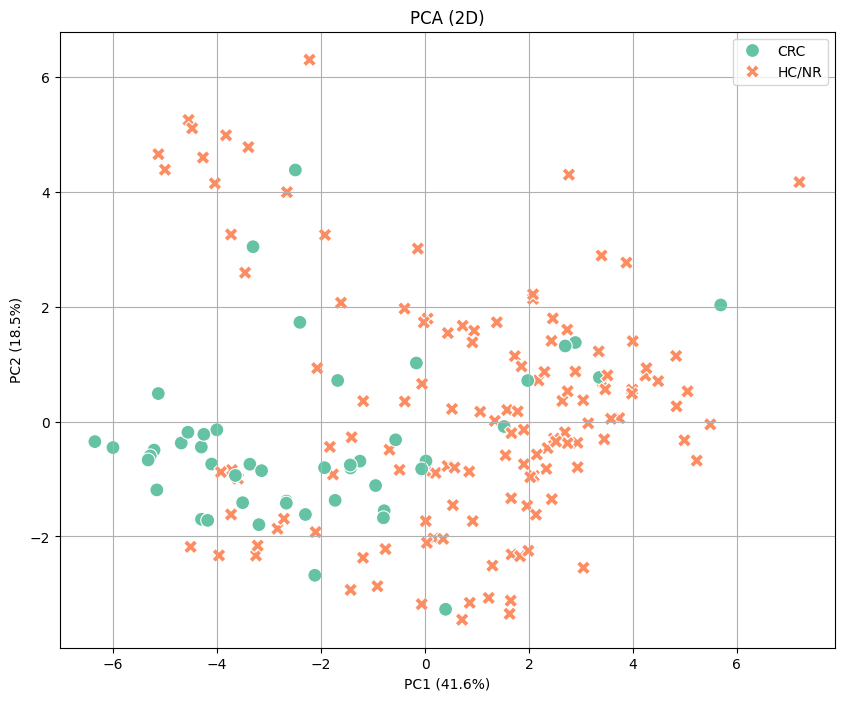

Running PLS-DA with 2 components...


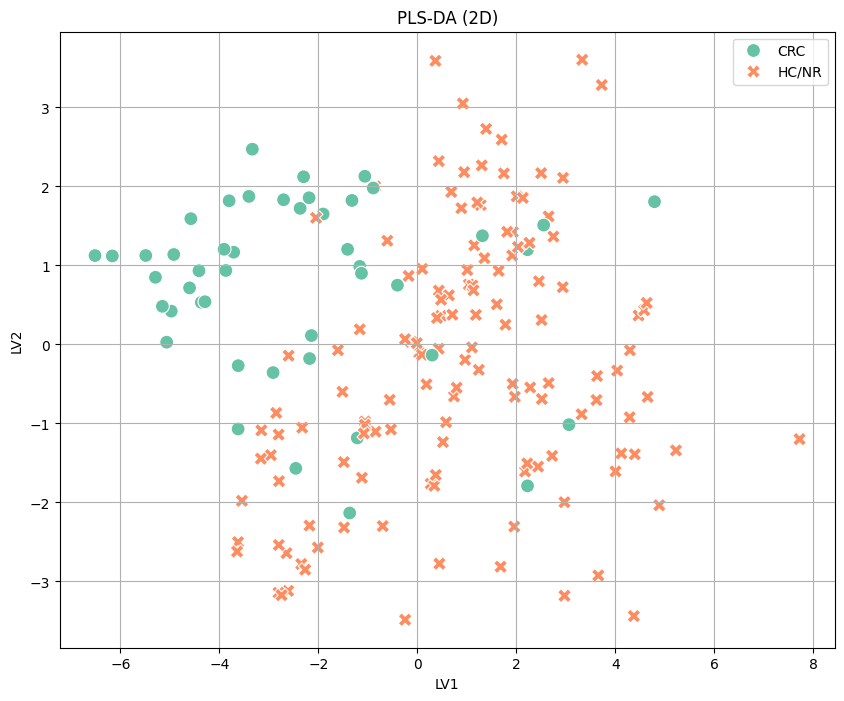

,LV1,LV2,Group
0,-0.402967,0.749702,CRC
1,-0.699912,-2.299559,HC/NR
2,-3.621421,-0.269137,CRC
3,-2.178084,-0.179083,CRC
4,0.038727,-0.104441,HC/NR
...,...,...,...
174,-1.485331,-1.489310,HC/NR
175,-2.851501,-0.867120,HC/NR
176,-3.162292,-1.445867,HC/NR
177,1.103191,-0.038270,HC/NR


In [10]:
run_pca_and_plot(bf_feats)
run_pls_da_and_plot(bf_feats)

Running PCA with 2 components...


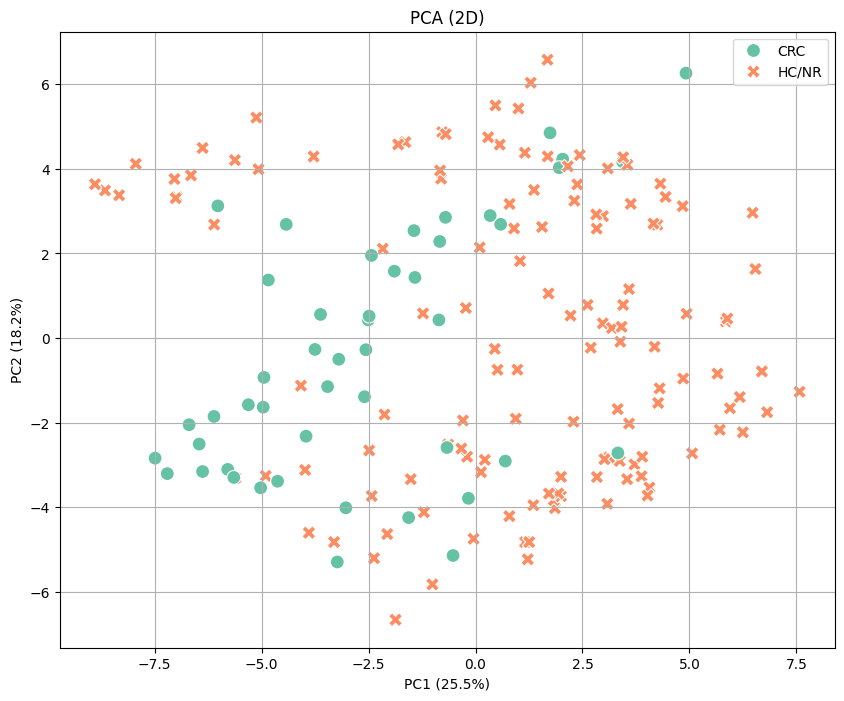

Running PLS-DA with 2 components...


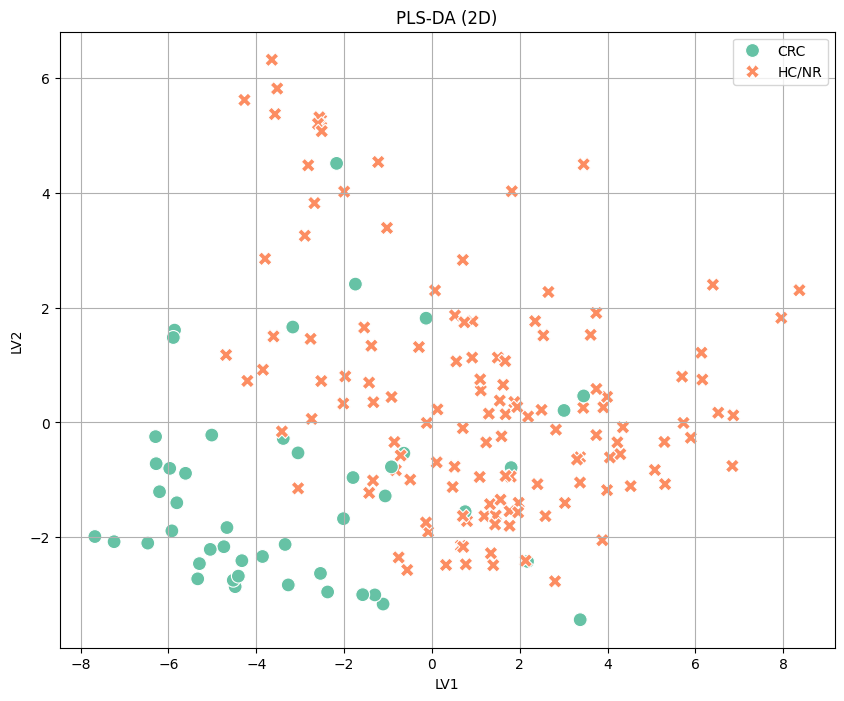

,LV1,LV2,Group
0,-1.063979,-1.281246,CRC
1,-2.894383,3.255050,HC/NR
2,-5.861490,1.610041,CRC
3,-3.168603,1.663734,CRC
4,0.925162,1.762219,HC/NR
...,...,...,...
174,-2.520585,0.721850,HC/NR
175,-3.416451,-0.157271,HC/NR
176,-2.738363,0.062483,HC/NR
177,0.704418,-0.098947,HC/NR


In [11]:
run_pca_and_plot(sign_feats)
run_pls_da_and_plot(sign_feats)

In [ ]:

#sens80 point in ROC AUC thres
def classification_pipeline(DF,random_state=48):
        
    # ===========================================
    #  Leave-One-Out CV Model Comparison (Tuned)
    # ===========================================
    import warnings
    warnings.filterwarnings("ignore")

    # --- Step 1️⃣: Data prep ---
    New_df = DF.copy()
    df_final = New_df[
        (New_df['Group'] != "TBD") & 
        (New_df['Group'] != "HC/R/NP") & 
        (New_df['Group'] != "HC/R/P")
    ].reset_index(drop=True)
    df_final['Group'] = df_final['Group'].replace({'HC/NR': 'Control', 'CRC': 'CRC'})
    X = df_final.drop(columns=['Subject', 'Group', 'index'], errors='ignore')
    feature_names = X.columns
    y = df_final['Group'].map({'Control': 0, 'CRC': 1})  # 0: Control, 1: CRC

    # --- Step 2️⃣: Define models & grids ---
    model_specs = {
        
        "LightGBM": (
            LGBMClassifier(
                objective="binary",
                class_weight="balanced",
                random_state=random_state,
                verbose=-1
            ),
            {
            "n_estimators": [200, 400],
            "learning_rate": [0.05, 0.1],
            "num_leaves": [15, 31],
            "max_depth": [3, 5],
            "min_child_samples": [20],  # default is fine
            "feature_fraction": [0.8],   # default 1.0 is usually fine
            "bagging_fraction": [0.8],   
            "reg_lambda": [1.0],         # start with default
            "reg_alpha": [0.0]           # start with default
            }
        ),

        "XGBoost": (
            XGBClassifier(
                objective="binary:logistic",
                eval_metric="logloss",
                use_label_encoder=False,
                random_state=random_state,
                tree_method="hist",  # faster for small datasets
                scale_pos_weight=2.8, # 112/33 hc / crc leave None; use sample weights if needed
                verbosity=0
            ),
            {
            "n_estimators": [200, 400],
            "learning_rate": [0.05, 0.1],
            "max_depth": [3, 5],
            "min_child_weight": [5],     # one value is enough
            "subsample": [0.8],
            "colsample_bytree": [0.8],
            "gamma": [0],                # usually 0 is fine
            "reg_lambda": [1.0],
            "reg_alpha": [0.0]
            }
        ),
        
        "RandomForest": (
            RandomForestClassifier(class_weight="balanced", random_state=random_state),
            {"n_estimators": [500]}
        ),
        "Logistic L1 (Lasso)": (
            LogisticRegression(penalty="l1", solver="saga", class_weight="balanced", max_iter=5000),
            {"C": [0.001,0.01, 0.1, 1, 10]}
        ),
        "Logistic L2 (Ridge)": (
            LogisticRegression(penalty="l2", solver="lbfgs", class_weight="balanced", max_iter=5000),
            {"C": [0.001,0.01, 0.1, 1, 10]}
        ),
        "SVM (Linear)": (
            SVC(kernel="linear", probability=True, class_weight="balanced", random_state=random_state),
            {"C": [0.001,0.01, 0.1, 1,10]}
        ),
        "SVM (RBF)": (
            SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=random_state),
            {"C": [0.0001,0.001,0.01, 0.1, 1,10], "gamma": ["scale","auto"]}
        ),

        "Logistic ElasticNet": (
            LogisticRegression(
                penalty="elasticnet", 
                solver="saga",  # only solver that supports elasticnet
                class_weight="balanced", 
                max_iter=5000
            ),
            {
                "C": [0.001, 0.01, 0.1, 1, 10],
                "l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9]  # NOW this matters!
            }
        ),
        
        "KNN": (
            KNeighborsClassifier(),
            {"n_neighbors": [5, 7, 9,11,13,15], "weights": ["distance","uniform"]}
        ),
        "AdaBoost": (
            AdaBoostClassifier(random_state=random_state),
            {"n_estimators": [500], "learning_rate": [0.01, 0.1, 1]}
        ),
        "NeuralNet": (
            MLPClassifier(max_iter=2000, random_state=random_state),
            {"alpha": [0.001, 0.01, 0.1], "activation": ["relu"], "hidden_layer_sizes": [(20,),(20, 10)]}
        )
    }

    # --- Step 3️⃣: Initialize containers ---
    model_results = []
    roc_data = {}
    best_params = {}
    loo = LeaveOneOut()

    # --- Step 4️⃣: LOOCV main loop ---
    for model_name, (base_model, param_grid) in model_specs.items():
        print(f"\n🔹 Training model: {model_name}")
        y_true_all, y_proba_all, y_pred_all = [], [], []
        inner_best_params = []

        for train_idx, test_idx in loo.split(X):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

            # --- Feature selection step (Welch + Wilcoxon) ---
            selected_features = []
            for col in X_train.columns:
                try:
                    # Welch's t-test
                    stat_t, p_t = stats.ttest_ind(X_train[col][y_train==0], X_train[col][y_train==1], equal_var=False)
                    # Wilcoxon rank-sum test (Mann-Whitney)
                    w_stat, p_w = stats.mannwhitneyu(X_train[col][y_train==0], X_train[col][y_train==1],alternative="two-sided")
                    
                    # Keep feature if significant in both
                    if (p_t < 0.05) and (p_w < 0.05):
                        selected_features.append(col)
                except:
                    continue  # skip any problematic features

            # Apply feature selection
            X_train_fs = X_train[selected_features]
            X_test_fs = X_test[selected_features]

            print(X_train[selected_features].shape)

            # Standardize
            scaler = StandardScaler()
            X_train_scaled = scaler.fit_transform(X_train_fs)
            X_test_scaled = scaler.transform(X_test_fs)

            # Sample weights only for models that accept them
            sample_weights = None
            if model_name in ["AdaBoost", "NeuralNet"]:
                sample_weights = compute_sample_weight("balanced", y_train)

            # Inner grid search with Stratified CV
            inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)
            grid = GridSearchCV(
                estimator=base_model,
                param_grid=param_grid,
                scoring="roc_auc",
                cv=inner_cv,
                n_jobs=-1
            )
            # Fit with sample weights if applicable
            grid.fit(
                X_train_scaled,
                y_train,
                **({"sample_weight": sample_weights} if sample_weights is not None else {})
            )

            best_model = grid.best_estimator_
            inner_best_params.append(grid.best_params_)

            # Predict test sample
            proba = best_model.predict_proba(X_test_scaled)[:, 1][0]
            pred = best_model.predict(X_test_scaled)[0]

            y_true_all.append(y_test.values[0])
            y_proba_all.append(proba)
            y_pred_all.append(pred)

        # Convert lists to arrays
        y_true_all, y_proba_all, y_pred_all = map(np.array, [y_true_all, y_proba_all, y_pred_all])
        roc_data[model_name] = (y_true_all, y_proba_all)
        best_params[model_name] = pd.DataFrame(inner_best_params).mode().iloc[0].to_dict()

        # --- ROC metrics & Youden threshold ---
        fpr, tpr, thresholds = roc_curve(y_true_all, y_proba_all)
        auc = roc_auc_score(y_true_all, y_proba_all)
        youden = tpr - fpr
        best_idx = np.argmax(youden)
        best_thr = thresholds[best_idx]
        best_sens, best_spec = tpr[best_idx], 1 - fpr[best_idx]

        # --- Strategy 2: Sensitivity ≥ 0.8 ---
        target_sens = 0.8
        idx_sens = np.where(tpr >= target_sens)[0]
        if len(idx_sens) > 0:
            idx80 = idx_sens[0]
            thr80 = thresholds[idx80]
            sens80, spec80 = tpr[idx80], 1 - fpr[idx80]
        else:
            thr80, sens80, spec80 = np.nan, np.nan, np.nan

        # --- Confusion metrics at Youden ---
        pred_youden = (y_proba_all >= best_thr).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true_all, pred_youden).ravel()
        sens_y = tp / (tp + fn)
        spec_y = tn / (tn + fp)
        bal_acc_y = balanced_accuracy_score(y_true_all, pred_youden)

        # --- Confusion metrics at Sens≥0.8 ---
        if not np.isnan(thr80):
            pred_80 = (y_proba_all >= thr80).astype(int)
            tn2, fp2, fn2, tp2 = confusion_matrix(y_true_all, pred_80).ravel()
            sens_80calc = tp2 / (tp2 + fn2)
            spec_80calc = tn2 / (tn2 + fp2)
            bal_acc_80 = balanced_accuracy_score(y_true_all, pred_80)
        else:
            sens_80calc = spec_80calc = bal_acc_80 = np.nan

        # --- Store summary ---
        model_results.append({
            "Model": model_name,
            "ROC_AUC": auc,
            "Sens_Youden": sens_y,
            "Spec_Youden": spec_y,
            "BalancedAcc_Youden": bal_acc_y,
            "Youden_Threshold": best_thr,
            "Sens≥0.8": sens_80calc,
            "Spec_at_Sens≥0.8": spec_80calc,
            "BalancedAcc_Sens≥0.8": bal_acc_80,
            "Thr_Sens≥0.8": thr80,
            "Best_Params": best_params[model_name]
        })

        print(f"    ✅ AUC = {auc:.3f} | Youden thr = {best_thr:.3f} | Sens = {sens_y:.3f} | Spec = {spec_y:.3f}")
        if not np.isnan(thr80):
            print(f"    🎯 Sens≥0.8 thr = {thr80:.3f} | Sens = {sens_80calc:.3f} | Spec = {spec_80calc:.3f}")
        print(f"    ⚙️  Best params (mode): {best_params[model_name]}")

    # --- Step 5️⃣: Summary table ---
    results_df = pd.DataFrame(model_results).sort_values(by="ROC_AUC", ascending=False).reset_index(drop=True)
    print("\n📊 Comprehensive Model Comparison:\n")
    print(results_df.to_string(index=False))

     # --- Step 6️⃣: Plot ROC curves + Youden + Sens≥0.8 points ---
    plt.figure(figsize=(8, 6))
    colors = ["darkorange", "navy", "green", "purple", "brown", "red", "teal", "magenta", "cyan", "lime", "gold"]

    # Compute AUCs and sort model names by descending AUC
    auc_order = {}
    for model_name, (y_true, y_proba) in roc_data.items():
        auc_order[model_name] = roc_auc_score(y_true, y_proba)

    sorted_models = sorted(auc_order.keys(), key=lambda x: auc_order[x], reverse=True)

    for color, model_name in zip(colors, sorted_models):
        y_true, y_proba = roc_data[model_name]
        fpr, tpr, thr = roc_curve(y_true, y_proba)
        auc = roc_auc_score(y_true, y_proba)

        # Youden point
        youden = tpr - fpr
        best_idx = np.argmax(youden)

        # Sensitivity ≥ 0.8 point (if exists)
        idx_sens = np.where(tpr >= 0.8)[0]
        has_sens80 = len(idx_sens) > 0
        if has_sens80:
            idx80 = idx_sens[0]
            sens80_y, spec80_x = tpr[idx80], fpr[idx80]

        # Plot ROC curve
        plt.plot(fpr, tpr, color=color, lw=2, label=f"{model_name} (AUC={auc:.2f})")

        # Plot Youden point
        plt.scatter(fpr[best_idx], tpr[best_idx], color=color, marker='o', s=70,
                    edgecolor='black', label="_nolegend_")

        # Plot Sens≥0.8 point (★)
        if has_sens80:
            plt.scatter(spec80_x, sens80_y, color=color, marker='*', s=150,
                        edgecolor='black', label="_nolegend_")

    # Diagonal reference line
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray")

    plt.xlabel("1 - Specificity (False Positive Rate)")
    plt.ylabel("Sensitivity (True Positive Rate)")
    plt.title("ROC Curves – Model Comparison (LOOCV, Tuned)")
    plt.legend(loc="lower right", fontsize=8)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig("roc_curves.jpg", dpi=400)
    plt.show()


In [ ]:
classification_pipeline(bf_feats)

In [13]:
feat_df[feat_df['Group']=="HC/R/NP"]

,Subject,Group,NR_Chip1,NR_Chip2,NR_Chip3,NR_Chip4,NR_Chip5,NR_Chip6,NR_Chip7,NR_Chip8,...,Decay_R90_Chip7,Decay_R90_Chip8,Decay_R50_Chip1,Decay_R50_Chip2,Decay_R50_Chip3,Decay_R50_Chip4,Decay_R50_Chip5,Decay_R50_Chip6,Decay_R50_Chip7,Decay_R50_Chip8
5,ONCODE010012,HC/R/NP,0.361707,0.736762,0.478793,0.463665,0.347336,0.410579,0.259522,0.237744,...,14757.954964,11597.947080,2610.868099,4126.140680,4965.944646,4817.795864,3803.317205,10011.068718,2903.079455,2763.471774
7,ONCODE010015,HC/R/NP,0.639077,0.242455,0.207395,0.260768,0.819259,0.613344,0.836412,0.882960,...,25843.414230,25039.718417,8425.251998,3189.128841,2765.561765,2804.160755,3457.080759,12427.779635,4937.100497,3881.048792
9,ONCODE010019,HC/R/NP,0.659639,0.320862,0.201957,0.264515,0.671577,0.620157,0.275143,0.758951,...,24065.363097,24975.292010,3589.910412,3280.134987,2998.442798,3202.218655,2471.711846,16099.345940,3944.990776,4319.555626
11,ONCODE010022,HC/R/NP,0.667537,0.653873,0.293106,0.385344,0.573593,0.603978,0.320763,0.530477,...,24244.184543,14395.256533,3827.790221,3567.239082,3020.797948,3304.063473,2931.097627,9043.579394,4702.241916,3939.054867
14,ONCODE010026,HC/R/NP,0.638074,0.136261,0.026006,0.044917,0.975417,0.879020,0.833402,0.966990,...,26198.082242,25216.480118,11818.214551,5079.849787,4640.244447,4905.800897,5234.266851,17340.923096,7608.925442,5881.312409
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
479,ONCODE050098,HC/R/NP,0.277730,0.199802,0.170929,0.106229,0.812711,0.949031,0.678398,0.762941,...,23196.092104,22309.650516,13307.420868,4480.663685,2734.724935,2617.379813,3305.412245,10116.162633,6799.625610,3703.564622
482,ONCODE050103,HC/R/NP,0.613246,0.263804,0.146331,0.135246,0.803300,0.967305,0.928033,0.931698,...,24784.643741,24607.444421,16588.915299,3684.077565,3551.165811,3697.129527,3235.738380,13728.913147,8471.844591,7491.197361
483,ONCODE050105,HC/R/NP,0.357102,0.373938,0.288779,0.248904,0.718727,0.800218,0.592140,0.669765,...,24573.778336,19064.494880,12930.354753,2273.295366,2829.050132,2949.934682,2802.226061,2861.251985,5171.215334,2738.205023
484,ONCODE050106,HC/R/NP,0.501268,0.370957,0.323103,0.243726,0.619499,0.759182,0.634695,0.611581,...,19225.863187,18445.415238,2347.682796,4353.299535,4626.853578,3820.313725,3935.571329,3464.212574,4227.202523,3928.801026


In [ ]:
results=classification_pipeline(feat_df,random_state=48)

In [14]:
sum(feat_df["Group"]=="CRC")

47

In [15]:
sum(feat_df["Group"]=="HC/NR")

132

In [16]:
sum(feat_df["Group"]=="HC/R/P")

66

In [17]:
feat_df[feat_df["Group"]!="TBD"]

,Subject,Group,NR_Chip1,NR_Chip2,NR_Chip3,NR_Chip4,NR_Chip5,NR_Chip6,NR_Chip7,NR_Chip8,...,Decay_R90_Chip7,Decay_R90_Chip8,Decay_R50_Chip1,Decay_R50_Chip2,Decay_R50_Chip3,Decay_R50_Chip4,Decay_R50_Chip5,Decay_R50_Chip6,Decay_R50_Chip7,Decay_R50_Chip8
0,ONCODE010005,CRC,0.663044,0.616256,0.307575,0.348344,0.581525,0.657822,0.567331,0.505618,...,23885.212029,13738.225422,3358.236409,3622.231464,3477.078722,3155.439952,3843.666950,8500.083151,6506.169008,4167.785771
1,ONCODE010006,HC/NR,0.773844,0.209797,0.217407,0.288170,0.733170,0.824154,0.243338,0.557128,...,23868.778711,20410.507466,2599.156735,3147.643282,2471.187783,2619.576693,3061.746131,14026.815737,4583.576467,4010.529023
3,ONCODE010009,CRC,0.963926,0.277716,0.078136,0.078754,0.952403,0.756568,0.952979,0.915639,...,24473.108313,24790.173732,5002.163319,8257.939953,5303.249399,5710.568872,3248.138018,15332.569331,8518.427631,7027.027173
4,ONCODE010011,HC/R/P,0.975291,0.303858,0.142579,0.084711,0.983937,0.687525,0.302416,0.740486,...,24508.605289,23648.664952,9177.101271,8781.772798,7521.327748,7405.373738,5418.763053,17414.525877,14468.822374,10787.391298
5,ONCODE010012,HC/R/NP,0.361707,0.736762,0.478793,0.463665,0.347336,0.410579,0.259522,0.237744,...,14757.954964,11597.947080,2610.868099,4126.140680,4965.944646,4817.795864,3803.317205,10011.068718,2903.079455,2763.471774
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
525,ONCOPT030455,HC/NR,0.864342,0.530985,0.139950,0.181177,0.760096,0.821610,0.776616,0.374112,...,24123.238185,24713.278067,10989.319929,12960.043669,3786.415641,6142.077367,4170.434197,4500.883140,10712.901232,11429.840150
526,ONCOPT030456,HC/NR,0.733092,0.487147,0.130650,0.136591,0.892064,0.964197,0.807592,0.434691,...,24887.152795,26387.067371,11061.606949,14846.526134,3974.206408,5177.480966,3800.480290,8674.744022,10536.271650,8985.892032
527,ONCOPT030457,HC/NR,0.782168,0.252819,0.113891,0.126324,0.795807,0.869290,0.821259,0.376943,...,26291.966372,28662.642246,13628.295019,11921.182104,2235.986099,5706.679966,2250.047016,2827.905690,12695.026442,14925.998559
528,ONCOPT030458,HC/NR,0.976483,0.615049,0.595798,0.275475,0.989245,0.972091,0.906321,0.286030,...,25292.153867,24819.627295,14558.004805,14146.628388,3161.913228,8048.910900,4175.235225,8817.946878,13340.157434,13302.871199


In [18]:
#plot only those with monotonic characteristics
def generate_visualizations_monotonic(df_filtered):
    print("Generating visualizations...")

    # 1️⃣ Remove "TBD" entries
    df_filtered = df_filtered[df_filtered['Group'] != "TBD"].copy()

    # 2️⃣ Identify feature (numeric) columns
    sensor_columns = [col for col in df_filtered.columns if col not in ["Subject", "Group"]]

    # 3️⃣ Z-score normalization for numeric columns
    df_filtered[sensor_columns] = df_filtered[sensor_columns].apply(
        lambda x: (x - x.mean()) / x.std()
    )

    # 4️⃣ Define group order
    group_order = ["HC/NR", "HC/R/NP", "HC/R/P", "CRC"]

    # 5️⃣ Filter features based on monotonic median progression
    valid_features = []
    
    for col in sensor_columns:
        # Calculate median for each group
        medians = df_filtered.groupby('Group')[col].median()
        
        # Ensure all groups exist
        if not all(group in medians.index for group in group_order):
            continue
            
        # Get medians in the correct order
        m1 = medians["HC/NR"]
        m2 = medians["HC/R/NP"]
        m3 = medians["HC/R/P"]
        m4 = medians["CRC"]
        
        # Check for monotonic increasing or decreasing
        is_increasing = (m1 < m2 < m3 < m4)
        is_decreasing = (m1 > m2 > m3 > m4)
        
        if is_increasing or is_decreasing:
            valid_features.append(col)
            direction = "increasing" if is_increasing else "decreasing"
            print(f"✓ {col}: {direction} ({m1:.3f} → {m2:.3f} → {m3:.3f} → {m4:.3f})")
    
    print(f"\nFound {len(valid_features)} features with monotonic progression out of {len(sensor_columns)} total.")
    
    # If no valid features, exit
    if len(valid_features) == 0:
        print("No features satisfy the monotonic progression criterion.")
        return
    
    # 6️⃣ Filter to only valid features
    sensor_columns = valid_features

    # 7️⃣ Automatically detect main feature name
    main_feature = "" if len(sensor_columns) > 1 else sensor_columns[0]

    # 8️⃣ Prepare output folder
    output_folder = f"plots_{main_feature}_monotonic"
    os.makedirs(output_folder, exist_ok=True)

    # 9️⃣ Melt for plotting (only valid features)
    df_melted = df_filtered.melt(
        id_vars=["Subject", "Group"],
        value_vars=sensor_columns,
        var_name="Chip",
        value_name=main_feature if main_feature else "Z-score"
    )

    # 🔟 Boxplot
    plt.figure(figsize=(10, 7))
    sns.boxplot(
        data=df_melted, 
        x="Chip", 
        y=main_feature if main_feature else "Z-score", 
        hue="Group",
        hue_order=group_order[::-1],
        flierprops={"marker": "o", "markersize": 2}
    )
    plt.xticks(rotation=45)
    plt.title("Features bonf. corrected with monotonic progression across groups")
    plt.ylabel("Z-scores")
    plt.xlabel("")
    plt.legend(title="Group", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.savefig(os.path.join(output_folder, f"grouped_boxplot_{main_feature}.jpg"), dpi=400, bbox_inches="tight")
    plt.close()

    # 1️⃣1️⃣ Box + Strip plot
    plt.figure(figsize=(14, 7))
    sns.boxplot(
        data=df_melted, 
        x="Chip", 
        y=main_feature if main_feature else "Z-score", 
        hue="Group",
        hue_order=group_order[::-1]
    )
    sns.stripplot(
        data=df_melted, 
        x="Chip", 
        y=main_feature if main_feature else "Z-score", 
        hue="Group", 
        hue_order=group_order[::-1],
        dodge=True, 
        palette="Set1", 
        alpha=0.5, 
        linewidth=1.3
    )
    plt.xticks(rotation=45)
    plt.title(f"Features with monotonic progression (Boxplot + Stripplot, Z-scored)")
    plt.legend(title="Group", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.savefig(os.path.join(output_folder, f"strip_boxplot_{main_feature}.jpg"), dpi=500, bbox_inches="tight")
    plt.close()
    
    print(f"\nPlots saved to '{output_folder}/'")

In [ ]:
generate_visualizations_monotonic(bf_feats)

In [19]:
#sens85 theshold point on ROC AUC curve (this is the one in the deliverable, but i think with all features inside, it was the bug with feature selection)
def classification_pipeline_update(DF,random_state=48):
        
    # ===========================================
    #  Leave-One-Out CV Model Comparison (Tuned)
    # ===========================================
    import warnings
    warnings.filterwarnings("ignore")

    # --- Step 1️⃣: Data prep ---
    New_df = DF.copy()
    df_final = New_df[
        (New_df['Group'] != "TBD") & 
        (New_df['Group'] != "HC/R/NP") & 
        (New_df['Group'] != "HC/R/P")
    ].reset_index(drop=True)
    df_final['Group'] = df_final['Group'].replace({'HC/NR': 'Control', 'CRC': 'CRC'})
    X = df_final.drop(columns=['Subject', 'Group', 'index'], errors='ignore')
    feature_names = X.columns
    y = df_final['Group'].map({'Control': 0, 'CRC': 1})  # 0: Control, 1: CRC

    # --- Step 2️⃣: Define models & grids ---
    model_specs = {
        
        "LightGBM": (
            LGBMClassifier(
                objective="binary",
                class_weight="balanced",
                random_state=random_state,
                verbose=-1
            ),
            {
            "n_estimators": [200, 400],
            "learning_rate": [0.05, 0.1],
            "num_leaves": [15, 31],
            "max_depth": [3, 5],
            "min_child_samples": [20],  # default is fine
            "feature_fraction": [0.8],   # default 1.0 is usually fine
            "bagging_fraction": [0.8],   
            "reg_lambda": [1.0],         # start with default
            "reg_alpha": [0.0]           # start with default
            }
        ),

        "XGBoost": (
            XGBClassifier(
                objective="binary:logistic",
                eval_metric="logloss",
                use_label_encoder=False,
                random_state=random_state,
                tree_method="hist",  # faster for small datasets
                scale_pos_weight=2.8, # 132/47 hc / crc leave None; use sample weights if needed
                verbosity=0
            ),
            {
            "n_estimators": [200, 400],
            "learning_rate": [0.05, 0.1],
            "max_depth": [3, 5],
            "min_child_weight": [5],     # one value is enough
            "subsample": [0.8],
            "colsample_bytree": [0.8],
            "gamma": [0],                # usually 0 is fine
            "reg_lambda": [1.0],
            "reg_alpha": [0.0]
            }
        ),
        
        "RandomForest": (
            RandomForestClassifier(class_weight="balanced", random_state=random_state),
            {"n_estimators": [500]}
        ),
        "Logistic L1 (Lasso)": (
            LogisticRegression(penalty="l1", solver="saga", class_weight="balanced", max_iter=5000),
            {"C": [0.001,0.01, 0.1, 1, 10]}
        ),
        "Logistic L2 (Ridge)": (
            LogisticRegression(penalty="l2", solver="lbfgs", class_weight="balanced", max_iter=5000),
            {"C": [0.001,0.01, 0.1, 1, 10]}
        ),
        "SVM (Linear)": (
            SVC(kernel="linear", probability=True, class_weight="balanced", random_state=random_state),
            {"C": [0.001,0.01, 0.1, 1,10]}
        ),
        "SVM (RBF)": (
            SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=random_state),
            {"C": [0.0001,0.001,0.01, 0.1, 1,10], "gamma": ["scale","auto"]}
        ),

        "Logistic ElasticNet": (
            LogisticRegression(
                penalty="elasticnet", 
                solver="saga",  # only solver that supports elasticnet
                class_weight="balanced", 
                max_iter=5000
            ),
            {
                "C": [0.001, 0.01, 0.1, 1, 10],
                "l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9]  # NOW this matters!
            }
        ),
        
        "KNN": (
            KNeighborsClassifier(),
            {"n_neighbors": [5, 7, 9,11,13,15], "weights": ["distance","uniform"]}
        ),
        "AdaBoost": (
            AdaBoostClassifier(random_state=random_state),
            {"n_estimators": [500], "learning_rate": [0.01, 0.1, 1]}
        ),
        "NeuralNet": (
            MLPClassifier(max_iter=2000, random_state=random_state),
            {"alpha": [0.001, 0.01, 0.1], "activation": ["relu"], "hidden_layer_sizes": [(20,),(20, 10)]}
        )
    }

    # --- Step 3️⃣: Initialize containers ---
    model_results = []
    roc_data = {}
    best_params = {}
    loo = LeaveOneOut()

    # --- Step 4️⃣: LOOCV main loop ---
    for model_name, (base_model, param_grid) in model_specs.items():
        print(f"\n🔹 Training model: {model_name}")
        y_true_all, y_proba_all, y_pred_all = [], [], []
        inner_best_params = []

        for train_idx, test_idx in loo.split(X):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

            # --- Feature selection step (Welch + Wilcoxon) ---
            selected_features = []
            for col in X_train.columns:
                try:
                    # Welch's t-test
                    stat_t, p_t = stats.ttest_ind(X_train[col][y_train==0], X_train[col][y_train==1], equal_var=False)
                    # Wilcoxon rank-sum test (Mann-Whitney)
                    w_stat, p_w = stats.mannwhitneyu(X_train[col][y_train==0], X_train[col][y_train==1],alternative="two-sided")
                    
                    # Keep feature if significant in both
                    if (p_t < 0.05) and (p_w < 0.05):
                        selected_features.append(col)
                except:
                    continue  # skip any problematic features

            # Apply feature selection
            X_train_fs = X_train[selected_features]
            X_test_fs = X_test[selected_features]

            print(X_train[selected_features].shape)

            # Standardize
            scaler = StandardScaler()
            X_train_scaled = scaler.fit_transform(X_train_fs)
            X_test_scaled = scaler.transform(X_test_fs)

            # Sample weights only for models that accept them
            sample_weights = None
            if model_name in ["AdaBoost", "NeuralNet"]:
                sample_weights = compute_sample_weight("balanced", y_train)

            # Inner grid search with Stratified CV
            inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)
            grid = GridSearchCV(
                estimator=base_model,
                param_grid=param_grid,
                scoring="roc_auc",
                cv=inner_cv,
                n_jobs=-1
            )
            # Fit with sample weights if applicable
            grid.fit(
                X_train_scaled,
                y_train,
                **({"sample_weight": sample_weights} if sample_weights is not None else {})
            )

            best_model = grid.best_estimator_
            inner_best_params.append(grid.best_params_)

            # Predict test sample
            proba = best_model.predict_proba(X_test_scaled)[:, 1][0]
            pred = best_model.predict(X_test_scaled)[0]

            y_true_all.append(y_test.values[0])
            y_proba_all.append(proba)
            y_pred_all.append(pred)

        # Convert lists to arrays
        y_true_all, y_proba_all, y_pred_all = map(np.array, [y_true_all, y_proba_all, y_pred_all])
        roc_data[model_name] = (y_true_all, y_proba_all)
        best_params[model_name] = pd.DataFrame(inner_best_params).mode().iloc[0].to_dict()

        # --- ROC metrics & Youden threshold ---
        fpr, tpr, thresholds = roc_curve(y_true_all, y_proba_all)
        auc = roc_auc_score(y_true_all, y_proba_all)
        youden = tpr - fpr
        best_idx = np.argmax(youden)
        best_thr = thresholds[best_idx]
        best_sens, best_spec = tpr[best_idx], 1 - fpr[best_idx]

        # --- Strategy 2: Sensitivity ≥ 0.85 ---
        target_sens = 0.85
        idx_sens = np.where(tpr >= target_sens)[0]
        if len(idx_sens) > 0:
            idx85 = idx_sens[0]
            thr85 = thresholds[idx85]
            sens85, spec85 = tpr[idx85], 1 - fpr[idx85]
        else:
            thr85, sens85, spec85 = np.nan, np.nan, np.nan

        # --- Confusion metrics at Youden ---
        pred_youden = (y_proba_all >= best_thr).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true_all, pred_youden).ravel()
        sens_y = tp / (tp + fn)
        spec_y = tn / (tn + fp)
        bal_acc_y = balanced_accuracy_score(y_true_all, pred_youden)

        # --- Confusion metrics at Sens≥0.85 ---
        if not np.isnan(thr85):
            pred_85 = (y_proba_all >= thr85).astype(int)
            tn2, fp2, fn2, tp2 = confusion_matrix(y_true_all, pred_85).ravel()
            sens_85calc = tp2 / (tp2 + fn2)
            spec_85calc = tn2 / (tn2 + fp2)
            bal_acc_85 = balanced_accuracy_score(y_true_all, pred_85)
        else:
            sens_85calc = spec_85calc = bal_acc_85 = np.nan

        # --- Store summary ---
        model_results.append({
            "Model": model_name,
            "ROC_AUC": auc,
            "Sens_Youden": sens_y,
            "Spec_Youden": spec_y,
            "BalancedAcc_Youden": bal_acc_y,
            "Youden_Threshold": best_thr,
            "Sens≥0.85": sens_85calc,
            "Spec_at_Sens≥0.85": spec_85calc,
            "BalancedAcc_Sens≥0.85": bal_acc_85,
            "Thr_Sens≥0.85": thr85,
            "Best_Params": best_params[model_name]
        })

        print(f"    ✅ AUC = {auc:.3f} | Youden thr = {best_thr:.3f} | Sens = {sens_y:.3f} | Spec = {spec_y:.3f}")
        if not np.isnan(thr85):
            print(f"    🎯 Sens≥0.85 thr = {thr85:.3f} | Sens = {sens_85calc:.3f} | Spec = {spec_85calc:.3f}")
        print(f"    ⚙️  Best params (mode): {best_params[model_name]}")

    # --- Step 5️⃣: Summary table ---
    results_df = pd.DataFrame(model_results).sort_values(by="ROC_AUC", ascending=False).reset_index(drop=True)
    print("\n📊 Comprehensive Model Comparison:\n")
    print(results_df.to_string(index=False))

     # --- Step 6️⃣: Plot ROC curves + Youden + Sens≥0.85 points ---
    plt.figure(figsize=(8, 6))
    colors = ["darkorange", "navy", "green", "purple", "brown", "red", "teal", "magenta", "cyan", "lime", "gold"]

    # Compute AUCs and sort model names by descending AUC
    auc_order = {}
    for model_name, (y_true, y_proba) in roc_data.items():
        auc_order[model_name] = roc_auc_score(y_true, y_proba)

    sorted_models = sorted(auc_order.keys(), key=lambda x: auc_order[x], reverse=True)

    for color, model_name in zip(colors, sorted_models):
        y_true, y_proba = roc_data[model_name]
        fpr, tpr, thr = roc_curve(y_true, y_proba)
        auc = roc_auc_score(y_true, y_proba)

        # Youden point
        youden = tpr - fpr
        best_idx = np.argmax(youden)

        # Sensitivity ≥ 0.85 point (if exists)
        idx_sens = np.where(tpr >= 0.85)[0]
        has_sens85 = len(idx_sens) > 0
        if has_sens85:
            idx85 = idx_sens[0]
            sens85_y, spec85_x = tpr[idx85], fpr[idx85]

        # Plot ROC curve
        plt.plot(fpr, tpr, color=color, lw=2, label=f"{model_name} (AUC={auc:.2f})")

        # Plot Youden point
        plt.scatter(fpr[best_idx], tpr[best_idx], color=color, marker='o', s=70,
                    edgecolor='black', label="_nolegend_")

        # Plot Sens≥0.85 point (★)
        if has_sens85:
            plt.scatter(spec85_x, sens85_y, color=color, marker='*', s=150,
                        edgecolor='black', label="_nolegend_")

    # Diagonal reference line
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray")

    plt.xlabel("1 - Specificity (False Positive Rate)")
    plt.ylabel("Sensitivity (True Positive Rate)")
    plt.title("ROC Curves – Model Comparison (LOOCV, Tuned)")
    plt.legend(loc="lower right", fontsize=8)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig("roc_curves.jpg", dpi=400)
    plt.show()

In [ ]:
classification_pipeline_update(feat_df)

In [ ]:
feat_df

In [ ]:
df=feat_df[feat_df["Subject"].str.startswith("ONCODE01")].iloc[:,0:2]

df[df["Group"].isin(["HC/NR", "HC/R/P","HC/R/NP","CRC","TBD"])].shape

In [22]:
#more hyperparameters
def classification_pipeline_v2(DF, random_state=48, outer_cv_method="loocv", 
                                feature_selection_method="fdr", fdr_alpha=0.1,
                                n_repeats=10, n_splits=5):
    """
    Nested CV classification pipeline for binary classification (Control vs CRC).
    
    Parameters:
    -----------
    DF : pd.DataFrame
        Input dataframe with 'Subject', 'Group', and feature columns
    random_state : int
        Random seed for reproducibility
    outer_cv_method : str
        'loocv' or 'repeated_stratified_kfold'
    feature_selection_method : str
        'strict' (both tests p<0.05), 'or' (either test), 'fdr' (FDR corrected)
    fdr_alpha : float
        FDR threshold if using FDR correction
    n_repeats : int
        Number of repeats for repeated stratified k-fold
    n_splits : int
        Number of splits for repeated stratified k-fold
    
    Returns:
    --------
    dict with results_df, final_models, roc_data, feature_importance
    """
    import warnings
    warnings.filterwarnings("ignore")
    
    # Standard imports
    import numpy as np
    import pandas as pd
    from scipy import stats  # FIXED: was missing
    from collections import Counter
    
    from sklearn.model_selection import (
        LeaveOneOut, StratifiedKFold, RepeatedStratifiedKFold, 
        GridSearchCV, cross_val_predict
    )
    from sklearn.preprocessing import StandardScaler
    from sklearn.utils.class_weight import compute_sample_weight
    from sklearn.metrics import (
        roc_curve, roc_auc_score, confusion_matrix, 
        balanced_accuracy_score, accuracy_score
    )
    import matplotlib.pyplot as plt
    
    # Optional: FDR correction
    try:
        from statsmodels.stats.multitest import fdrcorrection
        HAS_STATSMODELS = True
    except ImportError:
        HAS_STATSMODELS = False
        if feature_selection_method == "fdr":
            print("⚠️ statsmodels not available, falling back to 'or' method")
            feature_selection_method = "or"
    
    # Models
    from lightgbm import LGBMClassifier
    from xgboost import XGBClassifier
    from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
    from sklearn.linear_model import LogisticRegression
    from sklearn.svm import SVC
    from sklearn.neighbors import KNeighborsClassifier
    from sklearn.neural_network import MLPClassifier

    # =========================================================================
    # HELPER FUNCTIONS
    # =========================================================================
    
    def select_features(X_train, y_train, method="fdr", alpha=0.1):
        """
        Univariate feature selection with multiple testing correction options.
        """
        p_ttest = []
        p_mann = []
        features = list(X_train.columns)
        
        for col in features:
            g0 = X_train[col][y_train == 0].dropna()
            g1 = X_train[col][y_train == 1].dropna()
            
            # Skip if insufficient data
            if len(g0) < 3 or len(g1) < 3:
                p_ttest.append(1.0)
                p_mann.append(1.0)
                continue
            
            try:
                _, p_t = stats.ttest_ind(g0, g1, equal_var=False)
                _, p_m = stats.mannwhitneyu(g0, g1, alternative="two-sided")
                p_ttest.append(p_t)
                p_mann.append(p_m)
            except Exception:
                p_ttest.append(1.0)
                p_mann.append(1.0)
        
        p_ttest = np.array(p_ttest)
        p_mann = np.array(p_mann)
        
        if method == "strict":
            # Both tests must be significant
            selected = (p_ttest < 0.05) & (p_mann < 0.05)
        elif method == "or":
            # Either test significant
            selected = (p_ttest < 0.05) | (p_mann < 0.05)
        elif method == "fdr" and HAS_STATSMODELS:
            # FDR correction on Mann-Whitney (non-parametric, more robust)
            rejected, _ = fdrcorrection(p_mann, alpha=alpha)
            selected = rejected
        else:
            selected = (p_ttest < 0.05) | (p_mann < 0.05)
        
        selected_features = [f for f, s in zip(features, selected) if s]
        return selected_features, {"p_ttest": p_ttest, "p_mann": p_mann}
    
    def compute_metrics_at_threshold(y_true, y_proba, threshold):
        """Compute confusion matrix metrics at a given threshold."""
        y_pred = (y_proba >= threshold).astype(int)
        
        if len(np.unique(y_pred)) < 2 or len(np.unique(y_true)) < 2:
            return {"sens": np.nan, "spec": np.nan, "bal_acc": np.nan}
        
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
        sens = tp / (tp + fn) if (tp + fn) > 0 else np.nan
        spec = tn / (tn + fp) if (tn + fp) > 0 else np.nan
        bal_acc = balanced_accuracy_score(y_true, y_pred)
        
        return {"sens": sens, "spec": spec, "bal_acc": bal_acc, 
                "tp": tp, "tn": tn, "fp": fp, "fn": fn}

    # =========================================================================
    # DATA PREPARATION
    # =========================================================================
    
    df = DF.copy()
    df = df[~df['Group'].isin(["TBD", "HC/R/NP", "HC/R/P"])].reset_index(drop=True)
    df['Group'] = df['Group'].replace({'HC/NR': 'Control', 'CRC': 'CRC'})
    
    X = df.drop(columns=['Subject', 'Group', 'index'], errors='ignore')
    feature_names = list(X.columns)
    y = df['Group'].map({'Control': 0, 'CRC': 1})
    
    print(f"📊 Dataset: {len(y)} samples ({(y==0).sum()} Control, {(y==1).sum()} CRC)")
    print(f"📊 Features: {len(feature_names)}")
    print(f"📊 Outer CV: {outer_cv_method}, Feature selection: {feature_selection_method}")

    # =========================================================================
    # MODEL SPECIFICATIONS
    # =========================================================================
    
    model_specs = {
        "LightGBM": {
            "estimator": LGBMClassifier(
                objective="binary", class_weight="balanced", 
                random_state=random_state, verbose=-1
            ),
            "param_grid": {
                "n_estimators": [200, 400],
                "learning_rate": [0.05, 0.1],
                "num_leaves": [15, 31],
                "max_depth": [3, 5],
                "min_child_samples": [20],
                "reg_lambda": [1.0]
            },
            "uses_sample_weight": False
        },
        "XGBoost": {
            "estimator": XGBClassifier(
                objective="binary:logistic", eval_metric="logloss",
                use_label_encoder=False, random_state=random_state,
                tree_method="hist", scale_pos_weight=2.8, verbosity=0
            ),
            "param_grid": {
                "n_estimators": [200, 400],
                "learning_rate": [0.05, 0.1],
                "max_depth": [3, 5],
                "min_child_weight": [5],
                "subsample": [0.8],
                "colsample_bytree": [0.8]
            },
            "uses_sample_weight": False
        },
        "RandomForest": {
            "estimator": RandomForestClassifier(
                class_weight="balanced", random_state=random_state
            ),
            "param_grid": {"n_estimators": [300, 500], "max_depth": [5, 10, None]},
            "uses_sample_weight": False
        },
        "Logistic_L1": {
            "estimator": LogisticRegression(
                penalty="l1", solver="saga", class_weight="balanced", max_iter=5000
            ),
            "param_grid": {"C": [0.001, 0.01, 0.1, 1, 10]},
            "uses_sample_weight": False
        },
        "Logistic_L2": {
            "estimator": LogisticRegression(
                penalty="l2", solver="lbfgs", class_weight="balanced", max_iter=5000
            ),
            "param_grid": {"C": [0.001, 0.01, 0.1, 1, 10]},
            "uses_sample_weight": False
        },
        "SVM_Linear": {
            "estimator": SVC(
                kernel="linear", probability=True, 
                class_weight="balanced", random_state=random_state
            ),
            "param_grid": {"C": [0.01, 0.1, 1, 10]},
            "uses_sample_weight": False
        },
        "SVM_RBF": {
            "estimator": SVC(
                kernel="rbf", probability=True,
                class_weight="balanced", random_state=random_state
            ),
            "param_grid": {"C": [0.01, 0.1, 1, 10], "gamma": ["scale", "auto"]},
            "uses_sample_weight": False
        },
        "Logistic_ElasticNet": {
            "estimator": LogisticRegression(
                penalty="elasticnet", solver="saga", 
                class_weight="balanced", max_iter=5000
            ),
            "param_grid": {
                "C": [0.01, 0.1, 1, 10],
                "l1_ratio": [0.3, 0.5, 0.7]
            },
            "uses_sample_weight": False
        },
        "KNN": {
            "estimator": KNeighborsClassifier(),
            "param_grid": {"n_neighbors": [5, 7, 9, 11], "weights": ["distance", "uniform"]},
            "uses_sample_weight": False
        },
        "AdaBoost": {
            "estimator": AdaBoostClassifier(random_state=random_state),
            "param_grid": {"n_estimators": [100, 300], "learning_rate": [0.01, 0.1, 1]},
            "uses_sample_weight": True
        },
        "NeuralNet": {
            "estimator": MLPClassifier(max_iter=2000, random_state=random_state),
            "param_grid": {
                "alpha": [0.01, 0.1],
                "hidden_layer_sizes": [(20,), (20, 10)]
            },
            "uses_sample_weight": True
        }
    }

    # =========================================================================
    # SETUP OUTER CV
    # =========================================================================
    
    if outer_cv_method == "loocv":
        outer_cv = LeaveOneOut()
        n_outer_folds = len(y)
    else:
        outer_cv = RepeatedStratifiedKFold(
            n_splits=n_splits, n_repeats=n_repeats, random_state=random_state
        )
        n_outer_folds = n_splits * n_repeats

    # =========================================================================
    # MAIN NESTED CV LOOP
    # =========================================================================
    
    model_results = []
    roc_data = {}
    final_models = {}
    feature_tracker = {}  # Track feature selection across models
    
    for model_name, spec in model_specs.items():
        print(f"\n{'='*60}")
        print(f"🔹 {model_name}")
        print(f"{'='*60}")
        
        base_model = spec["estimator"]
        param_grid = spec["param_grid"]
        uses_sw = spec["uses_sample_weight"]
        
        y_true_all, y_proba_all, y_pred_all = [], [], []
        selected_features_per_fold = []
        fold_aucs = []
        
        for fold_idx, (train_idx, test_idx) in enumerate(outer_cv.split(X, y)):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
            
            # --- Feature Selection (inside fold) ---
            sel_feats, _ = select_features(
                X_train, y_train, 
                method=feature_selection_method, 
                alpha=fdr_alpha
            )
            
            # Fallback if no features selected
            if len(sel_feats) == 0:
                sel_feats = list(X_train.columns)
            
            selected_features_per_fold.append(set(sel_feats))
            
            X_train_fs = X_train[sel_feats]
            X_test_fs = X_test[sel_feats]
            
            # --- Scaling ---
            scaler = StandardScaler()
            X_train_sc = scaler.fit_transform(X_train_fs)
            X_test_sc = scaler.transform(X_test_fs)
            
            # --- Inner CV for hyperparameter tuning ---
            inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)
            
            grid = GridSearchCV(
                estimator=base_model, 
                param_grid=param_grid,
                scoring="roc_auc", 
                cv=inner_cv, 
                n_jobs=-1,
                error_score=0.5
            )
            
            # Fit with sample weights if needed
            fit_params = {}
            if uses_sw:
                fit_params["sample_weight"] = compute_sample_weight("balanced", y_train)
            
            try:
                grid.fit(X_train_sc, y_train, **fit_params)
                best_model = grid.best_estimator_
            except Exception as e:
                print(f"  ⚠️ Fold {fold_idx} failed: {e}")
                continue
            
            # --- Predict on held-out sample(s) ---
            try:
                proba = best_model.predict_proba(X_test_sc)[:, 1]
            except:
                try:
                    dec = best_model.decision_function(X_test_sc)
                    proba = 1 / (1 + np.exp(-dec))  # Sigmoid transform
                except:
                    proba = best_model.predict(X_test_sc).astype(float)
            
            pred = best_model.predict(X_test_sc)
            
            y_true_all.extend(y_test.values)
            y_proba_all.extend(proba)
            y_pred_all.extend(pred)
        
        # Convert to arrays
        y_true_all = np.array(y_true_all)
        y_proba_all = np.array(y_proba_all)
        y_pred_all = np.array(y_pred_all)
        
        if len(y_true_all) == 0:
            print(f"  ❌ No valid predictions for {model_name}")
            continue
        
        # --- Compute ROC metrics ---
        try:
            auc = roc_auc_score(y_true_all, y_proba_all)
            fpr, tpr, thresholds = roc_curve(y_true_all, y_proba_all)
        except Exception as e:
            print(f"  ❌ ROC computation failed: {e}")
            continue
        
        roc_data[model_name] = (y_true_all, y_proba_all, fpr, tpr, thresholds)
        
        # Youden's index
        youden = tpr - fpr
        best_idx = np.argmax(youden)
        thr_youden = thresholds[best_idx]
        metrics_youden = compute_metrics_at_threshold(y_true_all, y_proba_all, thr_youden)
        
        # Sens >= 85% threshold
        idx_85 = np.where(tpr >= 0.85)[0]
        if len(idx_85) > 0:
            thr_85 = thresholds[idx_85[0]]
            metrics_85 = compute_metrics_at_threshold(y_true_all, y_proba_all, thr_85)
        else:
            thr_85 = np.nan
            metrics_85 = {"sens": np.nan, "spec": np.nan, "bal_acc": np.nan}
        
        # Default threshold (0.5)
        metrics_default = compute_metrics_at_threshold(y_true_all, y_proba_all, 0.5)
        
        # --- Feature consistency analysis ---
        if len(selected_features_per_fold) > 0:
            all_feats = [f for s in selected_features_per_fold for f in s]
            feat_counts = Counter(all_feats)
            n_folds = len(selected_features_per_fold)
            
            # Features in ALL folds
            feats_all_folds = [f for f, c in feat_counts.items() if c == n_folds]
            # Features in >= 80% of folds
            feats_80pct = [f for f, c in feat_counts.items() if c >= 0.8 * n_folds]
            # Features in >= 50% of folds
            feats_50pct = [f for f, c in feat_counts.items() if c >= 0.5 * n_folds]
        else:
            feats_all_folds = feats_80pct = feats_50pct = []
            feat_counts = Counter()
        
        feature_tracker[model_name] = {
            "all_folds": feats_all_folds,
            "80pct": feats_80pct,
            "50pct": feats_50pct,
            "counts": feat_counts
        }
        
        # --- Store results ---
        model_results.append({
            "Model": model_name,
            "AUC": auc,
            # Youden threshold
            "Sens_Youden": metrics_youden["sens"],
            "Spec_Youden": metrics_youden["spec"],
            "BalAcc_Youden": metrics_youden["bal_acc"],
            "Thr_Youden": thr_youden,
            # Sens >= 85%
            "Sens_85": metrics_85["sens"],
            "Spec_85": metrics_85["spec"],
            "BalAcc_85": metrics_85["bal_acc"],
            "Thr_85": thr_85,
            # Default (0.5)
            "Sens_0.5": metrics_default["sens"],
            "Spec_0.5": metrics_default["spec"],
            # Feature info
            "N_Feats_AllFolds": len(feats_all_folds),
            "N_Feats_80pct": len(feats_80pct),
            "N_Feats_50pct": len(feats_50pct)
        })
        
        print(f"  ✅ AUC = {auc:.3f}")
        print(f"  📍 Youden: Sens={metrics_youden['sens']:.3f}, Spec={metrics_youden['spec']:.3f} @ thr={thr_youden:.3f}")
        print(f"  📍 Sens≥85%: Sens={metrics_85['sens']:.3f}, Spec={metrics_85['spec']:.3f} @ thr={thr_85:.3f}")
        print(f"  🧩 Features: {len(feats_all_folds)} in all folds, {len(feats_80pct)} in ≥80%")
        
        # =====================================================================
        # FINAL MODEL: Retrain on full data with proper feature selection
        # =====================================================================
        
        # Use features that appeared in >= 80% of folds (more stable than 100%)
        final_features = feats_80pct if len(feats_80pct) >= 3 else feats_50pct
        if len(final_features) < 3:
            final_features = list(X.columns)
            print(f"  ⚠️ Using all features for final model (insufficient stable features)")
        
        X_final = X[final_features]
        scaler_final = StandardScaler()
        X_final_sc = scaler_final.fit_transform(X_final)
        
        # Run final GridSearchCV on full data
        inner_cv_final = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)
        grid_final = GridSearchCV(
            estimator=base_model,
            param_grid=param_grid,
            scoring="roc_auc",
            cv=inner_cv_final,
            n_jobs=-1
        )
        
        fit_params_final = {}
        if uses_sw:
            fit_params_final["sample_weight"] = compute_sample_weight("balanced", y)
        
        try:
            grid_final.fit(X_final_sc, y, **fit_params_final)
            final_model = grid_final.best_estimator_
            final_params = grid_final.best_params_
            print(f"  🎯 Final params: {final_params}")
        except Exception as e:
            print(f"  ⚠️ Final model fitting failed: {e}")
            final_model = None
            final_params = {}
        
        final_models[model_name] = {
            "estimator": final_model,
            "features": final_features,
            "scaler": scaler_final,
            "params": final_params,
            "thresholds": {
                "youden": thr_youden,
                "sens_85": thr_85
            }
        }

    # =========================================================================
    # RESULTS SUMMARY
    # =========================================================================
    
    results_df = pd.DataFrame(model_results)
    results_df = results_df.sort_values("AUC", ascending=False).reset_index(drop=True)
    
    print("\n" + "="*80)
    print("📊 MODEL COMPARISON SUMMARY")
    print("="*80)
    display_cols = ["Model", "AUC", "Sens_Youden", "Spec_Youden", 
                    "Sens_85", "Spec_85", "N_Feats_80pct"]
    print(results_df[display_cols].to_string(index=False))

    # =========================================================================
    # ROC PLOT
    # =========================================================================
    
    fig, ax = plt.subplots(figsize=(10, 8))
    colors = plt.cm.tab10(np.linspace(0, 1, len(roc_data)))
    
    sorted_models = results_df["Model"].tolist()
    
    for color, model_name in zip(colors, sorted_models):
        if model_name not in roc_data:
            continue
        y_true, y_proba, fpr, tpr, thr = roc_data[model_name]
        auc = roc_auc_score(y_true, y_proba)
        
        ax.plot(fpr, tpr, color=color, lw=2, label=f"{model_name} (AUC={auc:.3f})")
        
        # Mark Youden point
        youden = tpr - fpr
        best_idx = np.argmax(youden)
        ax.scatter(fpr[best_idx], tpr[best_idx], color=color, marker='o', 
                   s=80, edgecolor='black', zorder=5)
        
        # Mark Sens >= 85% point
        idx_85 = np.where(tpr >= 0.85)[0]
        if len(idx_85) > 0:
            ax.scatter(fpr[idx_85[0]], tpr[idx_85[0]], color=color, marker='*',
                       s=150, edgecolor='black', zorder=5)
    
    ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
    ax.set_xlabel("1 - Specificity (False Positive Rate)", fontsize=12)
    ax.set_ylabel("Sensitivity (True Positive Rate)", fontsize=12)
    ax.set_title(f"ROC Curves - {outer_cv_method.upper()}", fontsize=14)
    ax.legend(loc="lower right", fontsize=9)
    ax.grid(alpha=0.3)
    ax.set_xlim([-0.02, 1.02])
    ax.set_ylim([-0.02, 1.02])
    
    plt.tight_layout()
    plt.savefig("roc_curves_v2.png", dpi=300, bbox_inches='tight')
    plt.show()

    # =========================================================================
    # FEATURE IMPORTANCE SUMMARY
    # =========================================================================
    
    print("\n" + "="*80)
    print("🧬 TOP FEATURES ACROSS MODELS (appearing in ≥80% of folds)")
    print("="*80)
    
    # Aggregate feature importance across models
    global_feat_counts = Counter()
    for model_name, tracker in feature_tracker.items():
        for feat in tracker["80pct"]:
            global_feat_counts[feat] += 1
    
    top_features = global_feat_counts.most_common(20)
    if top_features:
        print(f"{'Feature':<40} {'Models Selected In':>20}")
        print("-" * 62)
        for feat, count in top_features:
            print(f"{feat:<40} {count:>20}")
    
    return {
        "results_df": results_df,
        "final_models": final_models,
        "roc_data": roc_data,
        "feature_tracker": feature_tracker,
        "config": {
            "outer_cv": outer_cv_method,
            "feature_selection": feature_selection_method,
            "fdr_alpha": fdr_alpha
        }
    }


# =============================================================================
# USAGE EXAMPLE
# =============================================================================
"""
# Run with LOOCV (your original approach)
results_loocv = classification_pipeline_v2(
    DF=your_dataframe,
    outer_cv_method="loocv",
    feature_selection_method="fdr",
    fdr_alpha=0.1
)

# Run with Repeated Stratified K-Fold for comparison
results_rskf = classification_pipeline_v2(
    DF=your_dataframe,
    outer_cv_method="repeated_stratified_kfold",
    feature_selection_method="fdr",
    fdr_alpha=0.1,
    n_repeats=10,
    n_splits=5
)

# Compare results
print("LOOCV AUC:", results_loocv["results_df"][["Model", "AUC"]])
print("RSKF AUC:", results_rskf["results_df"][["Model", "AUC"]])
"""

'\n# Run with LOOCV (your original approach)\nresults_loocv = classification_pipeline_v2(\n    DF=your_dataframe,\n    outer_cv_method="loocv",\n    feature_selection_method="fdr",\n    fdr_alpha=0.1\n)\n\n# Run with Repeated Stratified K-Fold for comparison\nresults_rskf = classification_pipeline_v2(\n    DF=your_dataframe,\n    outer_cv_method="repeated_stratified_kfold",\n    feature_selection_method="fdr",\n    fdr_alpha=0.1,\n    n_repeats=10,\n    n_splits=5\n)\n\n# Compare results\nprint("LOOCV AUC:", results_loocv["results_df"][["Model", "AUC"]])\nprint("RSKF AUC:", results_rskf["results_df"][["Model", "AUC"]])\n'

📊 Dataset: 179 samples (132 Control, 47 CRC)
📊 Features: 164
📊 Outer CV: repeated_stratified_kfold, Feature selection: strict

🔹 LightGBM
  ✅ AUC = 0.878
  📍 Youden: Sens=0.760, Spec=0.870 @ thr=0.278
  📍 Sens≥85%: Sens=0.851, Spec=0.755 @ thr=0.103
  🧩 Features: 25 in all folds, 36 in ≥80%
  🎯 Final params: {'learning_rate': 0.1, 'max_depth': 5, 'min_child_samples': 20, 'n_estimators': 400, 'num_leaves': 15, 'reg_lambda': 1.0}

🔹 XGBoost
  ✅ AUC = 0.868
  📍 Youden: Sens=0.785, Spec=0.821 @ thr=0.335
  📍 Sens≥85%: Sens=0.851, Spec=0.738 @ thr=0.232
  🧩 Features: 25 in all folds, 36 in ≥80%
  🎯 Final params: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 5, 'min_child_weight': 5, 'n_estimators': 200, 'subsample': 0.8}

🔹 RandomForest
  ✅ AUC = 0.883
  📍 Youden: Sens=0.798, Spec=0.839 @ thr=0.266
  📍 Sens≥85%: Sens=0.851, Spec=0.750 @ thr=0.210
  🧩 Features: 25 in all folds, 36 in ≥80%
  🎯 Final params: {'max_depth': 5, 'n_estimators': 300}

🔹 Logistic_L1
  ✅ AUC = 0.841
 

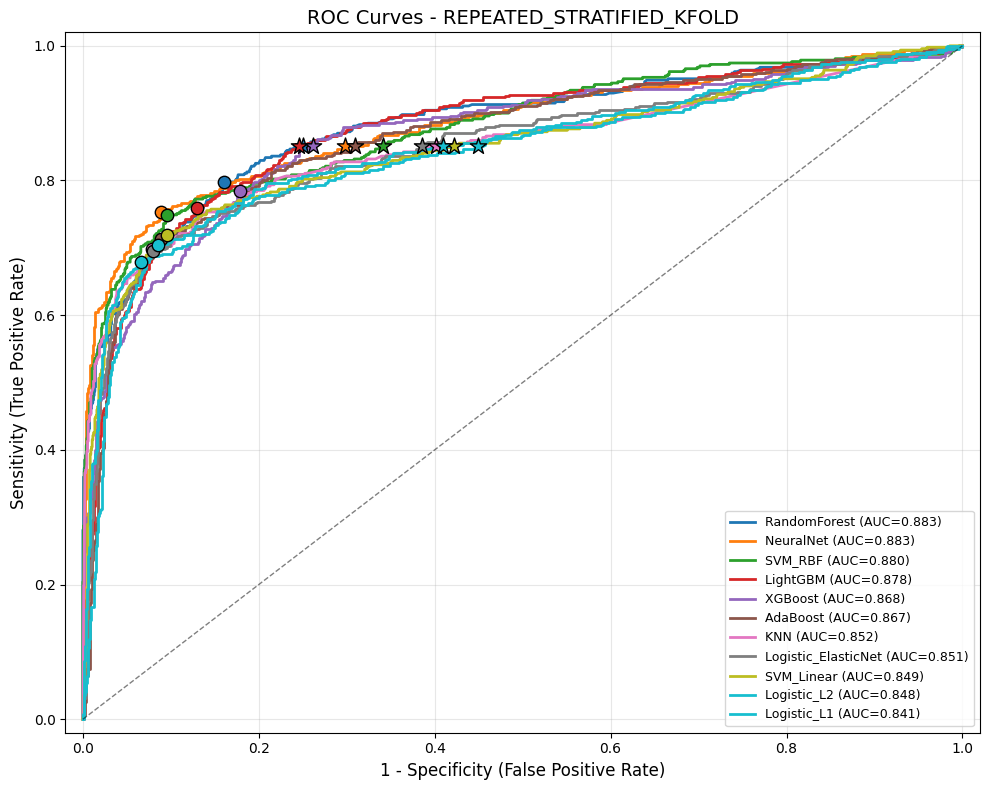


🧬 TOP FEATURES ACROSS MODELS (appearing in ≥80% of folds)
Feature                                    Models Selected In
--------------------------------------------------------------
AUC_R2_Chip2                                               11
AUC_R2_Chip4                                               11
NR_Chip2                                                   11
Chip8_coeff_2                                              11
NR_Chip3                                                   11
Chip1_Chip7_pearson                                        11
AUC_R2_Chip7                                               11
Chip1_Chip4_pearson                                        11
AUC_R2_Chip3                                               11
Grad_1_Chip7                                               11
Chip8_coeff_3                                              11
Grad_1_Chip4                                               11
Chip2_Chip6_pearson                                        11
Grad_1_Chi

In [23]:

results_rskf = classification_pipeline_v2(
    DF=feat_df,
    outer_cv_method="repeated_stratified_kfold",
    feature_selection_method="strict",
    fdr_alpha=0.1,
    n_repeats=10,
    n_splits=5
)

In [24]:
#very few parameters in the grid of each method (latest not on the deliverable yet)
def classification_pipeline_v3(DF, random_state=48, outer_cv_method="loocv", 
                                feature_selection_method="fdr", fdr_alpha=0.1,
                                n_repeats=10, n_splits=5):
    """
    Nested CV classification pipeline for binary classification (Control vs CRC).
    
    Parameters:
    -----------
    DF : pd.DataFrame
        Input dataframe with 'Subject', 'Group', and feature columns
    random_state : int
        Random seed for reproducibility
    outer_cv_method : str
        'loocv' or 'repeated_stratified_kfold'
    feature_selection_method : str
        'strict' (both tests p<0.05), 'or' (either test), 'fdr' (FDR corrected)
    fdr_alpha : float
        FDR threshold if using FDR correction
    n_repeats : int
        Number of repeats for repeated stratified k-fold
    n_splits : int
        Number of splits for repeated stratified k-fold
    
    Returns:
    --------
    dict with results_df, final_models, roc_data, feature_importance
    """
    import warnings
    warnings.filterwarnings("ignore")
    
    # Standard imports
    import numpy as np
    import pandas as pd
    from scipy import stats  # FIXED: was missing
    from collections import Counter
    
    from sklearn.model_selection import (
        LeaveOneOut, StratifiedKFold, RepeatedStratifiedKFold, 
        GridSearchCV, cross_val_predict
    )
    from sklearn.preprocessing import StandardScaler
    from sklearn.utils.class_weight import compute_sample_weight
    from sklearn.metrics import (
        roc_curve, roc_auc_score, confusion_matrix, 
        balanced_accuracy_score, accuracy_score
    )
    import matplotlib.pyplot as plt
    
    # Optional: FDR correction
    try:
        from statsmodels.stats.multitest import fdrcorrection
        HAS_STATSMODELS = True
    except ImportError:
        HAS_STATSMODELS = False
        if feature_selection_method == "fdr":
            print("⚠️ statsmodels not available, falling back to 'or' method")
            feature_selection_method = "or"
    
    # Models
    from lightgbm import LGBMClassifier
    from xgboost import XGBClassifier
    from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
    from sklearn.linear_model import LogisticRegression
    from sklearn.svm import SVC
    from sklearn.neighbors import KNeighborsClassifier
    from sklearn.neural_network import MLPClassifier

    # =========================================================================
    # HELPER FUNCTIONS
    # =========================================================================
    
    def select_features(X_train, y_train, method="fdr", alpha=0.1):
        """
        Univariate feature selection with multiple testing correction options.
        """
        p_ttest = []
        p_mann = []
        features = list(X_train.columns)
        
        for col in features:
            g0 = X_train[col][y_train == 0].dropna()
            g1 = X_train[col][y_train == 1].dropna()
            
            # Skip if insufficient data
            if len(g0) < 3 or len(g1) < 3:
                p_ttest.append(1.0)
                p_mann.append(1.0)
                continue
            
            try:
                _, p_t = stats.ttest_ind(g0, g1, equal_var=False)
                _, p_m = stats.mannwhitneyu(g0, g1, alternative="two-sided")
                p_ttest.append(p_t)
                p_mann.append(p_m)
            except Exception:
                p_ttest.append(1.0)
                p_mann.append(1.0)
        
        p_ttest = np.array(p_ttest)
        p_mann = np.array(p_mann)
        
        if method == "strict":
            # Both tests must be significant
            selected = (p_ttest < 0.05) & (p_mann < 0.05)
            print(selected.sum())
        elif method == "or":
            # Either test significant
            selected = (p_ttest < 0.05) | (p_mann < 0.05)
            print(selected.sum())
        elif method == "fdr" and HAS_STATSMODELS:
            # FDR correction on Mann-Whitney (non-parametric, more robust)
            rejected, _ = fdrcorrection(p_mann, alpha=alpha)
            selected = rejected
        else:
            selected = (p_ttest < 0.05) | (p_mann < 0.05)
        
        selected_features = [f for f, s in zip(features, selected) if s]
        return selected_features, {"p_ttest": p_ttest, "p_mann": p_mann}
    
    def compute_metrics_at_threshold(y_true, y_proba, threshold):
        """Compute confusion matrix metrics at a given threshold."""
        y_pred = (y_proba >= threshold).astype(int)
        
        if len(np.unique(y_pred)) < 2 or len(np.unique(y_true)) < 2:
            return {"sens": np.nan, "spec": np.nan, "bal_acc": np.nan}
        
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
        sens = tp / (tp + fn) if (tp + fn) > 0 else np.nan
        spec = tn / (tn + fp) if (tn + fp) > 0 else np.nan
        bal_acc = balanced_accuracy_score(y_true, y_pred)
        
        return {"sens": sens, "spec": spec, "bal_acc": bal_acc, 
                "tp": tp, "tn": tn, "fp": fp, "fn": fn}

    # =========================================================================
    # DATA PREPARATION
    # =========================================================================
    
    df = DF.copy()
    df = df[~df['Group'].isin(["TBD", "HC/R/NP", "HC/R/P"])].reset_index(drop=True)
    df['Group'] = df['Group'].replace({'HC/NR': 'Control', 'CRC': 'CRC'})
    
    X = df.drop(columns=['Subject', 'Group', 'index'], errors='ignore')
    feature_names = list(X.columns)
    y = df['Group'].map({'Control': 0, 'CRC': 1})
    
    print(f"📊 Dataset: {len(y)} samples ({(y==0).sum()} Control, {(y==1).sum()} CRC)")
    print(f"📊 Features: {len(feature_names)}")
    print(f"📊 Outer CV: {outer_cv_method}, Feature selection: {feature_selection_method}")

    # =========================================================================
    # MODEL SPECIFICATIONS
    # =========================================================================
    
    model_specs = {
        "LightGBM": {
            "estimator": LGBMClassifier(
                objective="binary",
                class_weight="balanced",
                random_state=random_state,
                verbose=-1,
                # FIXED conservative structure (no tuning)
                n_estimators=200,        # Moderate, let early stopping handle it
                num_leaves=15,           # Conservative (default=31 is too complex)
                max_depth=4,             # Shallow trees
                min_child_samples=20,    # High = more regularization
                feature_fraction=0.8,    # Implicit regularization
                bagging_fraction=0.8,
                bagging_freq=1
            ),
            "param_grid": {
                # ONLY tune regularization strength
                "reg_lambda": [0.1, 1.0, 10.0],  # L2 regularization
            },
            "uses_sample_weight": False
        },
        "XGBoost": {
            "estimator": XGBClassifier(
                objective="binary:logistic",
                eval_metric="logloss",
                use_label_encoder=False,
                random_state=random_state,
                verbosity=0,
                # FIXED conservative structure
                n_estimators=200,
                max_depth=3,             # Very shallow
                min_child_weight=5,      # High = more regularization
                subsample=0.8,
                colsample_bytree=0.8,
                scale_pos_weight=2.8     # For class imbalance (132/47 ≈ 2.8)
            ),
            "param_grid": {
                "reg_lambda": [0.1, 1.0, 10.0],  # L2 regularization
            },
            # Total combinations: 3
            "uses_sample_weight": False
        },
        "RandomForest": {
            "estimator": RandomForestClassifier(
                class_weight="balanced",
                random_state=random_state,
                n_estimators=300,        # More trees = more stable
                max_features="sqrt"      # Standard default
            ),
            "param_grid": {"max_depth": [7, 10], "min_samples_leaf": [5,10]},
            "uses_sample_weight": False
        },
        "Logistic_L1": {
            "estimator": LogisticRegression(
                penalty="l1", solver="saga", class_weight="balanced", max_iter=5000
            ),
            "param_grid": {"C": [0.01, 0.1, 1]},
            "uses_sample_weight": False
        },
        "Logistic_L2": {
            "estimator": LogisticRegression(
                penalty="l2", solver="lbfgs", class_weight="balanced", max_iter=5000
            ),
            "param_grid": {"C": [0.01, 0.1, 1]},
            "uses_sample_weight": False
        },
        "SVM_Linear": {
            "estimator": SVC(
                kernel="linear", probability=True, 
                class_weight="balanced", random_state=random_state
            ),
            "param_grid": {"C": [0.01, 0.1, 1]},
            "uses_sample_weight": False
        },
        "SVM_RBF": {
            "estimator": SVC(
                kernel="rbf", probability=True,
                class_weight="balanced", random_state=random_state
            ),
            "param_grid": {"C": [0.1, 1, 10], "gamma": ["scale"]},
            "uses_sample_weight": False
        },
        "Logistic_ElasticNet": {
            "estimator": LogisticRegression(
                penalty="elasticnet", solver="saga", 
                class_weight="balanced", max_iter=5000
            ),
            "param_grid": {
                "C": [0.1, 1, 10],
                "l1_ratio": [0.3, 0.5, 0.7]
            },
            "uses_sample_weight": False
        },
        "KNN": {
            "estimator": KNeighborsClassifier(),
            "param_grid": {"n_neighbors": [7, 11, 15], "weights": ["distance", "uniform"]},
            "uses_sample_weight": False
        },
        "AdaBoost": {
            "estimator": AdaBoostClassifier(estimator=None,random_state=random_state),
            "param_grid": {"n_estimators": [100, 200],"learning_rate": [0.01, 0.1]},
            "uses_sample_weight": True
        },
        "NeuralNet": {
            "estimator": MLPClassifier(
                max_iter=2000,
                random_state=random_state,
                hidden_layer_sizes=(20,),  # FIXED - single small layer
                activation="relu",
                early_stopping=False,       # Implicit regularization
                validation_fraction=0.15
            ),
            "param_grid": {
                "alpha": [0.1, 1.0, 10.0],  # L2 penalty - use HIGH values
            },
            # Total combinations: 3
            "uses_sample_weight": True
        }
    }

    # =========================================================================
    # SETUP OUTER CV
    # =========================================================================
    
    if outer_cv_method == "loocv":
        outer_cv = LeaveOneOut()
        n_outer_folds = len(y)
    else:
        outer_cv = RepeatedStratifiedKFold(
            n_splits=n_splits, n_repeats=n_repeats, random_state=random_state
        )
        n_outer_folds = n_splits * n_repeats

    # =========================================================================
    # MAIN NESTED CV LOOP
    # =========================================================================
    
    model_results = []
    roc_data = {}
    final_models = {}
    feature_tracker = {}  # Track feature selection across models
    
    for model_name, spec in model_specs.items():
        print(f"\n{'='*60}")
        print(f"🔹 {model_name}")
        print(f"{'='*60}")
        
        base_model = spec["estimator"]
        param_grid = spec["param_grid"]
        uses_sw = spec["uses_sample_weight"]
        
        y_true_all, y_proba_all, y_pred_all = [], [], []
        selected_features_per_fold = []
        fold_aucs = []
        
        for fold_idx, (train_idx, test_idx) in enumerate(outer_cv.split(X, y)):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
            
            # --- Feature Selection (inside fold) ---
            sel_feats, _ = select_features(
                X_train, y_train, 
                method=feature_selection_method, 
                alpha=fdr_alpha
            )
            
            # Fallback if no features selected
            if len(sel_feats) == 0:
                sel_feats = list(X_train.columns)
            
            selected_features_per_fold.append(set(sel_feats))
            
            X_train_fs = X_train[sel_feats]
            X_test_fs = X_test[sel_feats]
            
            # --- Scaling ---
            scaler = StandardScaler()
            X_train_sc = scaler.fit_transform(X_train_fs)
            X_test_sc = scaler.transform(X_test_fs)
            
            # --- Inner CV for hyperparameter tuning ---
            inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)
            
            grid = GridSearchCV(
                estimator=base_model, 
                param_grid=param_grid,
                scoring="roc_auc", 
                cv=inner_cv, 
                n_jobs=-1,
                error_score=0.5
            )
            
            # Fit with sample weights if needed
            fit_params = {}
            if uses_sw:
                fit_params["sample_weight"] = compute_sample_weight("balanced", y_train)
            
            try:
                grid.fit(X_train_sc, y_train, **fit_params)
                best_model = grid.best_estimator_
            except Exception as e:
                print(f"  ⚠️ Fold {fold_idx} failed: {e}")
                continue
            
            # --- Predict on held-out sample(s) ---
            try:
                proba = best_model.predict_proba(X_test_sc)[:, 1]
            except:
                try:
                    dec = best_model.decision_function(X_test_sc)
                    proba = 1 / (1 + np.exp(-dec))  # Sigmoid transform
                except:
                    proba = best_model.predict(X_test_sc).astype(float)
            
            pred = best_model.predict(X_test_sc)
            
            y_true_all.extend(y_test.values)
            y_proba_all.extend(proba)
            y_pred_all.extend(pred)
        
        # Convert to arrays
        y_true_all = np.array(y_true_all)
        y_proba_all = np.array(y_proba_all)
        y_pred_all = np.array(y_pred_all)
        
        if len(y_true_all) == 0:
            print(f"  ❌ No valid predictions for {model_name}")
            continue
        
        # --- Compute ROC metrics ---
        try:
            auc = roc_auc_score(y_true_all, y_proba_all)
            fpr, tpr, thresholds = roc_curve(y_true_all, y_proba_all)
        except Exception as e:
            print(f"  ❌ ROC computation failed: {e}")
            continue
        
        roc_data[model_name] = (y_true_all, y_proba_all, fpr, tpr, thresholds)
        
        # Youden's index
        youden = tpr - fpr
        best_idx = np.argmax(youden)
        thr_youden = thresholds[best_idx]
        metrics_youden = compute_metrics_at_threshold(y_true_all, y_proba_all, thr_youden)
        
        # Sens >= 85% threshold
        idx_85 = np.where(tpr >= 0.85)[0]
        if len(idx_85) > 0:
            thr_85 = thresholds[idx_85[0]]
            metrics_85 = compute_metrics_at_threshold(y_true_all, y_proba_all, thr_85)
        else:
            thr_85 = np.nan
            metrics_85 = {"sens": np.nan, "spec": np.nan, "bal_acc": np.nan}
        
        # Default threshold (0.5)
        metrics_default = compute_metrics_at_threshold(y_true_all, y_proba_all, 0.5)
        
        # --- Feature consistency analysis ---
        if len(selected_features_per_fold) > 0:
            all_feats = [f for s in selected_features_per_fold for f in s]
            feat_counts = Counter(all_feats)
            n_folds = len(selected_features_per_fold)
            
            # Features in ALL folds
            feats_all_folds = [f for f, c in feat_counts.items() if c == n_folds]
            # Features in >= 80% of folds
            feats_80pct = [f for f, c in feat_counts.items() if c >= 0.8 * n_folds]
            # Features in >= 50% of folds
            feats_50pct = [f for f, c in feat_counts.items() if c >= 0.5 * n_folds]
        else:
            feats_all_folds = feats_80pct = feats_50pct = []
            feat_counts = Counter()
        
        feature_tracker[model_name] = {
            "all_folds": feats_all_folds,
            "80pct": feats_80pct,
            "50pct": feats_50pct,
            "counts": feat_counts
        }
        
        # --- Store results ---
        model_results.append({
            "Model": model_name,
            "AUC": auc,
            # Youden threshold
            "Sens_Youden": metrics_youden["sens"],
            "Spec_Youden": metrics_youden["spec"],
            "BalAcc_Youden": metrics_youden["bal_acc"],
            "Thr_Youden": thr_youden,
            # Sens >= 85%
            "Sens_85": metrics_85["sens"],
            "Spec_85": metrics_85["spec"],
            "BalAcc_85": metrics_85["bal_acc"],
            "Thr_85": thr_85,
            # Default (0.5)
            "Sens_0.5": metrics_default["sens"],
            "Spec_0.5": metrics_default["spec"],
            # Feature info
            "N_Feats_AllFolds": len(feats_all_folds),
            "N_Feats_80pct": len(feats_80pct),
            "N_Feats_50pct": len(feats_50pct)
        })
        
        print(f"  ✅ AUC = {auc:.3f}")
        print(f"  📍 Youden: Sens={metrics_youden['sens']:.3f}, Spec={metrics_youden['spec']:.3f} @ thr={thr_youden:.3f}")
        print(f"  📍 Sens≥85%: Sens={metrics_85['sens']:.3f}, Spec={metrics_85['spec']:.3f} @ thr={thr_85:.3f}")
        print(f"  🧩 Features: {len(feats_all_folds)} in all folds, {len(feats_80pct)} in ≥80%")
        
        # =====================================================================
        # FINAL MODEL: Retrain on full data with proper feature selection
        # =====================================================================
        
        # Use features that appeared in >= 80% of folds (more stable than 100%)
        final_features = feats_80pct if len(feats_80pct) >= 3 else feats_50pct
        if len(final_features) < 3:
            final_features = list(X.columns)
            print(f"  ⚠️ Using all features for final model (insufficient stable features)")
        
        X_final = X[final_features]
        scaler_final = StandardScaler()
        X_final_sc = scaler_final.fit_transform(X_final)
        
        # Run final GridSearchCV on full data
        inner_cv_final = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)
        grid_final = GridSearchCV(
            estimator=base_model,
            param_grid=param_grid,
            scoring="roc_auc",
            cv=inner_cv_final,
            n_jobs=-1
        )
        
        fit_params_final = {}
        if uses_sw:
            fit_params_final["sample_weight"] = compute_sample_weight("balanced", y)
        
        try:
            grid_final.fit(X_final_sc, y, **fit_params_final)
            final_model = grid_final.best_estimator_
            final_params = grid_final.best_params_
            print(f"  🎯 Final params: {final_params}")
        except Exception as e:
            print(f"  ⚠️ Final model fitting failed: {e}")
            final_model = None
            final_params = {}
        
        final_models[model_name] = {
            "estimator": final_model,
            "features": final_features,
            "scaler": scaler_final,
            "params": final_params,
            "thresholds": {
                "youden": thr_youden,
                "sens_85": thr_85
            }
        }

    # =========================================================================
    # RESULTS SUMMARY
    # =========================================================================
    
    results_df = pd.DataFrame(model_results)
    results_df = results_df.sort_values("AUC", ascending=False).reset_index(drop=True)
    
    print("\n" + "="*80)
    print("📊 MODEL COMPARISON SUMMARY")
    print("="*80)
    display_cols = ["Model", "AUC", "Sens_Youden", "Spec_Youden", 
                    "Sens_85", "Spec_85", "N_Feats_80pct"]
    print(results_df[display_cols].to_string(index=False))

    # =========================================================================
    # ROC PLOT
    # =========================================================================
    
    fig, ax = plt.subplots(figsize=(10, 8))
    colors = plt.cm.tab10(np.linspace(0, 1, len(roc_data)))
    
    sorted_models = results_df["Model"].tolist()
    
    for color, model_name in zip(colors, sorted_models):
        if model_name not in roc_data:
            continue
        y_true, y_proba, fpr, tpr, thr = roc_data[model_name]
        auc = roc_auc_score(y_true, y_proba)
        
        ax.plot(fpr, tpr, color=color, lw=2, label=f"{model_name} (AUC={auc:.3f})")
        
        # Mark Youden point
        youden = tpr - fpr
        best_idx = np.argmax(youden)
        ax.scatter(fpr[best_idx], tpr[best_idx], color=color, marker='o', 
                   s=80, edgecolor='black', zorder=5)
        
        # Mark Sens >= 85% point
        idx_85 = np.where(tpr >= 0.85)[0]
        if len(idx_85) > 0:
            ax.scatter(fpr[idx_85[0]], tpr[idx_85[0]], color=color, marker='*',
                       s=150, edgecolor='black', zorder=5)
    
    ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
    ax.set_xlabel("1 - Specificity (False Positive Rate)", fontsize=12)
    ax.set_ylabel("Sensitivity (True Positive Rate)", fontsize=12)
    ax.set_title(f"ROC Curves - {outer_cv_method.upper()}", fontsize=14)
    ax.legend(loc="lower right", fontsize=9)
    ax.grid(alpha=0.3)
    ax.set_xlim([-0.02, 1.02])
    ax.set_ylim([-0.02, 1.02])
    
    plt.tight_layout()
    plt.savefig("roc_curves_v2.png", dpi=300, bbox_inches='tight')
    plt.show()

    # =========================================================================
    # FEATURE IMPORTANCE SUMMARY
    # =========================================================================
    
    print("\n" + "="*80)
    print("🧬 TOP FEATURES ACROSS MODELS (appearing in ≥80% of folds)")
    print("="*80)
    
    # Aggregate feature importance across models
    global_feat_counts = Counter()
    for model_name, tracker in feature_tracker.items():
        for feat in tracker["80pct"]:
            global_feat_counts[feat] += 1
    
    top_features = global_feat_counts.most_common(20)
    if top_features:
        print(f"{'Feature':<40} {'Models Selected In':>20}")
        print("-" * 62)
        for feat, count in top_features:
            print(f"{feat:<40} {count:>20}")
    
    return {
        "results_df": results_df,
        "final_models": final_models,
        "roc_data": roc_data,
        "feature_tracker": feature_tracker,
        "config": {
            "outer_cv": outer_cv_method,
            "feature_selection": feature_selection_method,
            "fdr_alpha": fdr_alpha
        }
    }


# =============================================================================
# USAGE EXAMPLE
# =============================================================================
"""
# Run with LOOCV (your original approach)
results_loocv = classification_pipeline_v2(
    DF=your_dataframe,
    outer_cv_method="loocv",
    feature_selection_method="fdr",
    fdr_alpha=0.1
)

# Run with Repeated Stratified K-Fold for comparison
results_rskf = classification_pipeline_v2(
    DF=your_dataframe,
    outer_cv_method="repeated_stratified_kfold",
    feature_selection_method="fdr",
    fdr_alpha=0.1,
    n_repeats=10,
    n_splits=5
)

# Compare results
print("LOOCV AUC:", results_loocv["results_df"][["Model", "AUC"]])
print("RSKF AUC:", results_rskf["results_df"][["Model", "AUC"]])
"""

'\n# Run with LOOCV (your original approach)\nresults_loocv = classification_pipeline_v2(\n    DF=your_dataframe,\n    outer_cv_method="loocv",\n    feature_selection_method="fdr",\n    fdr_alpha=0.1\n)\n\n# Run with Repeated Stratified K-Fold for comparison\nresults_rskf = classification_pipeline_v2(\n    DF=your_dataframe,\n    outer_cv_method="repeated_stratified_kfold",\n    feature_selection_method="fdr",\n    fdr_alpha=0.1,\n    n_repeats=10,\n    n_splits=5\n)\n\n# Compare results\nprint("LOOCV AUC:", results_loocv["results_df"][["Model", "AUC"]])\nprint("RSKF AUC:", results_rskf["results_df"][["Model", "AUC"]])\n'

📊 Dataset: 179 samples (132 Control, 47 CRC)
📊 Features: 164
📊 Outer CV: repeated_stratified_kfold, Feature selection: or

🔹 LightGBM
43
48
50
40
43
38
45
52
36
45
48
46
37
45
43
45
36
38
53
50
49
45
43
46
44
47
48
41
37
49
36
44
43
54
39
41
36
52
45
39
40
45
34
54
41
45
30
41
49
43
  ✅ AUC = 0.893
  📍 Youden: Sens=0.819, Spec=0.867 @ thr=0.239
  📍 Sens≥85%: Sens=0.851, Spec=0.812 @ thr=0.167
  🧩 Features: 23 in all folds, 32 in ≥80%
  🎯 Final params: {'reg_lambda': 1.0}

🔹 XGBoost
43
48
50
40
43
38
45
52
36
45
48
46
37
45
43
45
36
38
53
50
49
45
43
46
44
47
48
41
37
49
36
44
43
54
39
41
36
52
45
39
40
45
34
54
41
45
30
41
49
43
  ✅ AUC = 0.886
  📍 Youden: Sens=0.757, Spec=0.886 @ thr=0.420
  📍 Sens≥85%: Sens=0.851, Spec=0.777 @ thr=0.209
  🧩 Features: 23 in all folds, 32 in ≥80%
  🎯 Final params: {'reg_lambda': 0.1}

🔹 RandomForest
43
48
50
40
43
38
45
52
36
45
48
46
37
45
43
45
36
38
53
50
49
45
43
46
44
47
48
41
37
49
36
44
43
54
39
41
36
52
45
39
40
45
34
54
41
45
30
41
49
43
  ✅ A

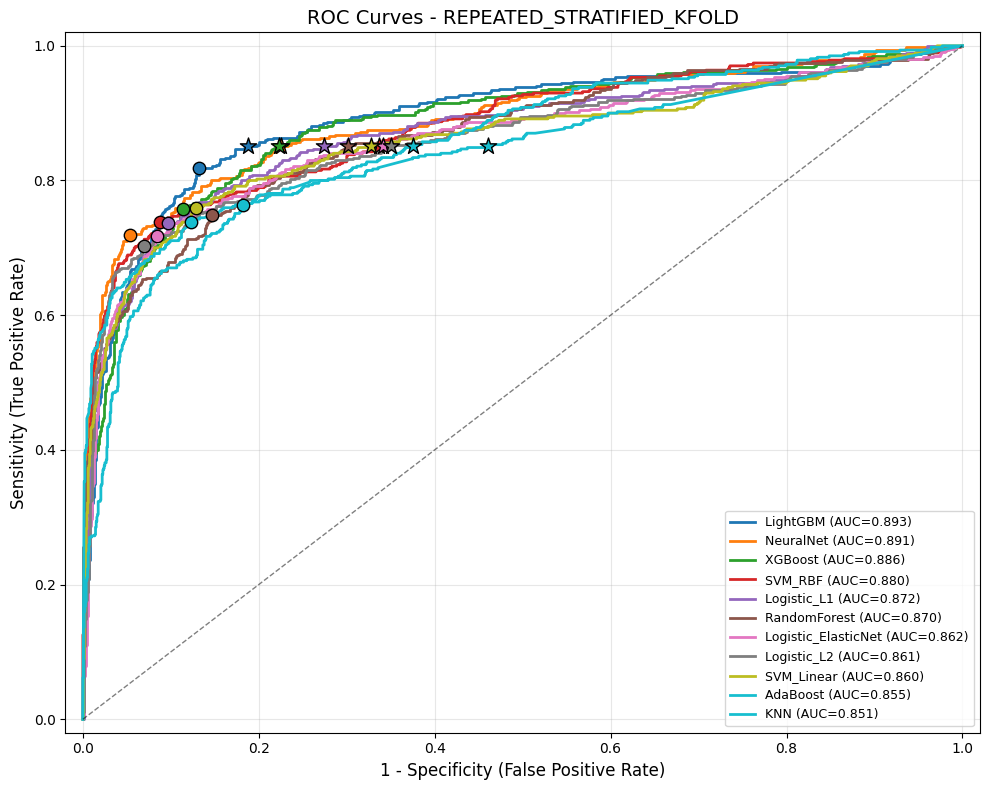


🧬 TOP FEATURES ACROSS MODELS (appearing in ≥80% of folds)
Feature                                    Models Selected In
--------------------------------------------------------------
AUC_R2_Chip2                                               11
AUC_R2_Chip4                                               11
NR_Chip2                                                   11
Chip8_coeff_2                                              11
NR_Chip3                                                   11
Decay_B50_Chip7                                            11
Chip1_Chip7_pearson                                        11
AUC_R2_Chip7                                               11
Chip1_Chip4_pearson                                        11
AUC_R2_Chip3                                               11
Grad_1_Chip7                                               11
Chip6_coeff_4                                              11
Grad_1_Chip4                                               11
Chip2_Chip

In [28]:

results_rskf = classification_pipeline_v3(
    DF=feat_df,
    outer_cv_method="repeated_stratified_kfold",
    feature_selection_method="or",
    fdr_alpha=0.1,
    n_repeats=10,
    n_splits=5
)

In [29]:
results_rskf["results_df"]

,Model,AUC,Sens_Youden,Spec_Youden,BalAcc_Youden,Thr_Youden,Sens_85,Spec_85,BalAcc_85,Thr_85,Sens_0.5,Spec_0.5,N_Feats_AllFolds,N_Feats_80pct,N_Feats_50pct
0,LightGBM,0.892645,0.819149,0.867424,0.843287,0.238835,0.851064,0.812121,0.831593,0.167052,0.712766,0.922727,23,32,38
1,NeuralNet,0.890982,0.719149,0.946970,0.833059,0.588490,0.851064,0.775000,0.813032,0.190026,0.734043,0.921212,23,32,38
2,XGBoost,0.885993,0.757447,0.885606,0.821526,0.419808,0.851064,0.777273,0.814168,0.209186,0.719149,0.903788,23,32,38
3,SVM_RBF,0.880015,0.738298,0.912121,0.825210,0.331755,0.851064,0.662879,0.756971,0.113807,0.668085,0.960606,23,32,38
4,Logistic_L1,0.872089,0.736170,0.903030,0.819600,0.570354,0.851064,0.725758,0.788411,0.227177,0.751064,0.878788,23,32,38
5,RandomForest,0.869549,0.748936,0.853030,0.800983,0.376931,0.851064,0.698485,0.774774,0.274559,0.608511,0.950000,23,32,38
6,Logistic_ElasticNet,0.862305,0.717021,0.915909,0.816465,0.585706,0.851064,0.658333,0.754699,0.220538,0.744681,0.879545,23,32,38
7,Logistic_L2,0.861109,0.702128,0.931061,0.816594,0.600995,0.851064,0.650000,0.750532,0.247979,0.738298,0.878788,23,32,38
8,SVM_Linear,0.859901,0.759574,0.871212,0.815393,0.329104,0.851064,0.672727,0.761896,0.156269,0.646809,0.944697,23,32,38
9,AdaBoost,0.855463,0.763830,0.817424,0.790627,0.500388,0.851064,0.624242,0.737653,0.445551,0.763830,0.814394,23,32,38


In [55]:
#very few parameters in the grid of each method (latest not on the deliverable yet)
def classification_pipeline_v3(DF, random_state=48, outer_cv_method="loocv",
                                feature_selection_method="fdr", fdr_alpha=0.1,
                                n_repeats=10, n_splits=5):
    """
    Nested CV classification pipeline for binary classification (Control vs CRC).

    Parameters:
    -----------
    DF : pd.DataFrame
        Input dataframe with 'Subject', 'Group', and feature columns
    random_state : int
        Random seed for reproducibility
    outer_cv_method : str
        'loocv' or 'repeated_stratified_kfold'
    feature_selection_method : str
        'strict' (both tests p<0.05), 'or' (either test), 'fdr' (FDR corrected)
    fdr_alpha : float
        FDR threshold if using FDR correction
    n_repeats : int
        Number of repeats for repeated stratified k-fold
    n_splits : int
        Number of splits for repeated stratified k-fold

    Returns:
    --------
    dict with results_df, final_models, roc_data, feature_importance
    """
    import warnings
    warnings.filterwarnings("ignore")

    # Standard imports
    import numpy as np
    import pandas as pd
    from scipy import stats
    from collections import Counter

    from sklearn.model_selection import (
        LeaveOneOut, StratifiedKFold, RepeatedStratifiedKFold,
        GridSearchCV, cross_val_predict
    )
    from sklearn.preprocessing import StandardScaler
    from sklearn.utils.class_weight import compute_sample_weight
    from sklearn.metrics import (
        roc_curve, roc_auc_score, confusion_matrix,
        balanced_accuracy_score, accuracy_score
    )

    # Optional: FDR correction
    try:
        from statsmodels.stats.multitest import fdrcorrection
        HAS_STATSMODELS = True
    except ImportError:
        HAS_STATSMODELS = False
        if feature_selection_method == "fdr":
            print("⚠️ statsmodels not available, falling back to 'or' method")
            feature_selection_method = "or"

    # Models
    from lightgbm import LGBMClassifier
    from xgboost import XGBClassifier
    from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
    from sklearn.linear_model import LogisticRegression
    from sklearn.svm import SVC
    from sklearn.neighbors import KNeighborsClassifier
    from sklearn.neural_network import MLPClassifier

    # =========================================================================
    # HELPER FUNCTIONS
    # =========================================================================

    def select_features(X_train, y_train, method="fdr", alpha=0.1):
        """
        Univariate feature selection with multiple testing correction options.
        """
        p_ttest = []
        p_mann = []
        features = list(X_train.columns)

        for col in features:
            g0 = X_train[col][y_train == 0].dropna()
            g1 = X_train[col][y_train == 1].dropna()

            # Skip if insufficient data
            if len(g0) < 3 or len(g1) < 3:
                p_ttest.append(1.0)
                p_mann.append(1.0)
                continue

            try:
                _, p_t = stats.ttest_ind(g0, g1, equal_var=False)
                _, p_m = stats.mannwhitneyu(g0, g1, alternative="two-sided")
                p_ttest.append(p_t)
                p_mann.append(p_m)
            except Exception:
                p_ttest.append(1.0)
                p_mann.append(1.0)

        p_ttest = np.array(p_ttest)
        p_mann = np.array(p_mann)

        if method == "strict":
            # Both tests must be significant
            selected = (p_ttest < 0.05) & (p_mann < 0.05)
            print(selected.sum())
        elif method == "or":
            # Either test significant
            selected = (p_ttest < 0.01) | (p_mann < 0.01)
            print(selected.sum())
        elif method == "fdr" and HAS_STATSMODELS:
            # FDR correction on Mann-Whitney (non-parametric, more robust)
            rejected, _ = fdrcorrection(p_mann, alpha=alpha)
            selected = rejected
        else:
            selected = (p_ttest < 0.05) | (p_mann < 0.05)

        selected_features = [f for f, s in zip(features, selected) if s]
        return selected_features, {"p_ttest": p_ttest, "p_mann": p_mann}

    def compute_metrics_at_threshold(y_true, y_proba, threshold):
        """Compute confusion matrix metrics at a given threshold."""
        y_pred = (y_proba >= threshold).astype(int)

        if len(np.unique(y_pred)) < 2 or len(np.unique(y_true)) < 2:
            return {"sens": np.nan, "spec": np.nan, "bal_acc": np.nan}

        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
        sens = tp / (tp + fn) if (tp + fn) > 0 else np.nan
        spec = tn / (tn + fp) if (tn + fp) > 0 else np.nan
        bal_acc = balanced_accuracy_score(y_true, y_pred)

        return {"sens": sens, "spec": spec, "bal_acc": bal_acc,
                "tp": tp, "tn": tn, "fp": fp, "fn": fn}

    # =========================================================================
    # DATA PREPARATION
    # =========================================================================

    df = DF.copy()
    df = df[~df['Group'].isin(["TBD", "HC/R/NP", "HC/R/P"])].reset_index(drop=True)
    df['Group'] = df['Group'].replace({'HC/NR': 'Control', 'CRC': 'CRC'})

    X = df.drop(columns=['Subject', 'Group', 'index'], errors='ignore')
    feature_names = list(X.columns)
    y = df['Group'].map({'Control': 0, 'CRC': 1})

    print(f"📊 Dataset: {len(y)} samples ({(y==0).sum()} Control, {(y==1).sum()} CRC)")
    print(f"📊 Features: {len(feature_names)}")
    print(f"📊 Outer CV: {outer_cv_method}, Feature selection: {feature_selection_method}")

    # =========================================================================
    # MODEL SPECIFICATIONS
    # =========================================================================

    model_specs = {
        "LightGBM": {
            "estimator": LGBMClassifier(
                objective="binary",
                class_weight="balanced",
                random_state=random_state,
                verbose=-1,
                n_estimators=200,
                num_leaves=15,
                max_depth=4,
                min_child_samples=20,
                feature_fraction=0.8,
                bagging_fraction=0.8,
                bagging_freq=1
            ),
            "param_grid": {
                "reg_lambda": [0.1, 1.0, 10.0],
            },
            "uses_sample_weight": False
        },
        "XGBoost": {
            "estimator": XGBClassifier(
                objective="binary:logistic",
                eval_metric="logloss",
                use_label_encoder=False,
                random_state=random_state,
                verbosity=0,
                n_estimators=200,
                max_depth=3,
                min_child_weight=5,
                subsample=0.8,
                colsample_bytree=0.8,
                scale_pos_weight=2.8
            ),
            "param_grid": {
                "reg_lambda": [0.1, 1.0, 10.0],
            },
            "uses_sample_weight": False
        },
        "RandomForest": {
            "estimator": RandomForestClassifier(
                class_weight="balanced",
                random_state=random_state,
                n_estimators=300,
                max_features="sqrt"
            ),
            "param_grid": {"max_depth": [7, 10], "min_samples_leaf": [5,10]},
            "uses_sample_weight": False
        },
        "Logistic_L1": {
            "estimator": LogisticRegression(
                penalty="l1", solver="saga", class_weight="balanced", max_iter=5000
            ),
            "param_grid": {"C": [0.01, 0.1, 1]},
            "uses_sample_weight": False
        },
        "Logistic_L2": {
            "estimator": LogisticRegression(
                penalty="l2", solver="lbfgs", class_weight="balanced", max_iter=5000
            ),
            "param_grid": {"C": [0.01, 0.1, 1]},
            "uses_sample_weight": False
        },
        "SVM_Linear": {
            "estimator": SVC(
                kernel="linear", probability=True,
                class_weight="balanced", random_state=random_state
            ),
            "param_grid": {"C": [0.01, 0.1, 1]},
            "uses_sample_weight": False
        },
        "SVM_RBF": {
            "estimator": SVC(
                kernel="rbf", probability=True,
                class_weight="balanced", random_state=random_state
            ),
            "param_grid": {"C": [0.1, 1, 10], "gamma": ["scale"]},
            "uses_sample_weight": False
        },
        "Logistic_ElasticNet": {
            "estimator": LogisticRegression(
                penalty="elasticnet", solver="saga",
                class_weight="balanced", max_iter=5000
            ),
            "param_grid": {
                "C": [0.1, 1, 10],
                "l1_ratio": [0.3, 0.5, 0.7]
            },
            "uses_sample_weight": False
        },
        "KNN": {
            "estimator": KNeighborsClassifier(),
            "param_grid": {"n_neighbors": [7, 11, 15], "weights": ["distance", "uniform"]},
            "uses_sample_weight": False
        },
        "AdaBoost": {
            "estimator": AdaBoostClassifier(estimator=None,random_state=random_state),
            "param_grid": {"n_estimators": [100, 200],"learning_rate": [0.01, 0.1]},
            "uses_sample_weight": True
        },
        "NeuralNet": {
            "estimator": MLPClassifier(
                max_iter=2000,
                random_state=random_state,
                hidden_layer_sizes=(20,),
                activation="relu",
                early_stopping=False,
                validation_fraction=0.15
            ),
            "param_grid": {
                "alpha": [0.1, 1.0, 10.0],
            },
            "uses_sample_weight": True
        }
    }

    # =========================================================================
    # SETUP OUTER CV
    # =========================================================================

    if outer_cv_method == "loocv":
        outer_cv = LeaveOneOut()
        n_outer_folds = len(y)
    else:
        outer_cv = RepeatedStratifiedKFold(
            n_splits=n_splits, n_repeats=n_repeats, random_state=random_state
        )
        n_outer_folds = n_splits * n_repeats

    # =========================================================================
    # MAIN NESTED CV LOOP
    # =========================================================================

    model_results = []
    roc_data = {}
    final_models = {}
    feature_tracker = {}

    for model_name, spec in model_specs.items():
        print(f"\n{'='*60}")
        print(f"🔹 {model_name}")
        print(f"{'='*60}")

        base_model = spec["estimator"]
        param_grid = spec["param_grid"]
        uses_sw = spec["uses_sample_weight"]

        y_true_all, y_proba_all, y_pred_all = [], [], []
        selected_features_per_fold = []
        fold_aucs = []

        for fold_idx, (train_idx, test_idx) in enumerate(outer_cv.split(X, y)):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

            # --- Feature Selection (inside fold) ---
            sel_feats, _ = select_features(
                X_train, y_train,
                method=feature_selection_method,
                alpha=fdr_alpha
            )

            # Fallback if no features selected
            if len(sel_feats) == 0:
                sel_feats = list(X_train.columns)

            selected_features_per_fold.append(set(sel_feats))

            X_train_fs = X_train[sel_feats]
            X_test_fs = X_test[sel_feats]

            # --- Scaling ---
            scaler = StandardScaler()
            X_train_sc = scaler.fit_transform(X_train_fs)
            X_test_sc = scaler.transform(X_test_fs)

            # --- Inner CV for hyperparameter tuning ---
            inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)

            grid = GridSearchCV(
                estimator=base_model,
                param_grid=param_grid,
                scoring="roc_auc",
                cv=inner_cv,
                n_jobs=-1,
                error_score=0.5
            )

            # Fit with sample weights if needed
            fit_params = {}
            if uses_sw:
                fit_params["sample_weight"] = compute_sample_weight("balanced", y_train)

            try:
                grid.fit(X_train_sc, y_train, **fit_params)
                best_model = grid.best_estimator_
            except Exception as e:
                print(f"  ⚠️ Fold {fold_idx} failed: {e}")
                continue

            # --- Predict on held-out sample(s) ---
            try:
                proba = best_model.predict_proba(X_test_sc)[:, 1]
            except:
                try:
                    dec = best_model.decision_function(X_test_sc)
                    proba = 1 / (1 + np.exp(-dec))
                except:
                    proba = best_model.predict(X_test_sc).astype(float)

            pred = best_model.predict(X_test_sc)

            y_true_all.extend(y_test.values)
            y_proba_all.extend(proba)
            y_pred_all.extend(pred)

        # Convert to arrays
        y_true_all = np.array(y_true_all)
        y_proba_all = np.array(y_proba_all)
        y_pred_all = np.array(y_pred_all)

        if len(y_true_all) == 0:
            print(f"  ❌ No valid predictions for {model_name}")
            continue

        # --- Compute ROC metrics ---
        try:
            auc = roc_auc_score(y_true_all, y_proba_all)
            fpr, tpr, thresholds = roc_curve(y_true_all, y_proba_all)
        except Exception as e:
            print(f"  ❌ ROC computation failed: {e}")
            continue

        roc_data[model_name] = (y_true_all, y_proba_all, fpr, tpr, thresholds)

        # Youden's index - ONLY threshold method
        youden = tpr - fpr
        best_idx = np.argmax(youden)
        thr_youden = thresholds[best_idx]
        metrics_youden = compute_metrics_at_threshold(y_true_all, y_proba_all, thr_youden)

        # --- Feature consistency analysis ---
        if len(selected_features_per_fold) > 0:
            all_feats = [f for s in selected_features_per_fold for f in s]
            feat_counts = Counter(all_feats)
            n_folds = len(selected_features_per_fold)

            # Features in ALL folds
            feats_all_folds = [f for f, c in feat_counts.items() if c == n_folds]
            # Features in >= 80% of folds
            feats_80pct = [f for f, c in feat_counts.items() if c >= 0.8 * n_folds]
            # Features in >= 50% of folds
            feats_50pct = [f for f, c in feat_counts.items() if c >= 0.5 * n_folds]
        else:
            feats_all_folds = feats_80pct = feats_50pct = []
            feat_counts = Counter()

        feature_tracker[model_name] = {
            "all_folds": feats_all_folds,
            "80pct": feats_80pct,
            "50pct": feats_50pct,
            "counts": feat_counts
        }

        # --- Store results ---
        model_results.append({
            "Model": model_name,
            "AUC": auc,
            # Youden threshold - now with balanced accuracy
            "Sens_Youden": metrics_youden["sens"],
            "Spec_Youden": metrics_youden["spec"],
            "BalAcc_Youden": metrics_youden["bal_acc"],
            "Thr_Youden": thr_youden,
            # Feature info
            "N_Feats_AllFolds": len(feats_all_folds),
            "N_Feats_80pct": len(feats_80pct),
            "N_Feats_50pct": len(feats_50pct)
        })

        print(f"  ✅ AUC = {auc:.3f}")
        print(f"  📍 Youden: Sens={metrics_youden['sens']:.3f}, Spec={metrics_youden['spec']:.3f}, BalAcc={metrics_youden['bal_acc']:.3f} @ thr={thr_youden:.3f}")
        print(f"  🧩 Features: {len(feats_all_folds)} in all folds, {len(feats_80pct)} in ≥80%")

        # =====================================================================
        # FINAL MODEL: Retrain on full data with proper feature selection
        # =====================================================================

        # Use features that appeared in >= 80% of folds
        final_features = feats_80pct if len(feats_80pct) >= 3 else feats_50pct
        if len(final_features) < 3:
            final_features = list(X.columns)
            print(f"  ⚠️ Using all features for final model (insufficient stable features)")

        X_final = X[final_features]
        scaler_final = StandardScaler()
        X_final_sc = scaler_final.fit_transform(X_final)

        # Run final GridSearchCV on full data
        inner_cv_final = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)
        grid_final = GridSearchCV(
            estimator=base_model,
            param_grid=param_grid,
            scoring="roc_auc",
            cv=inner_cv_final,
            n_jobs=-1
        )

        fit_params_final = {}
        if uses_sw:
            fit_params_final["sample_weight"] = compute_sample_weight("balanced", y)

        try:
            grid_final.fit(X_final_sc, y, **fit_params_final)
            final_model = grid_final.best_estimator_
            final_params = grid_final.best_params_
            print(f"  🎯 Final params: {final_params}")
        except Exception as e:
            print(f"  ⚠️ Final model fitting failed: {e}")
            final_model = None
            final_params = {}

        final_models[model_name] = {
            "estimator": final_model,
            "features": final_features,
            "scaler": scaler_final,
            "params": final_params,
            "thresholds": {
                "youden": thr_youden
            }
        }

    # =========================================================================
    # RESULTS SUMMARY
    # =========================================================================

    results_df = pd.DataFrame(model_results)
    results_df = results_df.sort_values("AUC", ascending=False).reset_index(drop=True)

    print("\n" + "="*80)
    print("📊 MODEL COMPARISON SUMMARY")
    print("="*80)
    display_cols = ["Model", "AUC", "Sens_Youden", "Spec_Youden",
                    "BalAcc_Youden", "N_Feats_80pct"]
    print(results_df[display_cols].to_string(index=False))

    # =========================================================================
    # FEATURE IMPORTANCE SUMMARY
    # =========================================================================

    print("\n" + "="*80)
    print("🧬 TOP FEATURES ACROSS MODELS (appearing in ≥80% of folds)")
    print("="*80)

    # Aggregate feature importance across models
    global_feat_counts = Counter()
    for model_name, tracker in feature_tracker.items():
        for feat in tracker["80pct"]:
            global_feat_counts[feat] += 1

    top_features = global_feat_counts.most_common(20)
    if top_features:
        print(f"{'Feature':<40} {'Models Selected In':>20}")
        print("-" * 62)
        for feat, count in top_features:
            print(f"{feat:<40} {count:>20}")

    return {
        "results_df": results_df,
        "final_models": final_models,
        "roc_data": roc_data,
        "feature_tracker": feature_tracker,
        "config": {
            "outer_cv": outer_cv_method,
            "feature_selection": feature_selection_method,
            "fdr_alpha": fdr_alpha
        }
    }


def plot_roc_curves(roc_data, results_df, title="ROC Curves",
                    figsize=(10, 8), save_path="roc_curves.png", dpi=300):
    """
    Create ROC curve plot from classification pipeline results.

    Parameters:
    -----------
    roc_data : dict
        Dictionary with model_name -> (y_true, y_proba, fpr, tpr, thresholds)
    results_df : pd.DataFrame
        Results dataframe with Model names and AUC values
    title : str
        Plot title
    figsize : tuple
        Figure size (width, height)
    save_path : str
        Path to save figure (None to skip saving)
    dpi : int
        DPI for saved figure

    Returns:
    --------
    fig, ax : matplotlib figure and axis objects
    """
    import numpy as np
    import matplotlib.pyplot as plt
    from sklearn.metrics import roc_auc_score

    fig, ax = plt.subplots(figsize=figsize)
    colors = plt.cm.tab10(np.linspace(0, 1, len(roc_data)))

    # Sort models by AUC (descending)
    sorted_models = results_df["Model"].tolist()

    for color, model_name in zip(colors, sorted_models):
        if model_name not in roc_data:
            continue
        y_true, y_proba, fpr, tpr, thr = roc_data[model_name]
        auc = roc_auc_score(y_true, y_proba)

        ax.plot(fpr, tpr, color=color, lw=2, label=f"{model_name} (AUC={auc:.3f})")

        # Mark Youden point
        youden = tpr - fpr
        best_idx = np.argmax(youden)
        ax.scatter(fpr[best_idx], tpr[best_idx], color=color, marker='o',
                   s=40, edgecolor='black', zorder=4)

    # Diagonal reference line
    ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
    ax.set_xlabel("1 - Specificity (False Positive Rate)", fontsize=12)
    ax.set_ylabel("Sensitivity (True Positive Rate)", fontsize=12)
    ax.set_title(title, fontsize=14)
    ax.legend(loc="lower right", fontsize=9)
    ax.grid(alpha=0.3)
    ax.set_xlim([-0.02, 1.02])
    ax.set_ylim([-0.02, 1.02])

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=dpi, bbox_inches='tight')
        print(f"📊 ROC plot saved to: {save_path}")

    plt.show()

    return fig, ax


# =============================================================================
# USAGE EXAMPLE
# =============================================================================
"""
# Run the classification pipeline
results = classification_pipeline_v3(
    DF=your_dataframe,
    outer_cv_method="loocv",
    feature_selection_method="fdr",
    fdr_alpha=0.1
)

# Plot ROC curves separately (can experiment with plot settings)
fig, ax = plot_roc_curves(
    roc_data=results["roc_data"],
    results_df=results["results_df"],
    title="ROC Curves - LOOCV",
    figsize=(12, 10),
    save_path="my_custom_roc.png",
    dpi=300
)

# Customize the plot further if needed
ax.set_title("Custom Title", fontsize=16)
plt.show()
"""

'\n# Run the classification pipeline\nresults = classification_pipeline_v3(\n    DF=your_dataframe,\n    outer_cv_method="loocv",\n    feature_selection_method="fdr",\n    fdr_alpha=0.1\n)\n\n# Plot ROC curves separately (can experiment with plot settings)\nfig, ax = plot_roc_curves(\n    roc_data=results["roc_data"],\n    results_df=results["results_df"],\n    title="ROC Curves - LOOCV",\n    figsize=(12, 10),\n    save_path="my_custom_roc.png",\n    dpi=300\n)\n\n# Customize the plot further if needed\nax.set_title("Custom Title", fontsize=16)\nplt.show()\n'

In [32]:
results = classification_pipeline_v3(
    DF=feat_df,
    outer_cv_method="repeated_stratified_kfold",
    feature_selection_method="or",
    fdr_alpha=0.1,
    n_repeats=10,
    n_splits=5
)

📊 Dataset: 179 samples (132 Control, 47 CRC)
📊 Features: 164
📊 Outer CV: repeated_stratified_kfold, Feature selection: or

🔹 LightGBM
43
48
50
40
43
38
45
52
36
45
48
46
37
45
43
45
36
38
53
50
49
45
43
46
44
47
48
41
37
49
36
44
43
54
39
41
36
52
45
39
40
45
34
54
41
45
30
41
49
43
  ✅ AUC = 0.893
  📍 Youden: Sens=0.819, Spec=0.867, BalAcc=0.843 @ thr=0.239
  🧩 Features: 23 in all folds, 32 in ≥80%
  🎯 Final params: {'reg_lambda': 1.0}

🔹 XGBoost
43
48
50
40
43
38
45
52
36
45
48
46
37
45
43
45
36
38
53
50
49
45
43
46
44
47
48
41
37
49
36
44
43
54
39
41
36
52
45
39
40
45
34
54
41
45
30
41
49
43
  ✅ AUC = 0.886
  📍 Youden: Sens=0.757, Spec=0.886, BalAcc=0.822 @ thr=0.420
  🧩 Features: 23 in all folds, 32 in ≥80%
  🎯 Final params: {'reg_lambda': 0.1}

🔹 RandomForest
43
48
50
40
43
38
45
52
36
45
48
46
37
45
43
45
36
38
53
50
49
45
43
46
44
47
48
41
37
49
36
44
43
54
39
41
36
52
45
39
40
45
34
54
41
45
30
41
49
43
  ✅ AUC = 0.870
  📍 Youden: Sens=0.749, Spec=0.853, BalAcc=0.801 @ thr=0.37

In [42]:
results['']

{'results_df':                   Model       AUC  Sens_Youden  Spec_Youden  BalAcc_Youden  \
 0              LightGBM  0.892645     0.819149     0.867424       0.843287   
 1             NeuralNet  0.890982     0.719149     0.946970       0.833059   
 2               XGBoost  0.885993     0.757447     0.885606       0.821526   
 3               SVM_RBF  0.880015     0.738298     0.912121       0.825210   
 4           Logistic_L1  0.872079     0.736170     0.903030       0.819600   
 5          RandomForest  0.869549     0.748936     0.853030       0.800983   
 6   Logistic_ElasticNet  0.862307     0.717021     0.915909       0.816465   
 7           Logistic_L2  0.861109     0.702128     0.931061       0.816594   
 8            SVM_Linear  0.859901     0.759574     0.871212       0.815393   
 9              AdaBoost  0.855463     0.763830     0.817424       0.790627   
 10                  KNN  0.850635     0.738298     0.877273       0.807785   
 
     Thr_Youden  N_Feats_AllFolds  N

📊 ROC plot saved to: my_custom_roc.png


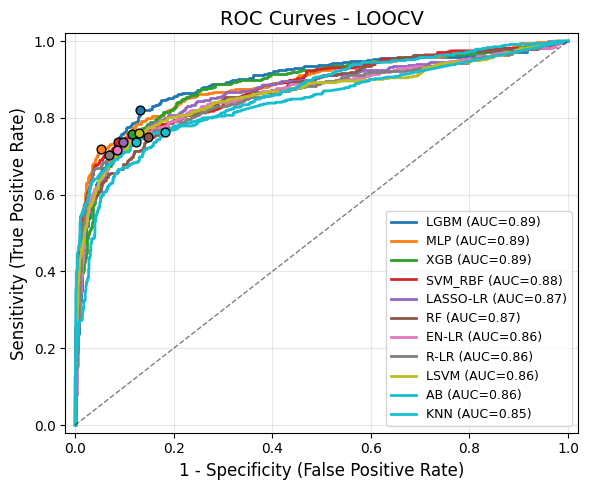

In [31]:
fig, ax = plot_roc_curves(
    roc_data=results["roc_data"],
    results_df=results["results_df"],
    title="ROC Curves - LOOCV",
    figsize=(6, 5),
    save_path="my_custom_roc.png",
    dpi=300
)

In [12]:
#very few parameters in the grid of each method (latest not on the deliverable yet)
#results for repeated cross validation with mean +- SD and roc auc curve pooled data.

def classification_pipeline_v4(DF, random_state=48, outer_cv_method="loocv",
                                feature_selection_method="fdr", fdr_alpha=0.1,
                                n_repeats=10, n_splits=5):
    """
    Nested CV classification pipeline for binary classification (Control vs CRC).

    Parameters:
    -----------
    DF : pd.DataFrame
        Input dataframe with 'Subject', 'Group', and feature columns
    random_state : int
        Random seed for reproducibility
    outer_cv_method : str
        'loocv' or 'repeated_stratified_kfold'
    feature_selection_method : str
        'strict' (both tests p<0.05), 'or' (either test), 'fdr' (FDR corrected)
    fdr_alpha : float
        FDR threshold if using FDR correction
    n_repeats : int
        Number of repeats for repeated stratified k-fold
    n_splits : int
        Number of splits for repeated stratified k-fold

    Returns:
    --------
    dict with results_df, final_models, roc_data, feature_importance
    """
    import warnings
    warnings.filterwarnings("ignore")

    # Standard imports
    import numpy as np
    import pandas as pd
    from scipy import stats
    from collections import Counter

    from sklearn.model_selection import (
        LeaveOneOut, StratifiedKFold, RepeatedStratifiedKFold,
        GridSearchCV, cross_val_predict
    )
    from sklearn.preprocessing import StandardScaler
    from sklearn.utils.class_weight import compute_sample_weight
    from sklearn.metrics import (
        roc_curve, roc_auc_score, confusion_matrix,
        balanced_accuracy_score, accuracy_score
    )

    # Optional: FDR correction
    try:
        from statsmodels.stats.multitest import fdrcorrection
        HAS_STATSMODELS = True
    except ImportError:
        HAS_STATSMODELS = False
        if feature_selection_method == "fdr":
            print("⚠️ statsmodels not available, falling back to 'or' method")
            feature_selection_method = "or"

    # Models
    from lightgbm import LGBMClassifier
    from xgboost import XGBClassifier
    from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
    from sklearn.linear_model import LogisticRegression
    from sklearn.svm import SVC
    from sklearn.neighbors import KNeighborsClassifier
    from sklearn.neural_network import MLPClassifier

    # =========================================================================
    # HELPER FUNCTIONS
    # =========================================================================

    def select_features(X_train, y_train, method="fdr", alpha=0.1):
        """
        Univariate feature selection with multiple testing correction options.
        """
        p_ttest = []
        p_mann = []
        features = list(X_train.columns)

        for col in features:
            g0 = X_train[col][y_train == 0].dropna()
            g1 = X_train[col][y_train == 1].dropna()

            # Skip if insufficient data
            if len(g0) < 3 or len(g1) < 3:
                p_ttest.append(1.0)
                p_mann.append(1.0)
                continue

            try:
                _, p_t = stats.ttest_ind(g0, g1, equal_var=False)
                _, p_m = stats.mannwhitneyu(g0, g1, alternative="two-sided")
                p_ttest.append(p_t)
                p_mann.append(p_m)
            except Exception:
                p_ttest.append(1.0)
                p_mann.append(1.0)

        p_ttest = np.array(p_ttest)
        p_mann = np.array(p_mann)

        if method == "strict":
            # Both tests must be significant
            selected = (p_ttest < 0.05) & (p_mann < 0.05)
            print(selected.sum())
        elif method == "or":
            # Either test significant
            selected = (p_ttest < 0.01) | (p_mann < 0.01)
            print(selected.sum())
        elif method == "fdr" and HAS_STATSMODELS:
            # FDR correction on Mann-Whitney (non-parametric, more robust)
            rejected, _ = fdrcorrection(p_mann, alpha=alpha)
            selected = rejected
        else:
            selected = (p_ttest < 0.05) | (p_mann < 0.05)

        selected_features = [f for f, s in zip(features, selected) if s]
        return selected_features, {"p_ttest": p_ttest, "p_mann": p_mann}

    def compute_metrics_at_threshold(y_true, y_proba, threshold):
        """Compute confusion matrix metrics at a given threshold."""
        y_pred = (y_proba >= threshold).astype(int)

        if len(np.unique(y_pred)) < 2 or len(np.unique(y_true)) < 2:
            return {"sens": np.nan, "spec": np.nan, "bal_acc": np.nan}

        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
        sens = tp / (tp + fn) if (tp + fn) > 0 else np.nan
        spec = tn / (tn + fp) if (tn + fp) > 0 else np.nan
        bal_acc = balanced_accuracy_score(y_true, y_pred)

        return {"sens": sens, "spec": spec, "bal_acc": bal_acc,
                "tp": tp, "tn": tn, "fp": fp, "fn": fn}

    # =========================================================================
    # DATA PREPARATION
    # =========================================================================

    df = DF.copy()
    df = df[~df['Group'].isin(["TBD", "HC/R/NP", "HC/R/P"])].reset_index(drop=True)
    df['Group'] = df['Group'].replace({'HC/NR': 'Control', 'CRC': 'CRC'})

    X = df.drop(columns=['Subject', 'Group', 'index'], errors='ignore')
    feature_names = list(X.columns)
    y = df['Group'].map({'Control': 0, 'CRC': 1})

    print(f"📊 Dataset: {len(y)} samples ({(y==0).sum()} Control, {(y==1).sum()} CRC)")
    print(f"📊 Features: {len(feature_names)}")
    print(f"📊 Outer CV: {outer_cv_method}, Feature selection: {feature_selection_method}")

    # =========================================================================
    # MODEL SPECIFICATIONS
    # =========================================================================

    model_specs = {
        "LGBM": {
            "estimator": LGBMClassifier(
                objective="binary",
                class_weight="balanced",
                random_state=random_state,
                verbose=-1,
                n_estimators=200,
                num_leaves=15,
                max_depth=4,
                min_child_samples=20,
                feature_fraction=0.8,
                bagging_fraction=0.8,
                bagging_freq=1
            ),
            "param_grid": {
                "reg_lambda": [0.1, 1.0, 10.0],
            },
            "uses_sample_weight": False
        },
        "XGB": {
            "estimator": XGBClassifier(
                objective="binary:logistic",
                eval_metric="logloss",
                use_label_encoder=False,
                random_state=random_state,
                verbosity=0,
                n_estimators=200,
                max_depth=3,
                min_child_weight=5,
                subsample=0.8,
                colsample_bytree=0.8,
                scale_pos_weight=2.8
            ),
            "param_grid": {
                "reg_lambda": [0.1, 1.0, 10.0],
            },
            "uses_sample_weight": False
        },
        "RF": {
            "estimator": RandomForestClassifier(
                class_weight="balanced",
                random_state=random_state,
                n_estimators=300,
                max_features="sqrt"
            ),
            "param_grid": {"max_depth": [7, 10], "min_samples_leaf": [5,10]},
            "uses_sample_weight": False
        },
        "LASSO-LR": {
            "estimator": LogisticRegression(
                penalty="l1", solver="saga", class_weight="balanced", max_iter=5000
            ),
            "param_grid": {"C": [0.01, 0.1, 1]},
            "uses_sample_weight": False
        },
        "R-LR": {
            "estimator": LogisticRegression(
                penalty="l2", solver="lbfgs", class_weight="balanced", max_iter=5000
            ),
            "param_grid": {"C": [0.01, 0.1, 1]},
            "uses_sample_weight": False
        },
        "LSVM": {
            "estimator": SVC(
                kernel="linear", probability=True,
                class_weight="balanced", random_state=random_state
            ),
            "param_grid": {"C": [0.01, 0.1, 1]},
            "uses_sample_weight": False
        },
        "SVM_RBF": {
            "estimator": SVC(
                kernel="rbf", probability=True,
                class_weight="balanced", random_state=random_state
            ),
            "param_grid": {"C": [0.1, 1, 10], "gamma": ["scale"]},
            "uses_sample_weight": False
        },
        "EN-LR": {
            "estimator": LogisticRegression(
                penalty="elasticnet", solver="saga",
                class_weight="balanced", max_iter=5000
            ),
            "param_grid": {
                "C": [0.1, 1, 10],
                "l1_ratio": [0.3, 0.5, 0.7]
            },
            "uses_sample_weight": False
        },
        "KNN": {
            "estimator": KNeighborsClassifier(),
            "param_grid": {"n_neighbors": [7, 11, 15], "weights": ["distance", "uniform"]},
            "uses_sample_weight": False
        },
        "AB": {
            "estimator": AdaBoostClassifier(estimator=None,random_state=random_state),
            "param_grid": {"n_estimators": [100, 200],"learning_rate": [0.01, 0.1]},
            "uses_sample_weight": True
        },
        "MLP": {
            "estimator": MLPClassifier(
                max_iter=2000,
                random_state=random_state,
                hidden_layer_sizes=(20,),
                activation="relu",
                early_stopping=False,
                validation_fraction=0.15
            ),
            "param_grid": {
                "alpha": [0.1, 1.0, 10.0],
            },
            "uses_sample_weight": True
        }
    }

    # =========================================================================
    # SETUP OUTER CV
    # =========================================================================

    if outer_cv_method == "loocv":
        outer_cv = LeaveOneOut()
        n_outer_folds = len(y)
    else:
        outer_cv = RepeatedStratifiedKFold(
            n_splits=n_splits, n_repeats=n_repeats, random_state=random_state
        )
        n_outer_folds = n_splits * n_repeats

    # =========================================================================
    # MAIN NESTED CV LOOP
    # =========================================================================

    model_results = []
    roc_data = {}
    final_models = {}
    feature_tracker = {}
    repeat_level_results = {}  # NEW: Store per-repeat metrics

    for model_name, spec in model_specs.items():
        print(f"\n{'='*60}")
        print(f"🔹 {model_name}")
        print(f"{'='*60}")

        base_model = spec["estimator"]
        param_grid = spec["param_grid"]
        uses_sw = spec["uses_sample_weight"]

        y_true_all, y_proba_all, y_pred_all = [], [], []
        selected_features_per_fold = []
        fold_aucs = []

        # For repeated k-fold: track metrics per repeat
        if outer_cv_method == "repeated_stratified_kfold":
            repeat_predictions = {i: {'y_true': [], 'y_proba': []} for i in range(n_repeats)}

        fold_counter = 0
        for fold_idx, (train_idx, test_idx) in enumerate(outer_cv.split(X, y)):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

            # --- Feature Selection (inside fold) ---
            sel_feats, _ = select_features(
                X_train, y_train,
                method=feature_selection_method,
                alpha=fdr_alpha
            )

            # Fallback if no features selected
            if len(sel_feats) == 0:
                sel_feats = list(X_train.columns)

            selected_features_per_fold.append(set(sel_feats))

            X_train_fs = X_train[sel_feats]
            X_test_fs = X_test[sel_feats]

            # --- Scaling ---
            scaler = StandardScaler()
            X_train_sc = scaler.fit_transform(X_train_fs)
            X_test_sc = scaler.transform(X_test_fs)

            # --- Inner CV for hyperparameter tuning ---
            inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)

            grid = GridSearchCV(
                estimator=base_model,
                param_grid=param_grid,
                scoring="roc_auc",
                cv=inner_cv,
                n_jobs=-1,
                error_score=0.5
            )

            # Fit with sample weights if needed
            fit_params = {}
            if uses_sw:
                fit_params["sample_weight"] = compute_sample_weight("balanced", y_train)

            try:
                grid.fit(X_train_sc, y_train, **fit_params)
                best_model = grid.best_estimator_
            except Exception as e:
                print(f"  ⚠️ Fold {fold_idx} failed: {e}")
                continue

            # --- Predict on held-out sample(s) ---
            try:
                proba = best_model.predict_proba(X_test_sc)[:, 1]
            except:
                try:
                    dec = best_model.decision_function(X_test_sc)
                    proba = 1 / (1 + np.exp(-dec))
                except:
                    proba = best_model.predict(X_test_sc).astype(float)

            pred = best_model.predict(X_test_sc)

            y_true_all.extend(y_test.values)
            y_proba_all.extend(proba)
            y_pred_all.extend(pred)

            # For repeated k-fold: also store in per-repeat structure
            if outer_cv_method == "repeated_stratified_kfold":
                repeat_idx = fold_counter // n_splits
                repeat_predictions[repeat_idx]['y_true'].extend(y_test.values)
                repeat_predictions[repeat_idx]['y_proba'].extend(proba)

            fold_counter += 1

        # Convert to arrays
        y_true_all = np.array(y_true_all)
        y_proba_all = np.array(y_proba_all)
        y_pred_all = np.array(y_pred_all)

        if len(y_true_all) == 0:
            print(f"  ❌ No valid predictions for {model_name}")
            continue

        # =====================================================================
        # COMPUTE METRICS: Different approach for LOOCV vs Repeated K-Fold
        # =====================================================================

        if outer_cv_method == "loocv":
            # LOOCV: Single AUC, single threshold
            try:
                auc = roc_auc_score(y_true_all, y_proba_all)
                fpr, tpr, thresholds = roc_curve(y_true_all, y_proba_all)
            except Exception as e:
                print(f"  ❌ ROC computation failed: {e}")
                continue

            # Store for ROC plotting
            roc_data[model_name] = (y_true_all, y_proba_all, fpr, tpr, thresholds)

            # Youden's index
            youden = tpr - fpr
            best_idx = np.argmax(youden)
            thr_youden = thresholds[best_idx]
            metrics_youden = compute_metrics_at_threshold(y_true_all, y_proba_all, thr_youden)

            # Single values (no SD)
            auc_mean, auc_std = auc, 0.0
            sens_mean, sens_std = metrics_youden["sens"], 0.0
            spec_mean, spec_std = metrics_youden["spec"], 0.0
            balacc_mean, balacc_std = metrics_youden["bal_acc"], 0.0
            thr_mean, thr_std = thr_youden, 0.0

        else:
            # REPEATED K-FOLD: Calculate metrics per repeat
            repeat_aucs = []
            repeat_thresholds = []
            repeat_sens = []
            repeat_spec = []
            repeat_balacc = []

            for repeat_idx in range(n_repeats):
                y_true_repeat = np.array(repeat_predictions[repeat_idx]['y_true'])
                y_proba_repeat = np.array(repeat_predictions[repeat_idx]['y_proba'])

                if len(y_true_repeat) == 0:
                    continue

                try:
                    # AUC for this repeat
                    auc_repeat = roc_auc_score(y_true_repeat, y_proba_repeat)
                    repeat_aucs.append(auc_repeat)

                    # Find optimal threshold for this repeat
                    fpr_repeat, tpr_repeat, thresholds_repeat = roc_curve(y_true_repeat, y_proba_repeat)
                    youden_repeat = tpr_repeat - fpr_repeat
                    best_idx_repeat = np.argmax(youden_repeat)
                    thr_repeat = thresholds_repeat[best_idx_repeat]
                    repeat_thresholds.append(thr_repeat)

                    # Metrics at this repeat's optimal threshold
                    metrics_repeat = compute_metrics_at_threshold(y_true_repeat, y_proba_repeat, thr_repeat)
                    repeat_sens.append(metrics_repeat["sens"])
                    repeat_spec.append(metrics_repeat["spec"])
                    repeat_balacc.append(metrics_repeat["bal_acc"])

                except Exception as e:
                    print(f"  ⚠️ Repeat {repeat_idx} failed: {e}")
                    continue

            if len(repeat_aucs) == 0:
                print(f"  ❌ No valid repeats for {model_name}")
                continue

            # Calculate mean ± SD across repeats
            auc_mean = np.mean(repeat_aucs)
            auc_std = np.std(repeat_aucs, ddof=1) if len(repeat_aucs) > 1 else 0.0
            sens_mean = np.mean(repeat_sens)
            sens_std = np.std(repeat_sens, ddof=1) if len(repeat_sens) > 1 else 0.0
            spec_mean = np.mean(repeat_spec)
            spec_std = np.std(repeat_spec, ddof=1) if len(repeat_spec) > 1 else 0.0
            balacc_mean = np.mean(repeat_balacc)
            balacc_std = np.std(repeat_balacc, ddof=1) if len(repeat_balacc) > 1 else 0.0
            thr_mean = np.mean(repeat_thresholds)
            thr_std = np.std(repeat_thresholds, ddof=1) if len(repeat_thresholds) > 1 else 0.0

            # Store per-repeat results for this model
            repeat_level_results[model_name] = {
                'auc': repeat_aucs,
                'sensitivity': repeat_sens,
                'specificity': repeat_spec,
                'balanced_accuracy': repeat_balacc,
                'threshold': repeat_thresholds
            }

            # For ROC plotting: use pooled data with global threshold
            try:
                fpr, tpr, thresholds = roc_curve(y_true_all, y_proba_all)
                youden = tpr - fpr
                best_idx = np.argmax(youden)
                thr_youden_global = thresholds[best_idx]
            except Exception as e:
                print(f"  ❌ ROC computation failed: {e}")
                continue

            # Store pooled data for ROC plotting
            roc_data[model_name] = (y_true_all, y_proba_all, fpr, tpr, thresholds)

        # --- Feature consistency analysis ---
        if len(selected_features_per_fold) > 0:
            all_feats = [f for s in selected_features_per_fold for f in s]
            feat_counts = Counter(all_feats)
            n_folds = len(selected_features_per_fold)

            # Features in ALL folds
            feats_all_folds = [f for f, c in feat_counts.items() if c == n_folds]
            # Features in >= 80% of folds
            feats_80pct = [f for f, c in feat_counts.items() if c >= 0.8 * n_folds]
            # Features in >= 50% of folds
            feats_50pct = [f for f, c in feat_counts.items() if c >= 0.5 * n_folds]
        else:
            feats_all_folds = feats_80pct = feats_50pct = []
            feat_counts = Counter()

        feature_tracker[model_name] = {
            "all_folds": feats_all_folds,
            "80pct": feats_80pct,
            "50pct": feats_50pct,
            "counts": feat_counts
        }

        # --- Store results ---
        model_results.append({
            "Model": model_name,
            "AUC_mean": auc_mean,
            "AUC_std": auc_std,
            "Sens_mean": sens_mean,
            "Sens_std": sens_std,
            "Spec_mean": spec_mean,
            "Spec_std": spec_std,
            "BalAcc_mean": balacc_mean,
            "BalAcc_std": balacc_std,
            "Thr_mean": thr_mean,
            "Thr_std": thr_std,
            # Feature info
            "N_Feats_AllFolds": len(feats_all_folds),
            "N_Feats_80pct": len(feats_80pct),
            "N_Feats_50pct": len(feats_50pct)
        })

        if outer_cv_method == "loocv":
            print(f"  ✅ AUC = {auc_mean:.3f}")
            print(f"  📍 Youden: Sens={sens_mean:.3f}, Spec={spec_mean:.3f}, BalAcc={balacc_mean:.3f} @ thr={thr_mean:.3f}")
        else:
            print(f"  ✅ AUC = {auc_mean:.3f} ± {auc_std:.3f}")
            print(f"  📍 Youden: Sens={sens_mean:.3f}±{sens_std:.3f}, Spec={spec_mean:.3f}±{spec_std:.3f}, BalAcc={balacc_mean:.3f}±{balacc_std:.3f}")
            print(f"  📍 Threshold = {thr_mean:.3f} ± {thr_std:.3f}")
        print(f"  🧩 Features: {len(feats_all_folds)} in all folds, {len(feats_80pct)} in ≥80%")

        # =====================================================================
        # FINAL MODEL: Retrain on full data with proper feature selection
        # =====================================================================

        # Use features that appeared in >= 80% of folds
        final_features = feats_80pct if len(feats_80pct) >= 3 else feats_50pct
        if len(final_features) < 3:
            final_features = list(X.columns)
            print(f"  ⚠️ Using all features for final model (insufficient stable features)")

        X_final = X[final_features]
        scaler_final = StandardScaler()
        X_final_sc = scaler_final.fit_transform(X_final)

        # Run final GridSearchCV on full data
        inner_cv_final = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)
        grid_final = GridSearchCV(
            estimator=base_model,
            param_grid=param_grid,
            scoring="roc_auc",
            cv=inner_cv_final,
            n_jobs=-1
        )

        fit_params_final = {}
        if uses_sw:
            fit_params_final["sample_weight"] = compute_sample_weight("balanced", y)

        try:
            grid_final.fit(X_final_sc, y, **fit_params_final)
            final_model = grid_final.best_estimator_
            final_params = grid_final.best_params_
            print(f"  🎯 Final params: {final_params}")
        except Exception as e:
            print(f"  ⚠️ Final model fitting failed: {e}")
            final_model = None
            final_params = {}

        final_models[model_name] = {
            "estimator": final_model,
            "features": final_features,
            "scaler": scaler_final,
            "params": final_params,
            "thresholds": {
                "youden_mean": thr_mean,
                "youden_std": thr_std
            }
        }

    # =========================================================================
    # RESULTS SUMMARY
    # =========================================================================

    results_df = pd.DataFrame(model_results)
    results_df = results_df.sort_values("AUC_mean", ascending=False).reset_index(drop=True)

    print("\n" + "="*80)
    print("📊 MODEL COMPARISON SUMMARY")
    print("="*80)

    if outer_cv_method == "loocv":
        # Simple display for LOOCV (no SD)
        display_cols = ["Model", "AUC_mean", "Sens_mean", "Spec_mean",
                        "BalAcc_mean", "N_Feats_80pct"]
        display_df = results_df[display_cols].copy()
        display_df.columns = ["Model", "AUC", "Sens", "Spec", "BalAcc", "N_Feats_80pct"]
        print(display_df.to_string(index=False))
    else:
        # Format with mean ± SD for repeated k-fold
        display_df = results_df.copy()
        display_df["AUC"] = display_df.apply(lambda row: f"{row['AUC_mean']:.2f}±{row['AUC_std']:.2f}", axis=1)
        display_df["Sens"] = display_df.apply(lambda row: f"{row['Sens_mean']:.2f}±{row['Sens_std']:.2f}", axis=1)
        display_df["Spec"] = display_df.apply(lambda row: f"{row['Spec_mean']:.2f}±{row['Spec_std']:.2f}", axis=1)
        display_df["BalAcc"] = display_df.apply(lambda row: f"{row['BalAcc_mean']:.2f}±{row['BalAcc_std']:.2f}", axis=1)
        display_df["Thr"] = display_df.apply(lambda row: f"{row['Thr_mean']:.2f}±{row['Thr_std']:.2f}", axis=1)

        display_cols = ["Model", "AUC", "Sens", "Spec", "BalAcc", "Thr", "N_Feats_80pct"]
        print(display_df[display_cols].to_string(index=False))

    # =========================================================================
    # FEATURE IMPORTANCE SUMMARY
    # =========================================================================

    print("\n" + "="*80)
    print("🧬 TOP FEATURES ACROSS MODELS (appearing in ≥80% of folds)")
    print("="*80)

    # Aggregate feature importance across models
    global_feat_counts = Counter()
    for model_name, tracker in feature_tracker.items():
        for feat in tracker["80pct"]:
            global_feat_counts[feat] += 1

    top_features = global_feat_counts.most_common(20)
    if top_features:
        print(f"{'Feature':<40} {'Models Selected In':>20}")
        print("-" * 62)
        for feat, count in top_features:
            print(f"{feat:<40} {count:>20}")

    return {
        "results_df": results_df,
        "final_models": final_models,
        "roc_data": roc_data,
        "feature_tracker": feature_tracker,
        "repeat_level_results": repeat_level_results,  # NEW: Per-repeat metrics
        "config": {
            "outer_cv": outer_cv_method,
            "feature_selection": feature_selection_method,
            "fdr_alpha": fdr_alpha
        }
    }


def plot_roc_curves(roc_data, results_df, title="ROC Curves",
                    figsize=(10, 8), save_path="roc_curves.png", dpi=300):
    """
    Create ROC curve plot from classification pipeline results.

    Parameters:
    -----------
    roc_data : dict
        Dictionary with model_name -> (y_true, y_proba, fpr, tpr, thresholds)
    results_df : pd.DataFrame
        Results dataframe with Model names and AUC values
    title : str
        Plot title
    figsize : tuple
        Figure size (width, height)
    save_path : str
        Path to save figure (None to skip saving)
    dpi : int
        DPI for saved figure

    Returns:
    --------
    fig, ax : matplotlib figure and axis objects
    """
    import numpy as np
    import matplotlib.pyplot as plt
    from sklearn.metrics import roc_auc_score

    fig, ax = plt.subplots(figsize=figsize)
    colors = plt.cm.tab10(np.linspace(0, 1, len(roc_data)))

    # Sort models by AUC (descending)
    sorted_models = results_df["Model"].tolist()

    for color, model_name in zip(colors, sorted_models):
        if model_name not in roc_data:
            continue
        y_true, y_proba, fpr, tpr, thr = roc_data[model_name]
        auc = roc_auc_score(y_true, y_proba)

        ax.plot(fpr, tpr, color=color, lw=2, label=f"{model_name} (AUC={auc:.2f})")

        # Mark Youden point
        youden = tpr - fpr
        best_idx = np.argmax(youden)
        ax.scatter(fpr[best_idx], tpr[best_idx], color=color, marker='o',
                   s=40, edgecolor='black', zorder=5)

    # Diagonal reference line
    ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
    ax.set_xlabel("1 - Specificity (False Positive Rate)", fontsize=12)
    ax.set_ylabel("Sensitivity (True Positive Rate)", fontsize=12)
    ax.set_title(title, fontsize=14)
    ax.legend(loc="lower right", fontsize=9)
    ax.grid(alpha=0.3)
    ax.set_xlim([-0.02, 1.02])
    ax.set_ylim([-0.02, 1.02])

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=dpi, bbox_inches='tight')
        print(f"📊 ROC plot saved to: {save_path}")

    plt.show()

    return fig, ax


# =============================================================================
# USAGE EXAMPLE
# =============================================================================
"""
# Run the classification pipeline
results = classification_pipeline_v3(
    DF=your_dataframe,
    outer_cv_method="loocv",
    feature_selection_method="fdr",
    fdr_alpha=0.1
)

# Plot ROC curves separately (can experiment with plot settings)
fig, ax = plot_roc_curves(
    roc_data=results["roc_data"],
    results_df=results["results_df"],
    title="ROC Curves - LOOCV",
    figsize=(12, 10),
    save_path="my_custom_roc.png",
    dpi=300
)

# Customize the plot further if needed
ax.set_title("Custom Title", fontsize=16)
plt.show()
"""

'\n# Run the classification pipeline\nresults = classification_pipeline_v3(\n    DF=your_dataframe,\n    outer_cv_method="loocv",\n    feature_selection_method="fdr",\n    fdr_alpha=0.1\n)\n\n# Plot ROC curves separately (can experiment with plot settings)\nfig, ax = plot_roc_curves(\n    roc_data=results["roc_data"],\n    results_df=results["results_df"],\n    title="ROC Curves - LOOCV",\n    figsize=(12, 10),\n    save_path="my_custom_roc.png",\n    dpi=300\n)\n\n# Customize the plot further if needed\nax.set_title("Custom Title", fontsize=16)\nplt.show()\n'

In [14]:
results = classification_pipeline_v4(
    DF=feat_df,
    outer_cv_method="repeated_stratified_kfold",
    feature_selection_method="or",
    fdr_alpha=0.1,
    n_repeats=10,
    n_splits=5
)

📊 Dataset: 179 samples (132 Control, 47 CRC)
📊 Features: 164
📊 Outer CV: repeated_stratified_kfold, Feature selection: or

🔹 LGBM
43
48
50
40
43
38
45
52
36
45
48
46
37
45
43
45
36
38
53
50
49
45
43
46
44
47
48
41
37
49
36
44
43
54
39
41
36
52
45
39
40
45
34
54
41
45
30
41
49
43
  ✅ AUC = 0.894 ± 0.013
  📍 Youden: Sens=0.821±0.039, Spec=0.882±0.039, BalAcc=0.852±0.016
  📍 Threshold = 0.304 ± 0.146
  🧩 Features: 23 in all folds, 32 in ≥80%
  🎯 Final params: {'reg_lambda': 1.0}

🔹 XGB
43
48
50
40
43
38
45
52
36
45
48
46
37
45
43
45
36
38
53
50
49
45
43
46
44
47
48
41
37
49
36
44
43
54
39
41
36
52
45
39
40
45
34
54
41
45
30
41
49
43
  ✅ AUC = 0.886 ± 0.013
  📍 Youden: Sens=0.826±0.057, Spec=0.845±0.046, BalAcc=0.835±0.020
  📍 Threshold = 0.328 ± 0.108
  🧩 Features: 23 in all folds, 32 in ≥80%
  🎯 Final params: {'reg_lambda': 1.0}

🔹 RF
43
48
50
40
43
38
45
52
36
45
48
46
37
45
43
45
36
38
53
50
49
45
43
46
44
47
48
41
37
49
36
44
43
54
39
41
36
52
45
39
40
45
34
54
41
45
30
41
49
43
  ✅ A

In [15]:
# Access per-repeat metrics for a specific model
lightgbm_repeats = results['repeat_level_results']['LGBM']

# Each contains a list of values (one per repeat)
print(lightgbm_repeats['auc'])               # [0.845, 0.830, 0.860, ...]
print(lightgbm_repeats['sensitivity'])       # [0.78, 0.75, 0.80, ...]
print(lightgbm_repeats['specificity'])       # [0.83, 0.85, 0.83, ...]
print(lightgbm_repeats['balanced_accuracy']) # [0.805, 0.800, 0.815, ...]
print(lightgbm_repeats['threshold'])         # [0.42, 0.38, 0.45, ...]

# Access for all models
for model_name, metrics in results['repeat_level_results'].items():
    print(f"{model_name}: AUC per repeat = {metrics['auc']}")

[0.8833010960670535, 0.8892649903288202, 0.8733075435203095, 0.8923275306254029, 0.9090909090909092, 0.9079626047711153, 0.8950676982591876, 0.9129593810444875, 0.8807221147646679, 0.8963571889103804]
[np.float64(0.7659574468085106), np.float64(0.8723404255319149), np.float64(0.8297872340425532), np.float64(0.8085106382978723), np.float64(0.8723404255319149), np.float64(0.7659574468085106), np.float64(0.8297872340425532), np.float64(0.7872340425531915), np.float64(0.8297872340425532), np.float64(0.851063829787234)]
[np.float64(0.8863636363636364), np.float64(0.8409090909090909), np.float64(0.8333333333333334), np.float64(0.8863636363636364), np.float64(0.8863636363636364), np.float64(0.946969696969697), np.float64(0.8939393939393939), np.float64(0.9393939393939394), np.float64(0.8636363636363636), np.float64(0.8409090909090909)]
[0.8261605415860735, 0.8566247582205029, 0.8315602836879432, 0.8474371373307543, 0.8793520309477756, 0.8564635718891038, 0.8618633139909735, 0.8633139909735654

📊 ROC plot saved to: my_custom_roc.jpg


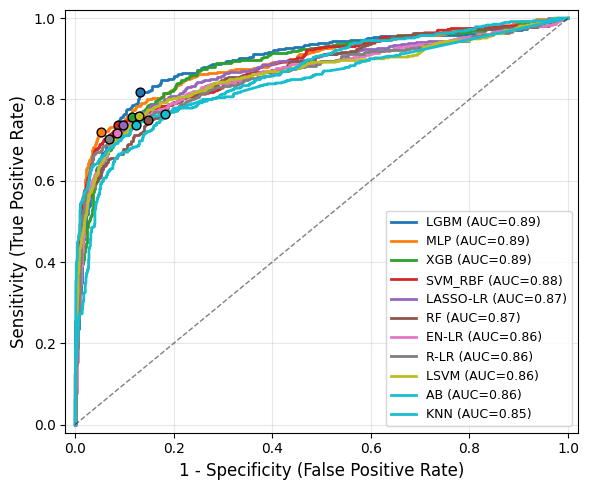

In [16]:
fig, ax = plot_roc_curves(
    roc_data=results["roc_data"],
    results_df=results["results_df"],
    title="",
    figsize=(6, 5),
    save_path="my_custom_roc.jpg",
    dpi=300
)

In [17]:
for model_name, metrics in results['repeat_level_results'].items():
    print(f"{model_name}: AUC per repeat = {metrics['auc']}")

LGBM: AUC per repeat = [0.8833010960670535, 0.8892649903288202, 0.8733075435203095, 0.8923275306254029, 0.9090909090909092, 0.9079626047711153, 0.8950676982591876, 0.9129593810444875, 0.8807221147646679, 0.8963571889103804]
XGB: AUC per repeat = [0.8618633139909735, 0.8970019342359768, 0.8689555125725339, 0.8800773694390716, 0.8978078658929723, 0.894100580270793, 0.884107027724049, 0.8992585428755641, 0.8970019342359768, 0.8802385557704706]
RF: AUC per repeat = [0.8612185686653772, 0.8641199226305609, 0.8637975499677627, 0.8654094132817538, 0.8847517730496455, 0.8736299161831078, 0.8797549967762734, 0.880722114764668, 0.8478401031592521, 0.8697614442295294]
LASSO-LR: AUC per repeat = [0.8608961960025789, 0.8920051579626048, 0.8675048355899421, 0.8563829787234043, 0.8699226305609284, 0.8687943262411347, 0.8905544809800129, 0.8965183752417795, 0.8781431334622825, 0.8523533204384269]
R-LR: AUC per repeat = [0.8715344938749194, 0.8720180528691167, 0.8552546744036106, 0.8608961960025789, 0.

In [18]:
len(results['final_models']['LGBM']['features'])

32

In [72]:
cols = ["Subject"] + results['final_models']['LGBM']['features']
important_features=feat_df[cols]

path_biovoc = "BIOVOC_data.xlsx"
df_biovoc = pd.read_excel(path_biovoc)

In [73]:
Ethanol=df_biovoc.iloc[:,[1,2]].dropna()
Isoprene=df_biovoc.iloc[:,[1,3]].dropna()
Acetone=df_biovoc.iloc[:,[1,4]].dropna()
Isop_alc=df_biovoc.iloc[:,[1,5]].dropna()
Prop=df_biovoc.iloc[:,[1,6]].dropna()
One_prop=df_biovoc.iloc[:,[1,7]].dropna()


In [74]:
df_biovoc

,Group,Subject,Ethanol,Isoperene,Acetone,Isopropyl Alcohol,Propanol,1-propanone
0,CRC,ONCOPT030435,0.740886,0.088124,3.500014,NaN,0.138066,0.631563
1,CRC,ONCOPT030395,1.406958,NaN,NaN,NaN,NaN,NaN
2,CRC,ONCOPT030446,0.653135,0.825853,2.857290,0.167206,NaN,0.528602
3,CRC,ONCOPT030362,NaN,11.840140,NaN,NaN,NaN,NaN
4,CRC,ONCOPT030447,0.497021,3.419972,2.475557,0.398611,0.571712,NaN
...,...,...,...,...,...,...,...,...
67,CRP,ONCODE050094,0.149991,2.435815,1.035755,0.765873,1.296943,NaN
68,CRP,ONCODE050096,NaN,5.704236,NaN,NaN,NaN,NaN
69,CRP,ONCODE010510,NaN,7.526945,1.178696,2.529834,NaN,0.907949
70,CRP,ONCODE050100,0.084963,1.472958,2.238017,9.709082,7.091814,0.656548


In [195]:
important_features

#To correlate important_features with the above.

,Subject,Chip2_Chip6_pearson,Grad_1_Chip2,Chip5_Chip7_pearson,Chip2_coeff_3,Chip8_coeff_0,Grad_1_Chip4,Chip6_coeff_4,Chip1_Chip3_pearson,Grad_1_Chip3,...,Chip8_coeff_2,AUC_R2_Chip3,Chip1_Chip5_pearson,Chip1_Chip4_pearson,Grad_1_Chip1,AUC_B2_Chip3,Chip2_Chip4_pearson,Chip2_Chip5_pearson,NR_Chip3,Chip1_Chip7_pearson
0,ONCODE010005,0.910905,0.000075,0.335598,0.072524,0.000004,0.000133,0.289087,0.964791,0.000143,...,0.002370,1478.031777,0.987514,0.917356,-0.000127,2684.859187,0.942906,0.935929,0.307575,0.263126
1,ONCODE010006,0.899764,0.000168,0.348270,-0.228140,-0.000008,0.000147,0.064316,0.959889,0.000164,...,-0.017858,1044.621919,0.982550,0.954731,-0.000138,1223.569891,0.941854,0.932502,0.217407,0.270274
2,ONCODE010007,0.944712,0.000069,0.348153,-0.158119,-0.000004,0.000107,-0.021372,0.924090,0.000131,...,-0.013793,1750.870172,0.964744,0.883508,-0.000108,2602.635984,0.963456,0.949075,0.364822,0.472228
3,ONCODE010009,0.751971,0.000107,0.873411,0.016934,0.000003,0.000157,0.510086,0.860220,0.000164,...,0.002631,377.546363,0.893990,0.911968,-0.000148,132.141740,0.794160,0.781030,0.078136,0.787686
4,ONCODE010011,0.761489,0.000153,0.106407,0.137071,0.000004,0.000190,0.650705,0.820803,0.000184,...,0.005783,685.372818,0.988495,0.893845,-0.000177,344.140582,0.880794,0.684827,0.142579,0.051192
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
525,ONCOPT030455,0.283610,-0.000067,0.868803,0.015365,0.000005,0.000173,0.384806,0.920743,0.000181,...,0.011319,670.769553,0.861922,0.878209,-0.000154,1408.349764,0.307485,0.268901,0.139950,0.884519
526,ONCOPT030456,0.187586,0.000105,0.910657,0.089356,0.000008,0.000180,0.524273,0.858477,0.000184,...,0.018258,631.910393,0.829323,0.873902,-0.000137,1269.147537,0.228378,0.162043,0.130650,0.771269
527,ONCOPT030457,0.212665,0.000174,0.887323,0.053288,0.000005,0.000180,0.484679,0.449964,0.000187,...,0.013525,542.988938,0.545343,0.522469,-0.000098,1034.831524,0.243908,0.205134,0.113891,0.402834
528,ONCOPT030458,0.260014,0.000003,0.879203,0.103415,0.000005,0.000152,0.471566,0.410193,0.000071,...,0.016287,2859.627697,0.493900,0.140119,-0.000086,2098.642633,0.313769,0.292285,0.595798,0.271213


In [289]:
target=Isop_alc
target_char="Isopropyl Alcohol"

In [290]:
match_imp_feats=important_features[important_features["Subject"].isin(target["Subject"])]

In [291]:
target_ex_match=target[target["Subject"].isin(match_imp_feats["Subject"])]

In [292]:
target_ex_match.shape

(35, 2)

In [293]:
match_imp_feats.shape

(35, 33)

In [294]:
df_merged = pd.merge(target_ex_match, match_imp_feats, on="Subject")

In [295]:
#bingo
df_merged

,Subject,Isopropyl Alcohol,Chip2_Chip6_pearson,Grad_1_Chip2,Chip5_Chip7_pearson,Chip2_coeff_3,Chip8_coeff_0,Grad_1_Chip4,Chip6_coeff_4,Chip1_Chip3_pearson,...,Chip8_coeff_2,AUC_R2_Chip3,Chip1_Chip5_pearson,Chip1_Chip4_pearson,Grad_1_Chip1,AUC_B2_Chip3,Chip2_Chip4_pearson,Chip2_Chip5_pearson,NR_Chip3,Chip1_Chip7_pearson
0,ONCOPT030446,0.167206,0.806152,0.000173,0.935975,0.059506,5.554457e-06,0.000196,0.321733,0.513948,...,0.012448,318.619414,0.494864,0.473036,-0.000173,564.542209,0.918564,0.936369,0.066363,0.524265
1,ONCOPT030447,0.398611,0.835944,0.000145,0.915562,0.106297,4.417769e-06,0.000190,0.312301,0.915504,...,0.009226,354.174632,0.938220,0.928074,-0.000162,829.609843,0.958157,0.944479,0.073777,0.907814
2,ONCOPT030368,0.290247,0.891366,0.000105,0.852481,0.095179,7.894051e-06,0.000134,0.224969,0.908655,...,0.013194,1282.016274,0.900769,0.902518,-0.000118,2264.226669,0.978060,0.961514,0.267123,0.830421
3,ONCOPT030410,0.346001,0.791168,0.000094,0.905195,0.088654,7.437345e-06,0.000141,0.303759,0.950864,...,0.011232,1207.537024,0.946802,0.949472,-0.000117,2308.507357,0.939816,0.932408,0.251808,0.892076
4,ONCOPT030397,0.121324,0.801049,0.000115,0.847078,0.120651,5.556474e-06,0.000165,0.303621,0.927331,...,0.012265,654.498306,0.890847,0.880377,-0.000170,1371.561246,0.942369,0.922840,0.136518,0.882369
5,ONCOPT030366,1.815972,0.911963,0.000070,0.888050,0.108156,7.941777e-06,0.000123,0.263247,0.783137,...,0.019404,1634.862454,0.920702,0.815784,-0.000116,2680.929305,0.949002,0.977314,0.340236,0.913084
6,ONCOPT030436,0.491169,0.788453,-0.000025,0.947122,0.059277,1.827586e-06,-0.000015,0.124921,0.646981,...,0.006337,3135.583011,0.924146,0.821651,-0.000019,3580.634118,0.956057,0.955407,0.653521,0.912731
7,ONCOPT030434,2.428967,0.805635,0.000181,0.921271,0.109156,5.431200e-06,0.000187,0.234843,0.763102,...,0.014781,642.197739,0.907784,0.854105,-0.000144,902.115883,0.965285,0.861081,0.133646,0.807373
8,ONCOPT030359,0.534551,0.219565,0.000046,0.909936,-0.032169,5.460527e-06,0.000176,0.411847,0.590165,...,0.016890,1280.249782,0.905883,0.713474,-0.000122,901.304983,0.455860,0.378822,0.266969,0.759137
9,ONCOPT030367,0.239986,0.090990,0.000090,0.859379,0.062488,4.368180e-06,0.000134,0.285094,0.406579,...,0.013739,1998.692382,0.530535,0.443256,-0.000185,1396.879556,0.908035,0.533899,0.416457,0.462267


In [296]:
corr_with_target = (
    df_merged
    .select_dtypes(include="number")
    .corr(method="pearson", min_periods=3)
    [target_char]
)

In [297]:
corr_with_target

Isopropyl Alcohol      1.000000
Chip2_Chip6_pearson    0.056638
Grad_1_Chip2          -0.189688
Chip5_Chip7_pearson    0.119640
Chip2_coeff_3         -0.285477
Chip8_coeff_0          0.088673
Grad_1_Chip4          -0.167440
Chip6_coeff_4          0.362957
Chip1_Chip3_pearson    0.000647
Grad_1_Chip3           0.010981
AUC_R2_Chip2           0.225743
AUC_B1_Chip1          -0.148852
Chip4_Chip7_pearson   -0.140753
Chip1_Chip6_pearson    0.117462
NR_Chip7              -0.161785
Chip1_Chip2_pearson   -0.103204
Grad_1_Chip7           0.429643
NR_Chip4               0.108330
AUC_R2_Chip4           0.108477
NR_Chip2               0.226121
Decay_B50_Chip7        0.086205
Chip8_coeff_1          0.010113
AUC_R2_Chip7          -0.159478
Chip8_coeff_2         -0.235773
AUC_R2_Chip3           0.082416
Chip1_Chip5_pearson    0.150521
Chip1_Chip4_pearson   -0.115618
Grad_1_Chip1          -0.297832
AUC_B2_Chip3           0.066992
Chip2_Chip4_pearson   -0.305603
Chip2_Chip5_pearson   -0.217255
NR_Chip3

In [298]:

import pandas as pd
from scipy.stats import pearsonr
from statsmodels.stats.multitest import multipletests


def pearson_correction_report(
    df,
    target_col,
    alpha=0.05,
    min_periods=3,
    verbose=True
):
    """
    Computes Pearson correlations of all numeric columns vs target_col,
    applies Bonferroni and FDR (BH) corrections, and reports significant results.

    Parameters
    ----------
    df : pandas.DataFrame
        Input dataframe
    target_col : str
        Column to correlate against
    alpha : float, default=0.05
        Significance level
    min_periods : int, default=3
        Minimum paired observations
    verbose : bool, default=True
        Whether to print a summary

    Returns
    -------
    full_df : pandas.DataFrame
        Full correlation report
    significant_df : pandas.DataFrame
        Significant correlations (Bonferroni or FDR)
    """

    numeric_df = df.select_dtypes(include="number")

    if target_col not in numeric_df.columns:
        raise ValueError(f"{target_col} not found or not numeric.")

    results = []

    for col in numeric_df.columns:
        if col == target_col:
            continue

        tmp = numeric_df[[target_col, col]].dropna()

        if len(tmp) < min_periods:
            continue

        r, pval = pearsonr(tmp[target_col], tmp[col])

        results.append({
            "feature": col,
            "pearson_r": r,
            "p_value": pval,
            "n_pairs": len(tmp)
        })

    report_df = pd.DataFrame(results)

    if report_df.empty:
        raise ValueError("No valid correlations computed.")

    # Number of tests
    n_tests = len(report_df)

    # Bonferroni correction
    report_df["p_bonferroni"] = (report_df["p_value"] * n_tests).clip(upper=1.0)
    report_df["significant_bonferroni"] = report_df["p_bonferroni"] < alpha

    # FDR (Benjamini–Hochberg)
    fdr_results = multipletests(
        report_df["p_value"],
        alpha=alpha,
        method="fdr_bh"
    )

    report_df["p_fdr"] = fdr_results[1]
    report_df["significant_fdr"] = fdr_results[0]

    # Sort by FDR (more informative for exploratory analysis)
    report_df = report_df.sort_values("p_fdr")

    # Keep anything significant by either correction
    significant_df = report_df[
        report_df["significant_bonferroni"] | report_df["significant_fdr"]
    ]

    if verbose:
        print(f"Target VOC: {target_col}")
        print(f"Number of tests: {n_tests}")
        print(f"Bonferroni α: {alpha / n_tests:.5f}")
        print(f"Significant (Bonferroni): {report_df['significant_bonferroni'].sum()}")
        print(f"Significant (FDR): {report_df['significant_fdr'].sum()}\n")

        if len(significant_df) > 0:
            print(
                significant_df[
                    ["feature", "pearson_r", "n_pairs",
                     "p_value", "p_bonferroni", "p_fdr"]
                ].to_string(index=False)
            )
        else:
            print("No correlations survive multiple-comparison correction.")

    return report_df, significant_df


In [299]:
full_report, significant = pearson_correction_report(
    df_merged,
    target_col=target_char,
    min_periods=3
)

Target VOC: Isopropyl Alcohol
Number of tests: 32
Bonferroni α: 0.00156
Significant (Bonferroni): 0
Significant (FDR): 0

No correlations survive multiple-comparison correction.


In [300]:
full_report

,feature,pearson_r,p_value,n_pairs,p_bonferroni,significant_bonferroni,p_fdr,significant_fdr
15,Grad_1_Chip7,0.429643,0.010001,35,0.320027,False,0.320027,False
6,Chip6_coeff_4,0.362957,0.032114,35,1.000000,False,0.513829,False
3,Chip2_coeff_3,-0.285477,0.096440,35,1.000000,False,0.617213,False
28,Chip2_Chip4_pearson,-0.305603,0.074213,35,1.000000,False,0.617213,False
26,Grad_1_Chip1,-0.297832,0.082266,35,1.000000,False,0.617213,False
18,NR_Chip2,0.226121,0.191499,35,1.000000,False,0.746550,False
22,Chip8_coeff_2,-0.235773,0.172723,35,1.000000,False,0.746550,False
9,AUC_R2_Chip2,0.225743,0.192262,35,1.000000,False,0.746550,False
29,Chip2_Chip5_pearson,-0.217255,0.209967,35,1.000000,False,0.746550,False
13,NR_Chip7,-0.161785,0.353144,35,1.000000,False,0.780955,False


In [303]:
bf_feats

,Subject,Group,NR_Chip2,NR_Chip3,NR_Chip4,NR_Chip7,AUC_R2_Chip2,AUC_R2_Chip3,AUC_R2_Chip4,AUC_R2_Chip7,...,Grad_1_Chip3,Grad_1_Chip4,Grad_1_Chip7,Chip2_coeff_3,Chip8_coeff_0,Chip8_coeff_1,Chip8_coeff_2,Chip1_Chip2_pearson,Chip1_Chip4_pearson,Chip2_Chip4_pearson
0,ONCODE010005,CRC,0.616256,0.307575,0.348344,0.567331,2960.802572,1478.031777,1673.967604,2709.246257,...,0.000143,0.000133,-0.000123,0.072524,0.000004,-0.000215,0.002370,0.917012,0.917356,0.942906
1,ONCODE010006,HC/NR,0.209797,0.217407,0.288170,0.243338,1003.815289,1044.621919,1388.304251,1154.259178,...,0.000164,0.000147,-0.000011,-0.228140,-0.000008,0.000671,-0.017858,0.898266,0.954731,0.941854
2,ONCODE010007,TBD,0.637552,0.364822,0.408391,0.413303,3060.153138,1750.870172,1960.321189,1979.600524,...,0.000131,0.000107,-0.000086,-0.158119,-0.000004,0.000421,-0.013793,0.905962,0.883508,0.963456
3,ONCODE010009,CRC,0.277716,0.078136,0.078754,0.952979,1343.009797,377.546363,379.399642,4579.832009,...,0.000164,0.000157,-0.000187,0.016934,0.000003,-0.000166,0.002631,0.532586,0.911968,0.794160
4,ONCODE010011,HC/R/P,0.303858,0.142579,0.084711,0.302416,1461.863127,685.372818,405.161246,1464.635439,...,0.000184,0.000190,-0.000038,0.137071,0.000004,-0.000249,0.005783,0.645177,0.893845,0.880794
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
525,ONCOPT030455,HC/NR,0.530985,0.139950,0.181177,0.776616,2489.396001,670.769553,878.940372,3743.860198,...,0.000181,0.000173,-0.000160,0.015365,0.000005,-0.000398,0.011319,0.180322,0.878209,0.307485
526,ONCOPT030456,HC/NR,0.487147,0.130650,0.136591,0.807592,2386.324054,631.910393,669.118992,3856.256793,...,0.000184,0.000180,-0.000169,0.089356,0.000008,-0.000633,0.018258,0.257114,0.873902,0.228378
527,ONCOPT030457,HC/NR,0.252819,0.113891,0.126324,0.821259,1140.291266,542.988938,619.472998,3977.519181,...,0.000187,0.000180,-0.000143,0.053288,0.000005,-0.000446,0.013525,0.323741,0.522469,0.243908
528,ONCOPT030458,HC/NR,0.615049,0.595798,0.275475,0.906321,2972.390852,2859.627697,1339.930827,4344.179000,...,0.000071,0.000152,-0.000191,0.103415,0.000005,-0.000496,0.016287,0.063198,0.140119,0.313769
